# OULAD Dataset Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path config
DATA_DIR = r'../dataset/'

# Load all tables
assessments       = pd.read_csv(DATA_DIR + 'assessments.csv')
courses           = pd.read_csv(DATA_DIR + 'courses.csv')
student_info      = pd.read_csv(DATA_DIR + 'studentInfo.csv')
student_reg       = pd.read_csv(DATA_DIR + 'studentRegistration.csv')
student_assess    = pd.read_csv(DATA_DIR + 'studentAssessment.csv')
student_vle       = pd.read_csv(DATA_DIR + 'studentVle.csv')
vle               = pd.read_csv(DATA_DIR + 'vle.csv')

tables = {
    'assessments': assessments,
    'courses': courses,
    'studentInfo': student_info,
    'studentRegistration': student_reg,
    'studentAssessment': student_assess,
    'studentVle': student_vle,
    'vle': vle,
}

print("=== Table shapes ===")
for name, df in tables.items():
    print(f"  {name:25s}: {df.shape[0]:>7,} rows × {df.shape[1]} cols")

=== Table shapes ===
  assessments              :     206 rows × 6 cols
  courses                  :      22 rows × 3 cols
  studentInfo              :  32,593 rows × 12 cols
  studentRegistration      :  32,593 rows × 5 cols
  studentAssessment        : 173,912 rows × 5 cols
  studentVle               : 10,655,280 rows × 6 cols
  vle                      :   6,364 rows × 6 cols


## 1. Dataset Overview

── Enrolment Count by Module × Presentation ──


code_presentation,2013B,2013J,2014B,2014J,Total
code_module,,,,,
AAA,0,383,0,365,748
BBB,1767,2237,1613,2292,7909
CCC,0,0,1936,2498,4434
DDD,1303,1938,1228,1803,6272
EEE,0,1052,694,1188,2934
FFF,1614,2283,1500,2365,7762
GGG,0,952,833,749,2534
Total,4684,8845,7804,11260,32593


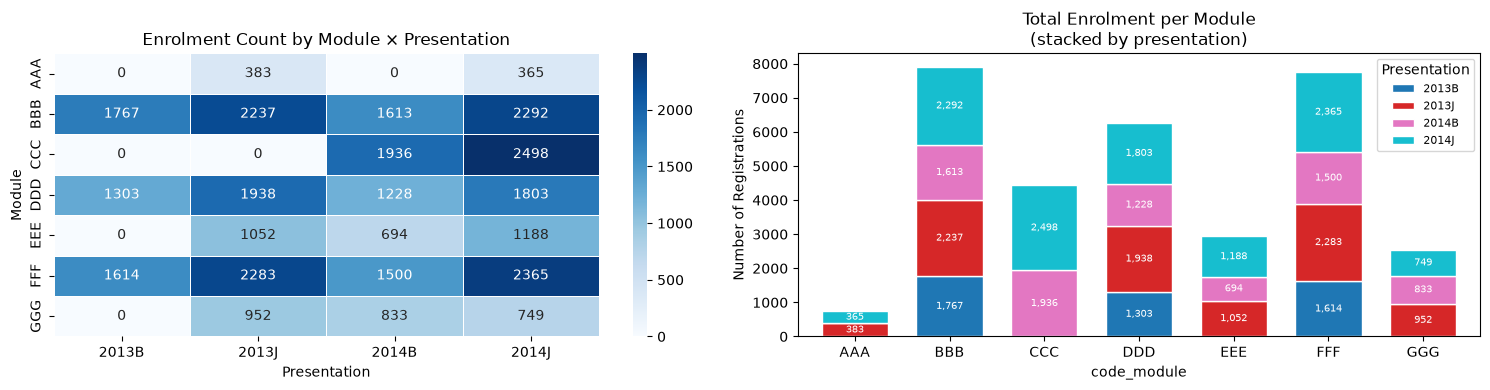

In [4]:

# ── Enrolment Count by Module × Presentation ──────────────────
enrol = (student_info
    .groupby(['code_module', 'code_presentation'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['2013B', '2013J', '2014B', '2014J'], fill_value=0))

enrol['Total'] = enrol.sum(axis=1)
enrol.loc['Total'] = enrol.sum()

print("── Enrolment Count by Module × Presentation ──")
display(enrol)

# ── Heatmap + stacked bar ──────────────────────────────────────
enrol_heat = enrol.drop(index='Total').drop(columns='Total')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(enrol_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Enrolment Count by Module × Presentation')
axes[0].set_xlabel('Presentation')
axes[0].set_ylabel('Module')

enrol_heat.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='tab10', edgecolor='white', width=0.7)
axes[1].set_title('Total Enrolment per Module\n(stacked by presentation)')
axes[1].set_ylabel('Number of Registrations')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Presentation', fontsize=8)
for p in axes[1].patches:
    h = p.get_height()
    if h > 300:
        axes[1].text(p.get_x() + p.get_width()/2, p.get_y() + h/2,
                     f'{int(h):,}', ha='center', va='center', fontsize=7, color='white')

plt.tight_layout()
plt.show()


## 2. Data Cleaning

In [5]:
# ── 2.1 Missing value audit across all 7 tables ──────────────
print("=" * 60)
print("MISSING VALUE AUDIT — ALL 7 TABLES")
print("=" * 60)

all_tables = {
    'assessments':         assessments,
    'courses':             courses,
    'studentInfo':         student_info,
    'studentRegistration': student_reg,
    'studentAssessment':   student_assess,
    'studentVle':          student_vle,
    'vle':                 vle,
}

audit_rows = []
for tname, df in all_tables.items():
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        audit_rows.append({
            'Table':   tname,
            'Column':  col,
            'Missing': int(n_miss),
            '%':       round(n_miss / len(df) * 100, 2),
            'dtype':   str(df[col].dtype),
        })

audit_df = pd.DataFrame(audit_rows)
has_missing = audit_df[audit_df['Missing'] > 0].reset_index(drop=True)
if len(has_missing) > 0:
    print(f"Columns with missing values ({len(has_missing)} found):")
    display(has_missing)
else:
    print("No missing values found in any table.")

print("\n── Summary: total rows per table ──")
for tname, df in all_tables.items():
    total_miss = df.isnull().sum().sum()
    print(f"  {tname:22s}: {len(df):>8,} rows × {df.shape[1]} cols  |  missing cells: {total_miss}")


MISSING VALUE AUDIT — ALL 7 TABLES
Columns with missing values (7 found):


,Table,Column,Missing,%,dtype
0,assessments,date,11,5.34,float64
1,studentInfo,imd_band,1111,3.41,str
2,studentRegistration,date_registration,45,0.14,float64
3,studentRegistration,date_unregistration,22521,69.10,float64
4,studentAssessment,score,173,0.10,float64
5,vle,week_from,5243,82.39,float64
6,vle,week_to,5243,82.39,float64



── Summary: total rows per table ──
  assessments           :      206 rows × 6 cols  |  missing cells: 11
  courses               :       22 rows × 3 cols  |  missing cells: 0
  studentInfo           :   32,593 rows × 12 cols  |  missing cells: 1111
  studentRegistration   :   32,593 rows × 5 cols  |  missing cells: 22566
  studentAssessment     :  173,912 rows × 5 cols  |  missing cells: 173
  studentVle            : 10,655,280 rows × 6 cols  |  missing cells: 0
  vle                   :    6,364 rows × 6 cols  |  missing cells: 10486


In [6]:
# ── 2.2 Handle missing values & document decisions (all 7 tables)

# ── assessments: date ─────────────────────────────────────────
# 'date' is null for 11 Exam-type assessments — by OULAD design,
# exams have no fixed VLE submission date. Retain NaN; add flag.
assessments_clean = assessments.copy()
assessments_clean['has_date'] = assessments_clean['date'].notna().astype(int)

# ── courses: no missing values ────────────────────────────────
courses_clean = courses.copy()

# ── studentInfo: imd_band ─────────────────────────────────────
# imd_band missing ~3.4% of rows. Treated as a distinct category
# 'Unknown' rather than imputing, because missingness may be
# non-random (lower-income students less likely to disclose).
student_info_clean = student_info.copy()
student_info_clean['imd_band'] = student_info_clean['imd_band'].fillna('Unknown')

# ── studentRegistration: date_registration / date_unregistration
# date_registration: 45 nulls (0.14%) — likely late/admin
#   registrations with no date recorded. Fill with 0 (course start)
#   as a conservative assumption; flagged with a boolean.
# date_unregistration: null = did not withdraw (structural, not missing).
#   Add a boolean flag for convenience.
student_reg_clean = student_reg.copy()
student_reg_clean['reg_date_imputed'] = student_reg_clean['date_registration'].isna().astype(int)
student_reg_clean['date_registration'] = student_reg_clean['date_registration'].fillna(0)
student_reg_clean['unregistered'] = student_reg_clean['date_unregistration'].notna().astype(int)

# ── studentAssessment: score ──────────────────────────────────
# Null score = student did not submit. Non-submission is a
# behavioural signal correlated with withdrawal; retain as flag.
student_assess_clean = student_assess.copy()
student_assess_clean['submitted'] = student_assess_clean['score'].notna().astype(int)
student_assess_clean['score'] = student_assess_clean['score'].fillna(0)

# ── studentVle: no missing values ─────────────────────────────
student_vle_clean = student_vle.copy()

# ── vle: week_from / week_to ──────────────────────────────────
# 82.4% of VLE resources have no week_from/week_to metadata —
# these are optional scheduling fields not used in feature
# engineering. Retain as NaN; not used downstream.
vle_clean = vle.copy()

# ── Summary of cleaning decisions ─────────────────────────────
print("── Cleaning Decisions (all 7 tables) ──\n")
decisions = pd.DataFrame([
    ('assessments',        'date',                  'Null = Exam type (by design); added has_date flag (0/1)'),
    ('courses',            'all cols',               'No missing values'),
    ('studentInfo',        'imd_band',               "fillna('Unknown') — treat as separate category (3.4% missing)"),
    ('studentInfo',        'all other cols',         'No missing values'),
    ('studentRegistration','date_registration',      'fillna(0) = course start; added reg_date_imputed flag (45 rows)'),
    ('studentRegistration','date_unregistration',    'Null = did not withdraw (structural); added unregistered flag'),
    ('studentAssessment',  'score',                  'fillna(0) — non-submission scored as 0; added submitted flag'),
    ('studentVle',         'all cols',               'No missing values'),
    ('vle',                'week_from / week_to',    'Null = optional metadata, not used in feature engineering — retained'),
], columns=['Table', 'Column', 'Action'])
display(decisions)

# ── Post-cleaning audit ───────────────────────────────────────
print("\n── Post-cleaning missing value check ──")
intentional_nulls = {
    'assessments_clean':       ['date'],
    'studentReg_clean':        ['date_unregistration'],
    'vle_clean':               ['week_from', 'week_to'],
}
clean_tables = [
    ('assessments_clean',       assessments_clean),
    ('courses_clean',           courses_clean),
    ('studentInfo_clean',       student_info_clean),
    ('studentReg_clean',        student_reg_clean),
    ('studentAssessment_clean', student_assess_clean),
    ('studentVle_clean',        student_vle_clean),
    ('vle_clean',               vle_clean),
]
all_ok = True
for name, df in clean_tables:
    skip = intentional_nulls.get(name, [])
    check_cols = [c for c in df.columns if c not in skip]
    n_miss = df[check_cols].isnull().sum().sum()
    status = 'OK' if n_miss == 0 else f'WARNING: {n_miss} unexpected nulls'
    print(f"  {name:30s}: {status}")
    if n_miss > 0:
        all_ok = False
if all_ok:
    print("\nAll tables clean — no unexpected missing values.")

# ── Overwrite raw variables so all downstream cells use clean data
assessments    = assessments_clean
courses        = courses_clean
student_info   = student_info_clean
student_reg    = student_reg_clean
student_assess = student_assess_clean
student_vle    = student_vle_clean
vle            = vle_clean
print("All 7 raw variables reassigned to cleaned versions.")


── Cleaning Decisions (all 7 tables) ──



,Table,Column,Action
0,assessments,date,Null = Exam type (by design); added has_date f...
1,courses,all cols,No missing values
2,studentInfo,imd_band,fillna('Unknown') — treat as separate category...
3,studentInfo,all other cols,No missing values
4,studentRegistration,date_registration,fillna(0) = course start; added reg_date_imput...
5,studentRegistration,date_unregistration,Null = did not withdraw (structural); added un...
6,studentAssessment,score,fillna(0) — non-submission scored as 0; added ...
7,studentVle,all cols,No missing values
8,vle,week_from / week_to,"Null = optional metadata, not used in feature ..."



── Post-cleaning missing value check ──
  assessments_clean             : OK
  courses_clean                 : OK
  studentInfo_clean             : OK
  studentReg_clean              : OK
  studentAssessment_clean       : OK
  studentVle_clean              : OK
  vle_clean                     : OK

All tables clean — no unexpected missing values.
All 7 raw variables reassigned to cleaned versions.


In [7]:
# ── 2.3 Export all cleaned tables ────────────────────────────
import os

CLEAN_DIR = r'../dataset/cleaned/'
os.makedirs(CLEAN_DIR, exist_ok=True)

export_map = {
    'assessments_clean.csv':         assessments,
    'courses_clean.csv':             courses,
    'studentInfo_clean.csv':         student_info,
    'studentRegistration_clean.csv': student_reg,
    'studentAssessment_clean.csv':   student_assess,
    'studentVle_clean.csv':          student_vle,
    'vle_clean.csv':                 vle,
}

print("Cleaned files saved to", CLEAN_DIR)
for fname, df in export_map.items():
    path = CLEAN_DIR + fname
    df.to_csv(path, index=False)
    df_check = pd.read_csv(path)
    print(f"  {fname:38s}: {df_check.shape[0]:>8,} rows × {df_check.shape[1]} cols")


Cleaned files saved to ../dataset/cleaned/
  assessments_clean.csv                 :      206 rows × 7 cols
  courses_clean.csv                     :       22 rows × 3 cols
  studentInfo_clean.csv                 :   32,593 rows × 12 cols
  studentRegistration_clean.csv         :   32,593 rows × 7 cols
  studentAssessment_clean.csv           :  173,912 rows × 6 cols
  studentVle_clean.csv                  : 10,655,280 rows × 6 cols
  vle_clean.csv                         :    6,364 rows × 6 cols


## 3. Target Variable: Module Withdrawal

In [8]:
from IPython.display import display

# Basic info
print(f"Shape: {student_info.shape[0]:,} rows × {student_info.shape[1]} cols\n")

# Missing values table
missing = student_info.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(student_info) * 100).round(2)
print("── Missing Values ──")
display(missing[missing['Missing'] > 0] if missing['Missing'].sum() > 0 else pd.DataFrame({'Note': ['No missing values']}))

# Final result distribution table
print("\n── Final Result Distribution ──")
result_table = student_info['final_result'].value_counts().reset_index()
result_table.columns = ['Final Result', 'Count']
result_table['%'] = (result_table['Count'] / len(student_info) * 100).round(1)
display(result_table)
print(f"\nWithdrawal rate: {(student_info['final_result']=='Withdrawn').mean():.1%}")


Shape: 32,593 rows × 12 cols

── Missing Values ──


,Note
0,No missing values



── Final Result Distribution ──


,Final Result,Count,%
0,Pass,12361,37.9
1,Withdrawn,10156,31.2
2,Fail,7052,21.6
3,Distinction,3024,9.3



Withdrawal rate: 31.2%


── Final Result Distribution by Module (%) ──


final_result,N,Distinction,Fail,Pass,Withdrawn
code_module,,,,,
AAA,748,5.9,12.2,65.1,16.8
BBB,7909,8.6,22.3,38.9,30.2
CCC,4434,11.2,17.6,26.6,44.5
DDD,6272,6.1,22.5,35.5,35.9
EEE,2934,12.1,19.2,44.1,24.6
FFF,7762,8.6,22.0,38.4,31.0
GGG,2534,15.6,28.7,44.1,11.5


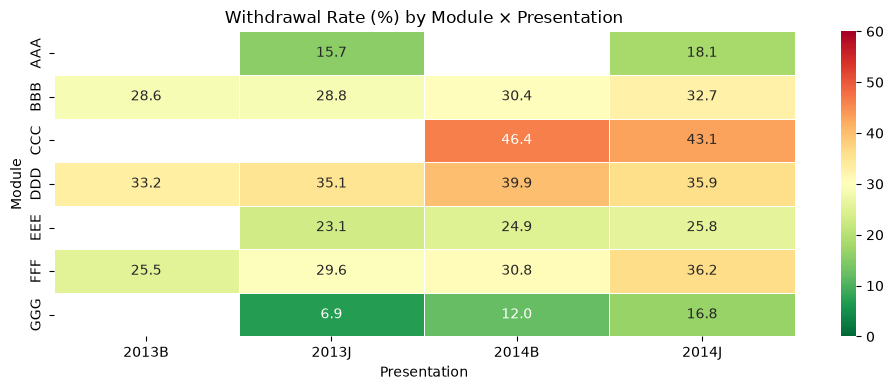

In [9]:
# ── Per-module final result distribution ────────────────────────
module_result = (student_info
    .groupby(['code_module', 'final_result'])
    .size()
    .unstack(fill_value=0))
module_result_pct = module_result.div(module_result.sum(axis=1), axis=0).mul(100).round(1)
module_result_pct.insert(0, 'N', module_result.sum(axis=1))
print("── Final Result Distribution by Module (%) ──")
display(module_result_pct)

# Heatmap: withdrawal rate by module × presentation
pivot_wd = (student_info
    .assign(withdrawn=(student_info['final_result'] == 'Withdrawn').astype(int))
    .groupby(['code_module', 'code_presentation'])['withdrawn']
    .mean().mul(100).round(1)
    .unstack())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_wd, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=60)
ax.set_title('Withdrawal Rate (%) by Module × Presentation')
ax.set_xlabel('Presentation')
ax.set_ylabel('Module')
plt.tight_layout()
plt.show()


## 4. Learner Demographics

── Demographics Summary ──


,Category,Count,%
0,Total students,32593,100.0
1,Female,14718,45.2
2,Male,17875,54.8
3,Pass,12361,37.9
4,Distinction,3024,9.3
5,Fail,7052,21.6
6,Withdrawn,10156,31.2


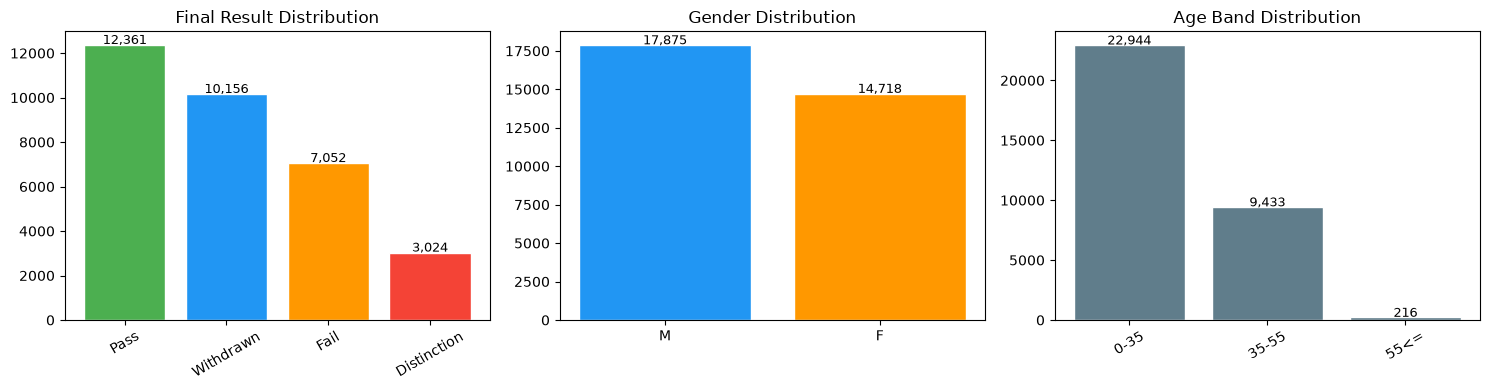

In [10]:
# Summary table
print("── Demographics Summary ──")
demo_table = pd.DataFrame({
    'Category': ['Total students', 'Female', 'Male',
                 'Pass', 'Distinction', 'Fail', 'Withdrawn'],
    'Count': [
        len(student_info),
        (student_info['gender']=='F').sum(),
        (student_info['gender']=='M').sum(),
        (student_info['final_result']=='Pass').sum(),
        (student_info['final_result']=='Distinction').sum(),
        (student_info['final_result']=='Fail').sum(),
        (student_info['final_result']=='Withdrawn').sum(),
    ]
})
demo_table['%'] = (demo_table['Count'] / len(student_info) * 100).round(1)
display(demo_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Final result
result_counts = student_info['final_result'].value_counts()
bars0 = axes[0].bar(result_counts.index, result_counts.values,
                    color=['#4CAF50','#2196F3','#FF9800','#F44336'], edgecolor='white')
axes[0].set_title('Final Result Distribution')
axes[0].tick_params(axis='x', rotation=30)
for b in bars0:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# Gender
gender_counts = student_info['gender'].value_counts()
bars1 = axes[1].bar(gender_counts.index, gender_counts.values,
                    color=['#2196F3','#FF9800'], edgecolor='white')
axes[1].set_title('Gender Distribution')
for b in bars1:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# Age band
age_counts = student_info['age_band'].value_counts().sort_index()
bars2 = axes[2].bar(age_counts.index, age_counts.values, color='#607D8B', edgecolor='white')
axes[2].set_title('Age Band Distribution')
axes[2].tick_params(axis='x', rotation=30)
for b in bars2:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                 f'{b.get_height():,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 5. VLE Engagement

── studentVle Statistics ──


,Metric,Value
0,Total interaction records,"10,655,280"
1,Students with VLE records,"26,074"
2,Median total clicks / student,824
3,Mean total clicks / student,1519
4,Median active days / student,52
5,Mean active days / student,67


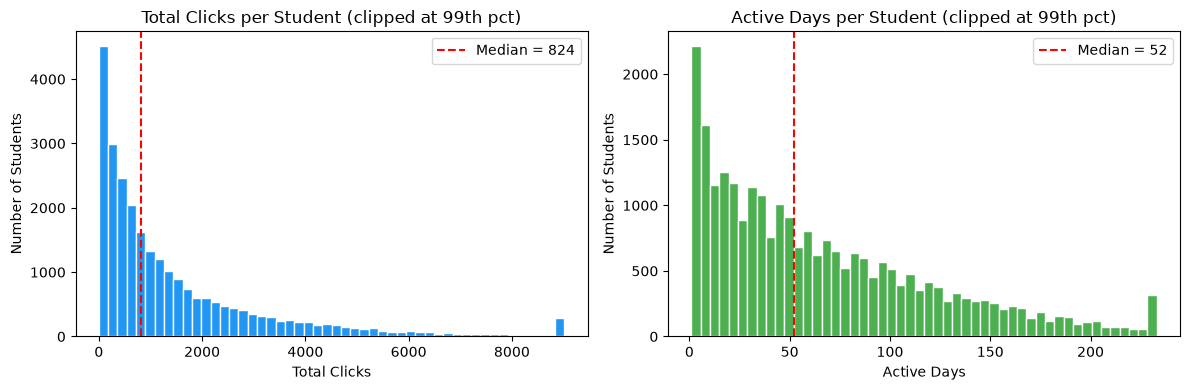

In [11]:
# Aggregate per student
vle_agg = student_vle.groupby('id_student').agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique')
).reset_index()

# Stats table
print("── studentVle Statistics ──")
stats_table = pd.DataFrame({
    'Metric': ['Total interaction records', 'Students with VLE records',
               'Median total clicks / student', 'Mean total clicks / student',
               'Median active days / student', 'Mean active days / student'],
    'Value': [
        f"{len(student_vle):,}",
        f"{len(vle_agg):,}",
        f"{vle_agg['total_clicks'].median():.0f}",
        f"{vle_agg['total_clicks'].mean():.0f}",
        f"{vle_agg['active_days'].median():.0f}",
        f"{vle_agg['active_days'].mean():.0f}",
    ]
})
display(stats_table)

# Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p99_clicks = vle_agg['total_clicks'].quantile(0.99)
p99_days   = vle_agg['active_days'].quantile(0.99)

axes[0].hist(vle_agg['total_clicks'].clip(upper=p99_clicks),
             bins=50, color='#2196F3', edgecolor='white')
axes[0].set_title('Total Clicks per Student (clipped at 99th pct)')
axes[0].set_xlabel('Total Clicks')
axes[0].set_ylabel('Number of Students')
axes[0].axvline(vle_agg['total_clicks'].median(), color='red', linestyle='--',
                label=f"Median = {vle_agg['total_clicks'].median():.0f}")
axes[0].legend()

axes[1].hist(vle_agg['active_days'].clip(upper=p99_days),
             bins=50, color='#4CAF50', edgecolor='white')
axes[1].set_title('Active Days per Student (clipped at 99th pct)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Number of Students')
axes[1].axvline(vle_agg['active_days'].median(), color='red', linestyle='--',
                label=f"Median = {vle_agg['active_days'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


── VLE Engagement by Module (students with VLE records only) ──


,n_students,median_clicks,mean_clicks,median_days,mean_days
code_module,,,,,
AAA,702,1262.5,1775.9,81.0,91.5
BBB,6484,454.0,807.2,36.0,47.9
CCC,3852,684.0,1215.5,43.0,56.4
DDD,5407,708.0,1022.8,61.0,72.0
EEE,2634,1229.5,1512.6,63.0,69.3
FFF,6799,2116.0,2587.7,72.0,81.0
GGG,2359,464.0,565.4,30.0,35.7


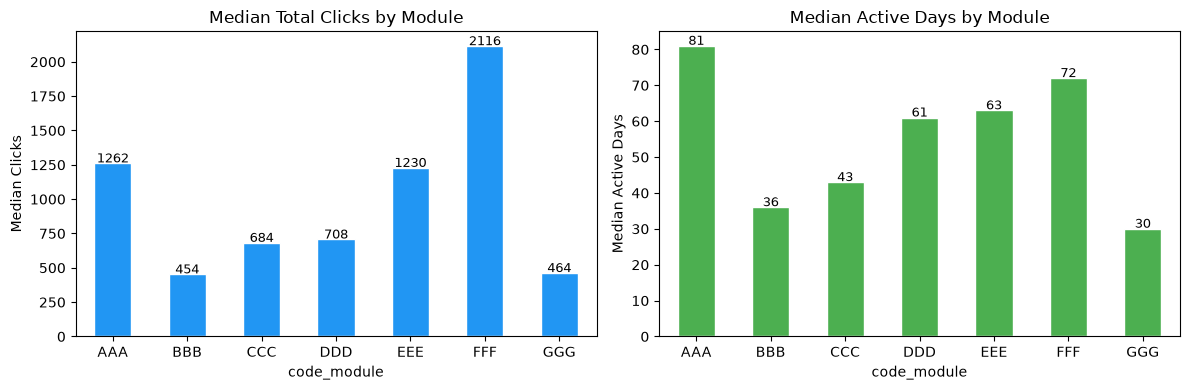

In [12]:
# ── Per-module VLE engagement (students with VLE records only) ──
# student_vle already contains code_module — no merge with student_info needed,
# which avoids inflating records for students registered in multiple modules.
vle_mod = (student_vle
    .groupby(['code_module', 'id_student'])
    .agg(clicks=('sum_click', 'sum'), days=('date', 'nunique'))
    .groupby('code_module')
    .agg(
        n_students=('clicks', 'count'),
        median_clicks=('clicks', 'median'),
        mean_clicks=('clicks', 'mean'),
        median_days=('days', 'median'),
        mean_days=('days', 'mean'),
    )
    .round(1))

print("── VLE Engagement by Module (students with VLE records only) ──")
display(vle_mod)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vle_mod['median_clicks'].plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Median Total Clicks by Module')
axes[0].set_ylabel('Median Clicks')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                 f'{p.get_height():.0f}', ha='center', fontsize=9)

vle_mod['median_days'].plot(kind='bar', ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('Median Active Days by Module')
axes[1].set_ylabel('Median Active Days')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.3,
                 f'{p.get_height():.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


── VLE Activity Type Statistics ──


,activity_type,Total_Clicks,Interaction_Records,Click %,Interaction %
0,oucontent,11206803,1963782,28.3,18.4
1,forumng,7973390,2408457,20.1,22.6
2,quiz,6981240,914573,17.6,8.6
3,homepage,6949064,1735226,17.5,16.3
4,subpage,3411582,1949898,8.6,18.3
5,resource,1110132,813185,2.8,7.6
6,ouwiki,894512,178165,2.3,1.7
7,url,566702,407716,1.4,3.8
8,oucollaborate,108974,65793,0.3,0.6
9,glossary,87962,17435,0.2,0.2


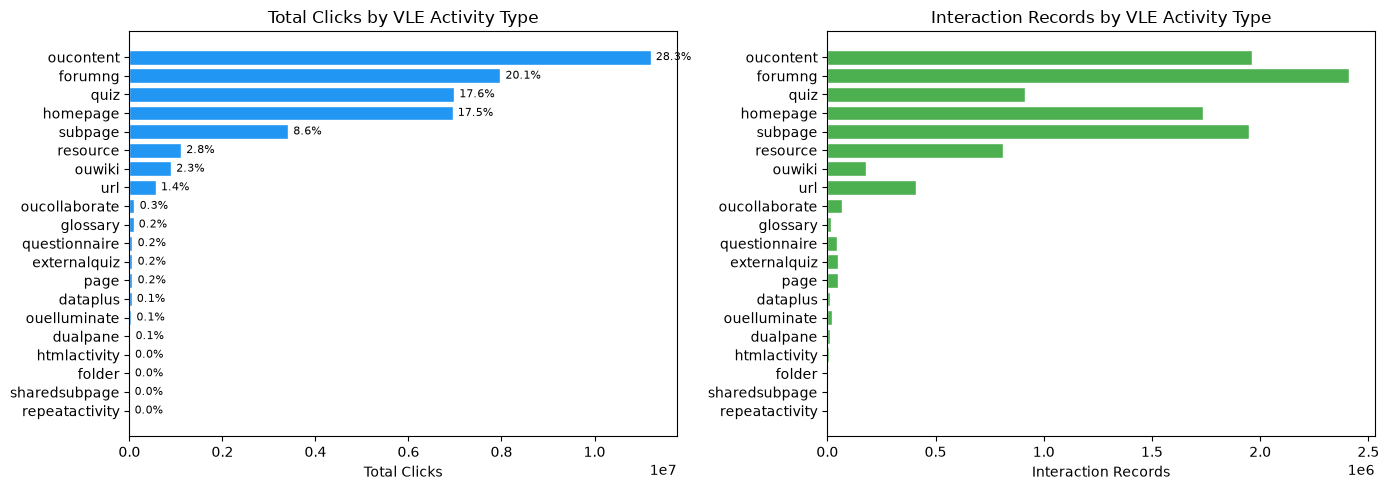

In [13]:

# ── VLE Resource Type Breakdown ───────────────────────────────
# Join student_vle with vle table to get activity_type per interaction
vle_typed = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')

# Total clicks and interaction records by activity type
type_stats = (vle_typed
    .groupby('activity_type')
    .agg(
        Total_Clicks=('sum_click', 'sum'),
        Interaction_Records=('sum_click', 'count'),
    )
    .sort_values('Total_Clicks', ascending=False)
    .reset_index())
type_stats['Click %']       = (type_stats['Total_Clicks'] / type_stats['Total_Clicks'].sum() * 100).round(1)
type_stats['Interaction %'] = (type_stats['Interaction_Records'] / type_stats['Interaction_Records'].sum() * 100).round(1)

print("── VLE Activity Type Statistics ──")
display(type_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(type_stats['activity_type'], type_stats['Total_Clicks'],
             color='#2196F3', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_xlabel('Total Clicks')
axes[0].set_title('Total Clicks by VLE Activity Type')
for i, v in enumerate(type_stats['Total_Clicks']):
    axes[0].text(v + type_stats['Total_Clicks'].max()*0.01, i, f"{type_stats['Click %'].iloc[i]:.1f}%",
                 va='center', fontsize=8)

axes[1].barh(type_stats['activity_type'], type_stats['Interaction_Records'],
             color='#4CAF50', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Interaction Records')
axes[1].set_title('Interaction Records by VLE Activity Type')

plt.tight_layout()
plt.show()


── Mean Clicks & Active Days by Final Result ──


,Final Result,Count,Mean Clicks,Median Clicks,Mean Active Days,Median Active Days
0,Distinction,3024,3106.4,2218.0,118.3,113.0
1,Fail,7052,794.4,387.0,38.1,25.5
2,Pass,12361,2170.6,1503.0,93.2,84.0
3,Withdrawn,10156,628.1,178.0,28.7,12.0


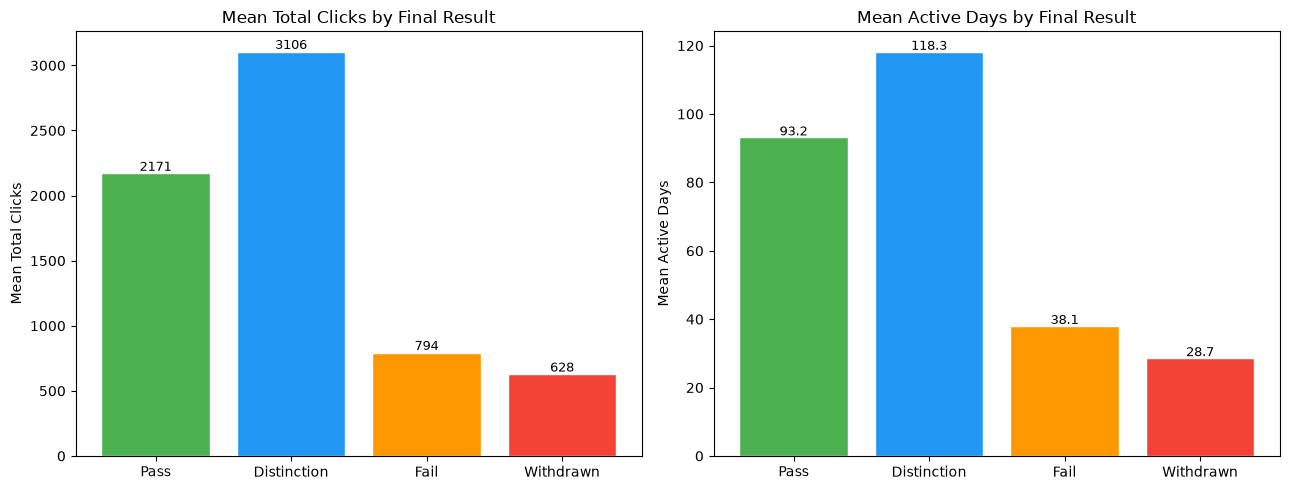

In [14]:
merged = student_info[['id_student', 'final_result']].merge(vle_agg, on='id_student', how='left')
merged['total_clicks'] = merged['total_clicks'].fillna(0)
merged['active_days']  = merged['active_days'].fillna(0)

# Summary table
print("── Mean Clicks & Active Days by Final Result ──")
summary = merged.groupby('final_result').agg(
    Count=('id_student', 'count'),
    Mean_Clicks=('total_clicks', 'mean'),
    Median_Clicks=('total_clicks', 'median'),
    Mean_Active_Days=('active_days', 'mean'),
    Median_Active_Days=('active_days', 'median'),
).round(1).reset_index()
summary.columns = ['Final Result', 'Count', 'Mean Clicks', 'Median Clicks',
                   'Mean Active Days', 'Median Active Days']
display(summary)

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

means_clicks = [merged[merged['final_result']==r]['total_clicks'].mean() for r in order]
means_days   = [merged[merged['final_result']==r]['active_days'].mean() for r in order]

bars_c = axes[0].bar(order, means_clicks, color=[palette[r] for r in order], edgecolor='white')
axes[0].set_title('Mean Total Clicks by Final Result')
axes[0].set_ylabel('Mean Total Clicks')
for b, v in zip(bars_c, means_clicks):
    axes[0].text(b.get_x()+b.get_width()/2, v+20, f'{v:.0f}', ha='center', fontsize=9)

bars_d = axes[1].bar(order, means_days, color=[palette[r] for r in order], edgecolor='white')
axes[1].set_title('Mean Active Days by Final Result')
axes[1].set_ylabel('Mean Active Days')
for b, v in zip(bars_d, means_days):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [15]:
# ── No-VLE student participation summary ───────────────────────
students_with_vle = set(student_vle['id_student'].unique())
student_info['has_vle'] = student_info['id_student'].isin(students_with_vle)

no_vle  = student_info[~student_info['has_vle']]
has_vle = student_info[student_info['has_vle']]

print("── VLE Participation Summary ──")
summary_vle = pd.DataFrame({
    'Group':           ['Has VLE records', 'No VLE records', 'All students'],
    'Count':           [len(has_vle), len(no_vle), len(student_info)],
    'Withdrawal Rate': [
        f"{(has_vle['final_result']=='Withdrawn').mean():.1%}",
        f"{(no_vle['final_result']=='Withdrawn').mean():.1%}",
        f"{(student_info['final_result']=='Withdrawn').mean():.1%}",
    ]
})
display(summary_vle)

print("\n── Final Result Distribution for No-VLE Students ──")
no_vle_dist = no_vle['final_result'].value_counts().reset_index()
no_vle_dist.columns = ['Final Result', 'Count']
no_vle_dist['%'] = (no_vle_dist['Count'] / len(no_vle) * 100).round(1)
display(no_vle_dist)

student_info.drop(columns=['has_vle'], inplace=True)


── VLE Participation Summary ──


,Group,Count,Withdrawal Rate
0,Has VLE records,29741,25.7%
1,No VLE records,2852,88.2%
2,All students,32593,31.2%



── Final Result Distribution for No-VLE Students ──


,Final Result,Count,%
0,Withdrawn,2516,88.2
1,Fail,333,11.7
2,Pass,3,0.1


In [16]:
# ── No-VLE proportion and withdrawal rate by module ────────────
# Per-module evidence supporting the decision to exclude no-VLE students.
# Key finding: GGG shows notably lower no-VLE withdrawal rate (35–65%)
# vs all other modules (80–97%), indicating lower VLE dependency.
students_with_vle_set = set(student_vle['id_student'].unique())
student_info['has_vle'] = student_info['id_student'].isin(students_with_vle_set)

result = []
for (mod, pres), g in student_info.groupby(['code_module', 'code_presentation']):
    total = len(g)
    no_v  = (~g['has_vle']).sum()
    has_v = g['has_vle'].sum()
    wd_no_v  = (g[~g['has_vle']]['final_result'] == 'Withdrawn').sum()
    wd_has_v = (g[ g['has_vle']]['final_result'] == 'Withdrawn').sum()
    result.append({
        'Module': mod, 'Presentation': pres, 'Total': total,
        'No-VLE N': no_v,
        'No-VLE %': round(no_v / total * 100, 1),
        'WD% (no VLE)':  round(wd_no_v / no_v  * 100, 1) if no_v  > 0 else None,
        'WD% (has VLE)': round(wd_has_v / has_v * 100, 1) if has_v > 0 else None,
    })

pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}
df_module_vle = (pd.DataFrame(result)
    .assign(_pres_rank=lambda d: d['Presentation'].map(pres_order))
    .sort_values(['_pres_rank', 'Module'])
    .drop(columns='_pres_rank')
    .reset_index(drop=True))
print("── No-VLE Proportion and Withdrawal Rate by Module (sorted by presentation) ──")
print("Note: Module GGG shows notably lower no-VLE WD rate (35-65%) vs other modules (80-97%)")
display(df_module_vle)

student_info.drop(columns=['has_vle'], inplace=True)


── No-VLE Proportion and Withdrawal Rate by Module (sorted by presentation) ──
Note: Module GGG shows notably lower no-VLE WD rate (35-65%) vs other modules (80-97%)


,Module,Presentation,Total,No-VLE N,No-VLE %,WD% (no VLE),WD% (has VLE)
0,BBB,2013B,1767,219,12.4,79.5,21.4
1,DDD,2013B,1303,76,5.8,81.6,30.2
2,FFF,2013B,1614,93,5.8,90.3,21.5
3,AAA,2013J,383,4,1.0,100.0,14.8
4,BBB,2013J,2237,332,14.8,86.1,18.8
5,DDD,2013J,1938,136,7.0,91.2,30.9
6,EEE,2013J,1052,78,7.4,83.3,18.3
7,FFF,2013J,2283,165,7.2,95.8,24.4
8,GGG,2013J,952,56,5.9,35.7,5.1
9,BBB,2014B,1613,299,18.5,90.3,16.7


## 6. Assessment Behaviour

── Assessment Types in Dataset ──


,Type,Count,%
0,TMA,106,51.5
1,CMA,76,36.9
2,Exam,24,11.7



── Submission Rate by Final Result ──


,final_result,Total_Records,Submitted,Submission Rate (%)
0,Distinction,30344,30343,100.0
1,Fail,32976,32894,99.8
2,Pass,118025,117985,100.0
3,Withdrawn,25974,25870,99.6



── Mean Score (submitted only) by Assessment Type × Final Result ──


assessment_type,CMA,Exam,TMA
final_result,,,
Distinction,90.8,89.6,86.3
Fail,71.1,36.7,62.4
Pass,80.9,64.4,73.8
Withdrawn,72.2,61.7,67.4


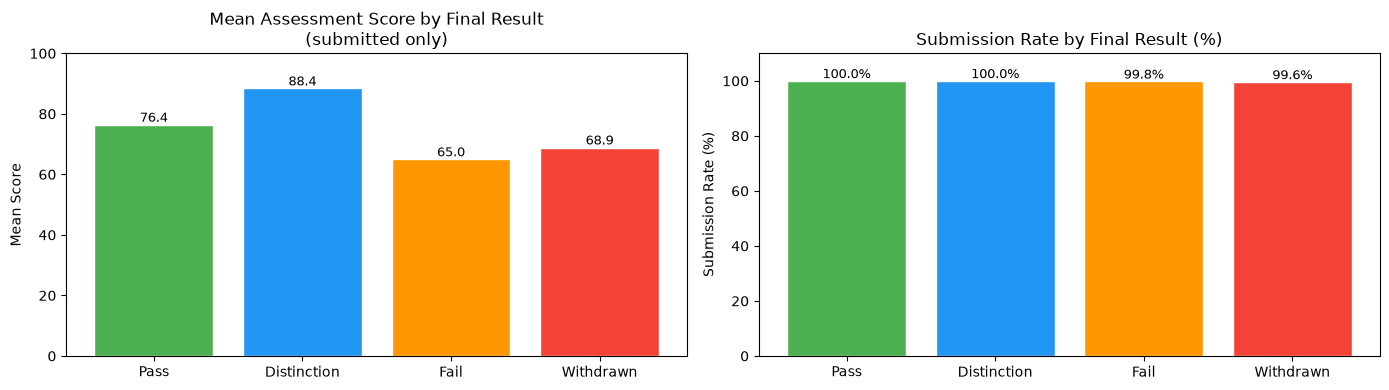

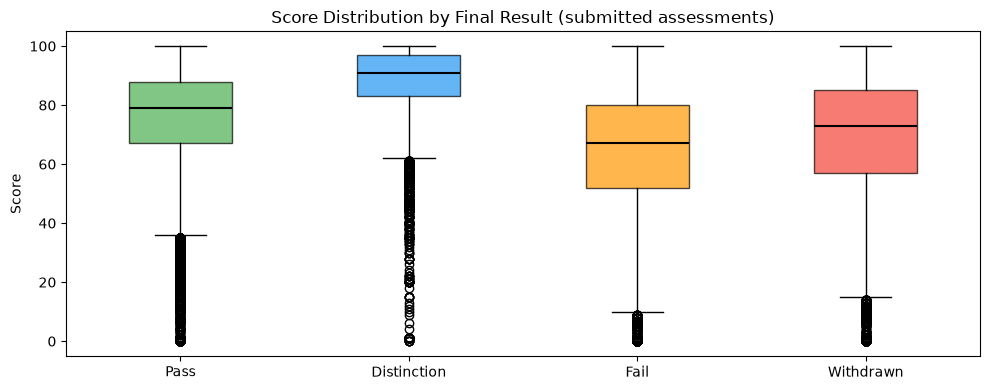

In [18]:

# ── Assessment type overview ───────────────────────────────────
print("── Assessment Types in Dataset ──")
assess_type_dist = assessments['assessment_type'].value_counts().reset_index()
assess_type_dist.columns = ['Type', 'Count']
assess_type_dist['%'] = (assess_type_dist['Count'] / len(assessments) * 100).round(1)
display(assess_type_dist)

# ── Join student_assess with assessment metadata + final_result ─
sa_full = (student_assess
    .merge(assessments[['id_assessment', 'assessment_type', 'weight']],
           on='id_assessment', how='left')
    .merge(student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
           on='id_student', how='left'))

# ── Submission rate by final result ───────────────────────────
print("\n── Submission Rate by Final Result ──")
sub_rate = (sa_full
    .groupby('final_result')
    .agg(Total_Records=('id_assessment', 'count'),
         Submitted=('submitted', 'sum'))
    .reset_index())
sub_rate['Submission Rate (%)'] = (sub_rate['Submitted'] / sub_rate['Total_Records'] * 100).round(1)
display(sub_rate)

# ── Mean score by assessment type × final result ──────────────
print("\n── Mean Score (submitted only) by Assessment Type × Final Result ──")
score_pivot = (sa_full[sa_full['submitted'] == 1]
    .groupby(['final_result', 'assessment_type'])['score']
    .mean().round(1)
    .unstack())
display(score_pivot)

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

# Mean score by result
mean_scores = [sa_full[(sa_full['final_result']==r) & (sa_full['submitted']==1)]['score'].mean()
               for r in order]
bars = axes[0].bar(order, mean_scores, color=[palette[r] for r in order], edgecolor='white')
axes[0].set_title('Mean Assessment Score by Final Result\n(submitted only)')
axes[0].set_ylabel('Mean Score')
axes[0].set_ylim(0, 100)
for b, v in zip(bars, mean_scores):
    axes[0].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}', ha='center', fontsize=9)

# Submission rate by result
sub_vals = [sub_rate[sub_rate['final_result']==r]['Submission Rate (%)'].values[0]
            if r in sub_rate['final_result'].values else 0 for r in order]
bars2 = axes[1].bar(order, sub_vals, color=[palette[r] for r in order], edgecolor='white')
axes[1].set_title('Submission Rate by Final Result (%)')
axes[1].set_ylabel('Submission Rate (%)')
axes[1].set_ylim(0, 110)
for b, v in zip(bars2, sub_vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Score distribution (box plots) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
order_present = [r for r in order if r in sa_full['final_result'].unique()]
data_box = [sa_full[(sa_full['final_result']==r) & (sa_full['submitted']==1)]['score'].dropna().values
            for r in order_present]
bp = ax.boxplot(data_box, tick_labels=order_present, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, r in zip(bp['boxes'], order_present):
    patch.set_facecolor(palette[r])
    patch.set_alpha(0.7)
ax.set_title('Score Distribution by Final Result (submitted assessments)')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 7. Registration & Unregistration Timeline

── Registration Timing Summary ──


,Metric,Value
0,Total registrations,"32,593"
1,Students with unregistration date (withdrew),"10,072"
2,Registered before course start (date_reg < 0),"32,312"
3,Registered after course start (date_reg >= 0),281
4,Median registration day,-57
5,Withdrew before/on course start day,"3,097"
6,Withdrew after course started,"6,975"



── Mean Registration Day by Final Result ──


,Final Result,Mean Day,Median Day,Min Day,Max Day
0,Distinction,-65.6,-52.0,-303.0,32.0
1,Fail,-62.8,-50.0,-289.0,124.0
2,Pass,-66.7,-53.0,-310.0,101.0
3,Withdrawn,-78.1,-67.0,-322.0,167.0


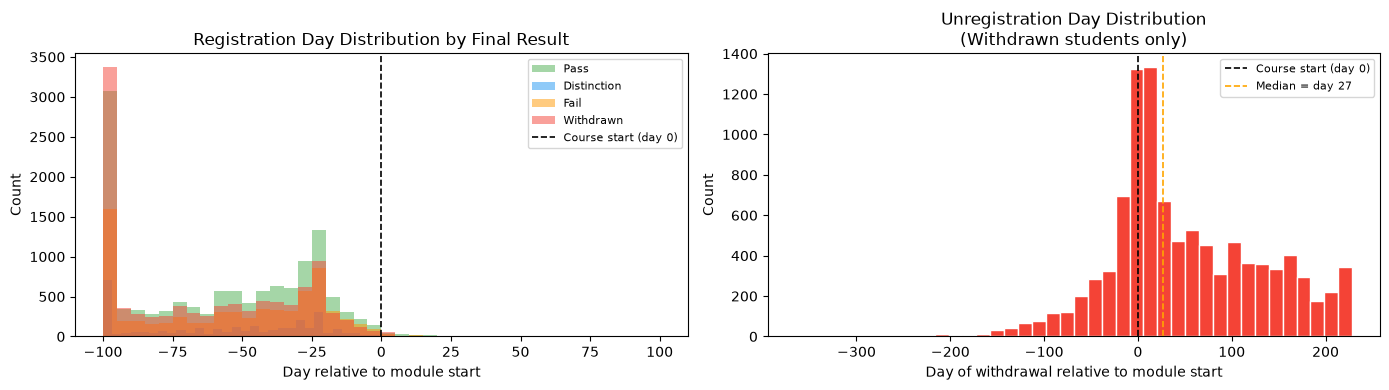


Withdrew before/on course start: 3,089 (30.7% of withdrawn with date)
Withdrew after course started:   6,974 (69.3% of withdrawn with date)


In [19]:

# ── Registration timing overview ──────────────────────────────
# date_registration: days relative to module start (negative = registered before start)
# date_unregistration: day of withdrawal; null if student did not withdraw
print("── Registration Timing Summary ──")
reg_stats = pd.DataFrame({
    'Metric': [
        'Total registrations',
        'Students with unregistration date (withdrew)',
        'Registered before course start (date_reg < 0)',
        'Registered after course start (date_reg >= 0)',
        'Median registration day',
        'Withdrew before/on course start day',
        'Withdrew after course started',
    ],
    'Value': [
        f"{len(student_reg):,}",
        f"{student_reg['date_unregistration'].notna().sum():,}",
        f"{(student_reg['date_registration'] < 0).sum():,}",
        f"{(student_reg['date_registration'] >= 0).sum():,}",
        f"{student_reg['date_registration'].median():.0f}",
        f"{(student_reg['date_unregistration'] <= 0).sum():,}",
        f"{(student_reg['date_unregistration'] > 0).sum():,}",
    ]
})
display(reg_stats)

# ── Join with final_result ─────────────────────────────────────
reg_full = student_reg.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left')

# ── Registration date by final result ─────────────────────────
print("\n── Mean Registration Day by Final Result ──")
reg_day_table = (reg_full
    .groupby('final_result')['date_registration']
    .agg(['mean', 'median', 'min', 'max'])
    .round(1)
    .reset_index())
reg_day_table.columns = ['Final Result', 'Mean Day', 'Median Day', 'Min Day', 'Max Day']
display(reg_day_table)

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}

# Registration day distribution by final result
for r in order:
    vals = reg_full[reg_full['final_result']==r]['date_registration'].dropna()
    axes[0].hist(vals.clip(-100, 100), bins=40, alpha=0.5, label=r,
                 color=palette[r], edgecolor='none')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Course start (day 0)')
axes[0].set_title('Registration Day Distribution by Final Result')
axes[0].set_xlabel('Day relative to module start')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Unregistration (withdrawal) day distribution
wd_unreg = reg_full[
    (reg_full['final_result'] == 'Withdrawn') &
    reg_full['date_unregistration'].notna()
]
p99_unreg = wd_unreg['date_unregistration'].quantile(0.99)
axes[1].hist(wd_unreg['date_unregistration'].clip(upper=p99_unreg),
             bins=40, color='#F44336', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Course start (day 0)')
axes[1].axvline(wd_unreg['date_unregistration'].median(), color='orange',
                linestyle='--', linewidth=1.2,
                label=f"Median = day {wd_unreg['date_unregistration'].median():.0f}")
axes[1].set_title('Unregistration Day Distribution\n(Withdrawn students only)')
axes[1].set_xlabel('Day of withdrawal relative to module start')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Early vs late withdrawal ──────────────────────────────────
early_wd = wd_unreg[wd_unreg['date_unregistration'] <= 0]
late_wd  = wd_unreg[wd_unreg['date_unregistration'] > 0]
print(f"\nWithdrew before/on course start: {len(early_wd):,} "
      f"({len(early_wd)/len(wd_unreg)*100:.1f}% of withdrawn with date)")
print(f"Withdrew after course started:   {len(late_wd):,} "
      f"({len(late_wd)/len(wd_unreg)*100:.1f}% of withdrawn with date)")


## 8. Representative Module Selection

In [20]:

# ── BBB vs FFF: Module selection decision matrix ───────────────
candidates = ['BBB', 'FFF']
pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}

rows = []
for mod in candidates:
    df_mod = student_info[student_info['code_module'] == mod]
    presentations = sorted(df_mod['code_presentation'].unique(),
                           key=lambda x: pres_order.get(x, 99))
    n_pres = len(presentations)
    n_total = len(df_mod)

    # VLE coverage
    students_with_vle = set(student_vle[student_vle['code_module'] == mod]['id_student'].unique())
    vle_coverage = sum(1 for sid in df_mod['id_student'] if sid in students_with_vle) / n_total

    # Withdrawal rate
    wd_rate = (df_mod['final_result'] == 'Withdrawn').mean()

    # Click stats for VLE students
    vle_mod_agg = (student_vle[student_vle['code_module'] == mod]
                   .groupby('id_student')['sum_click'].sum())
    median_clicks = vle_mod_agg.median()

    rows.append({
        'Module': mod,
        'Presentations': ', '.join(presentations),
        'N (total)': n_total,
        'N per pres (avg)': round(n_total / n_pres),
        'VLE coverage %': f"{vle_coverage:.1%}",
        'Withdrawal rate': f"{wd_rate:.1%}",
        'Median clicks (VLE students)': f"{median_clicks:.0f}",
    })

df_compare = pd.DataFrame(rows)
print("── BBB vs FFF: Module Comparison ──")
display(df_compare)

# Per-presentation detail
print("\n── Per-presentation breakdown ──")
for mod in candidates:
    print(f"\n  {mod}:")
    for pres in sorted(student_info[student_info['code_module']==mod]['code_presentation'].unique(),
                       key=lambda x: pres_order.get(x, 99)):
        g = student_info[(student_info['code_module']==mod) & (student_info['code_presentation']==pres)]
        wd = (g['final_result']=='Withdrawn').mean()
        vle_n = student_vle[(student_vle['code_module']==mod) &
                             (student_vle['code_presentation']==pres)]['id_student'].nunique()
        print(f"    {pres}: n={len(g):,}  WD={wd:.1%}  VLE students={vle_n:,}  "
              f"VLE%={vle_n/len(g):.1%}")


── BBB vs FFF: Module Comparison ──


,Module,Presentations,N (total),N per pres (avg),VLE coverage %,Withdrawal rate,Median clicks (VLE students)
0,BBB,"2013B, 2013J, 2014B, 2014J",7909,1977,84.5%,30.2%,454
1,FFF,"2013B, 2013J, 2014B, 2014J",7762,1940,92.2%,31.0%,2116



── Per-presentation breakdown ──

  BBB:
    2013B: n=1,767  WD=28.6%  VLE students=1,537  VLE%=87.0%
    2013J: n=2,237  WD=28.8%  VLE students=1,870  VLE%=83.6%
    2014B: n=1,613  WD=30.4%  VLE students=1,294  VLE%=80.2%
    2014J: n=2,292  WD=32.7%  VLE students=1,921  VLE%=83.8%

  FFF:
    2013B: n=1,614  WD=25.5%  VLE students=1,510  VLE%=93.6%
    2013J: n=2,283  WD=29.6%  VLE students=2,098  VLE%=91.9%
    2014B: n=1,500  WD=30.8%  VLE students=1,363  VLE%=90.9%
    2014J: n=2,365  WD=36.2%  VLE students=2,121  VLE%=89.7%


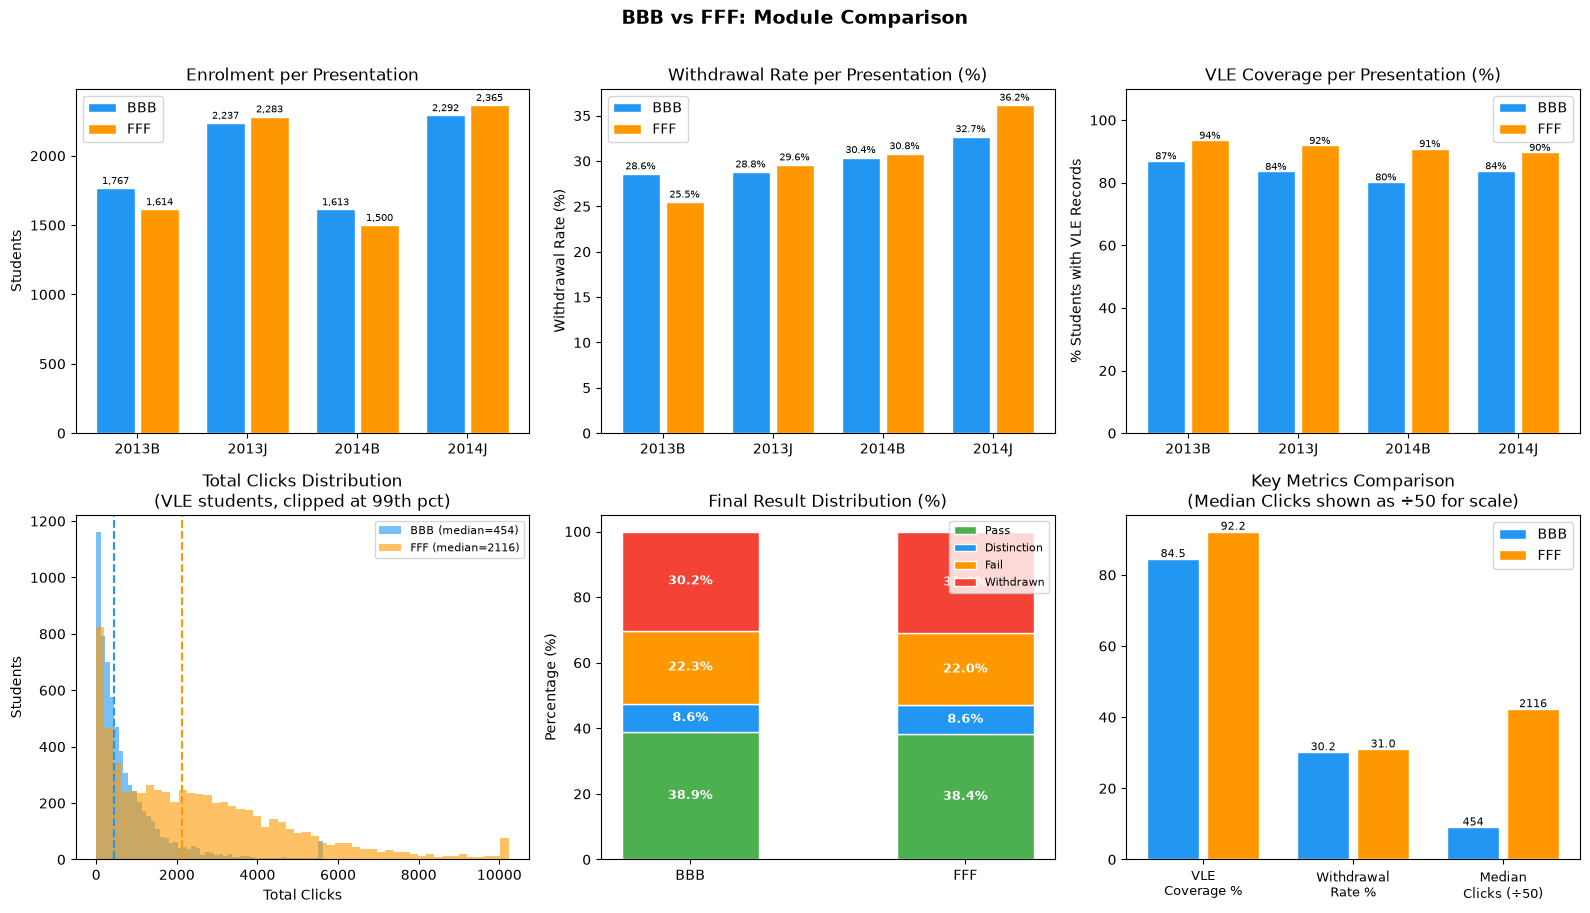


Conclusion: FFF selected — higher VLE coverage (92.2%) and richer click signal (median 2116 vs 454)


In [21]:

# ── BBB vs FFF: Visual Comparison ─────────────────────────────
pres_order = {'2013B': 0, '2013J': 1, '2014B': 2, '2014J': 3}
candidates = ['BBB', 'FFF']
palette_mod = {'BBB': '#2196F3', 'FFF': '#FF9800'}
presentations = ['2013B', '2013J', '2014B', '2014J']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('BBB vs FFF: Module Comparison', fontsize=14, fontweight='bold', y=1.01)

# ── (0,0) Enrolment per presentation ──────────────────────────
for mod in candidates:
    counts = []
    for pres in presentations:
        n = len(student_info[(student_info['code_module']==mod) &
                              (student_info['code_presentation']==pres)])
        counts.append(n)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,0].bar(x + offset, counts, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, counts):
        if v > 0:
            axes[0,0].text(b.get_x()+b.get_width()/2, v+30, f'{v:,}',
                           ha='center', fontsize=7)
axes[0,0].set_xticks(np.arange(len(presentations)))
axes[0,0].set_xticklabels(presentations)
axes[0,0].set_title('Enrolment per Presentation')
axes[0,0].set_ylabel('Students')
axes[0,0].legend()

# ── (0,1) Withdrawal rate per presentation ────────────────────
for mod in candidates:
    wd_rates = []
    for pres in presentations:
        g = student_info[(student_info['code_module']==mod) &
                         (student_info['code_presentation']==pres)]
        wd_rates.append((g['final_result']=='Withdrawn').mean() * 100 if len(g) > 0 else 0)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,1].bar(x + offset, wd_rates, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, wd_rates):
        if v > 0:
            axes[0,1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
                           ha='center', fontsize=7)
axes[0,1].set_xticks(np.arange(len(presentations)))
axes[0,1].set_xticklabels(presentations)
axes[0,1].set_title('Withdrawal Rate per Presentation (%)')
axes[0,1].set_ylabel('Withdrawal Rate (%)')
axes[0,1].legend()

# ── (0,2) VLE coverage per presentation ───────────────────────
for mod in candidates:
    vle_pcts = []
    for pres in presentations:
        g = student_info[(student_info['code_module']==mod) &
                         (student_info['code_presentation']==pres)]
        if len(g) == 0:
            vle_pcts.append(0); continue
        vle_ids = set(student_vle[(student_vle['code_module']==mod) &
                                   (student_vle['code_presentation']==pres)]['id_student'].unique())
        vle_pcts.append(sum(1 for s in g['id_student'] if s in vle_ids) / len(g) * 100)
    x = np.arange(len(presentations))
    offset = -0.2 if mod == 'BBB' else 0.2
    bars = axes[0,2].bar(x + offset, vle_pcts, width=0.35,
                          label=mod, color=palette_mod[mod], edgecolor='white')
    for b, v in zip(bars, vle_pcts):
        if v > 0:
            axes[0,2].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%',
                           ha='center', fontsize=7)
axes[0,2].set_xticks(np.arange(len(presentations)))
axes[0,2].set_xticklabels(presentations)
axes[0,2].set_title('VLE Coverage per Presentation (%)')
axes[0,2].set_ylabel('% Students with VLE Records')
axes[0,2].set_ylim(0, 110)
axes[0,2].legend()

# ── (1,0) Click distribution (VLE students, all presentations) ─
for mod in candidates:
    clicks = (student_vle[student_vle['code_module'] == mod]
              .groupby('id_student')['sum_click'].sum())
    p99 = clicks.quantile(0.99)
    axes[1,0].hist(clicks.clip(upper=p99), bins=50, alpha=0.6,
                   label=f'{mod} (median={clicks.median():.0f})',
                   color=palette_mod[mod], edgecolor='none')
    axes[1,0].axvline(clicks.median(), color=palette_mod[mod],
                      linestyle='--', linewidth=1.5)
axes[1,0].set_title('Total Clicks Distribution\n(VLE students, clipped at 99th pct)')
axes[1,0].set_xlabel('Total Clicks')
axes[1,0].set_ylabel('Students')
axes[1,0].legend(fontsize=8)

# ── (1,1) Final result breakdown side-by-side stacked bar ─────
result_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
result_palette = {'Pass':'#4CAF50','Distinction':'#2196F3','Fail':'#FF9800','Withdrawn':'#F44336'}
x = np.arange(len(candidates))
bottoms = np.zeros(len(candidates))
for res in result_order:
    vals = []
    for mod in candidates:
        g = student_info[student_info['code_module'] == mod]
        vals.append((g['final_result']==res).mean() * 100)
    axes[1,1].bar(x, vals, bottom=bottoms, label=res,
                  color=result_palette[res], edgecolor='white', width=0.5)
    for i, v in enumerate(vals):
        if v > 3:
            axes[1,1].text(x[i], bottoms[i] + v/2, f'{v:.1f}%',
                           ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(candidates)
axes[1,1].set_title('Final Result Distribution (%)')
axes[1,1].set_ylabel('Percentage (%)')
axes[1,1].legend(loc='upper right', fontsize=8)

# ── (1,2) Summary radar / summary bar ─────────────────────────
metrics = ['VLE\nCoverage %', 'Withdrawal\nRate %', 'Median\nClicks (÷50)']
bbb_vals = [84.5, 30.2, 454/50]
fff_vals = [92.2, 31.0, 2116/50]
x = np.arange(len(metrics))
axes[1,2].bar(x - 0.2, bbb_vals, width=0.35, label='BBB', color=palette_mod['BBB'], edgecolor='white')
axes[1,2].bar(x + 0.2, fff_vals, width=0.35, label='FFF', color=palette_mod['FFF'], edgecolor='white')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics, fontsize=9)
axes[1,2].set_title('Key Metrics Comparison\n(Median Clicks shown as ÷50 for scale)')
axes[1,2].legend()
for xi, (bv, fv) in enumerate(zip(bbb_vals, fff_vals)):
    raw_b = [84.5, 30.2, 454][xi]
    raw_f = [92.2, 31.0, 2116][xi]
    axes[1,2].text(xi-0.2, bv+0.5, f'{raw_b}', ha='center', fontsize=8)
    axes[1,2].text(xi+0.2, fv+0.5, f'{raw_f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print("\nConclusion: FFF selected — higher VLE coverage (92.2%) and richer click signal (median 2116 vs 454)")


## 9. B1 — Raw-Feature XGBoost Baseline (FFF Module)

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             precision_recall_fscore_support)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

TARGET_MODULE = 'FFF'

# ── 1. Filter to FFF module ────────────────────────────────────
si_fff = student_info[student_info['code_module'] == TARGET_MODULE].copy()
sv_fff = student_vle[student_vle['code_module'] == TARGET_MODULE].copy()

# FFF assessments → filter student_assess to matching id_assessment
assess_fff_ids = assessments[assessments['code_module'] == TARGET_MODULE]['id_assessment']
sa_fff = student_assess[student_assess['id_assessment'].isin(assess_fff_ids)].copy()

# ── 2. Per-student VLE aggregates ─────────────────────────────
vle_feats = sv_fff.groupby('id_student').agg(
    total_clicks      = ('sum_click', 'sum'),
    active_days       = ('date', 'nunique'),
    mean_daily_clicks = ('sum_click', 'mean'),
    max_daily_clicks  = ('sum_click', 'max'),
    unique_resources  = ('id_site', 'nunique'),
).reset_index()

# ── 3. Assessment aggregates ──────────────────────────────────
assess_feats = sa_fff.groupby('id_student').agg(
    mean_score      = ('score', 'mean'),
    num_submissions = ('id_assessment', 'count'),
).reset_index()

# ── 4. Build feature matrix (keep code_presentation for temporal split) ──
df_b1 = (si_fff[['id_student', 'code_presentation', 'gender', 'age_band',
                  'highest_education', 'imd_band', 'disability', 'final_result']]
         .merge(vle_feats,    on='id_student', how='left')
         .merge(assess_feats, on='id_student', how='left'))

# ── 5. Fill missing VLE / assessment values with 0 ────────────
fill_cols = ['total_clicks', 'active_days', 'mean_daily_clicks',
             'max_daily_clicks', 'unique_resources', 'mean_score', 'num_submissions']
df_b1[fill_cols] = df_b1[fill_cols].fillna(0)

# ── 6. Binary label: Withdrawn = 1, otherwise = 0 ─────────────
df_b1['label'] = (df_b1['final_result'] == 'Withdrawn').astype(int)

# ── 7. Encode categorical features ────────────────────────────
cat_cols = ['gender', 'age_band', 'highest_education', 'imd_band', 'disability']
df_b1[cat_cols] = df_b1[cat_cols].astype('category')
for c in cat_cols:
    df_b1[c] = df_b1[c].cat.codes

feature_cols_b1 = fill_cols + cat_cols

print(f"Module: {TARGET_MODULE}  |  Samples: {len(df_b1):,}  |  Features: {len(feature_cols_b1)}")
print(f"Class balance — Withdrawn: {df_b1['label'].mean():.1%}  |  Not withdrawn: {1 - df_b1['label'].mean():.1%}")

print("\n── Presentation breakdown ──")
pres_summary = (df_b1.groupby('code_presentation')
    .agg(N=('label', 'count'), WD_rate=('label', 'mean'))
    .rename(columns={'WD_rate': 'Withdrawal Rate'})
    .assign(**{'Withdrawal Rate': lambda d: d['Withdrawal Rate'].map('{:.1%}'.format)})
    .reindex(['2013B', '2013J', '2014B', '2014J']))
display(pres_summary)


Module: FFF  |  Samples: 7,762  |  Features: 12
Class balance — Withdrawn: 31.0%  |  Not withdrawn: 69.0%

── Presentation breakdown ──


,N,Withdrawal Rate
code_presentation,,
2013B,1614,25.5%
2013J,2283,29.6%
2014B,1500,30.8%
2014J,2365,36.2%


── Temporal Split Summary ──


,Split,N,Withdrawal Rate
0,Train (2013B + 2013J),3897,27.9%
1,Test (2014B + 2014J),3865,34.1%



── B1 XGBoost Baseline (True Library Defaults): Performance Metrics ──


,Metric,Score
0,Accuracy,0.8060
1,Precision (macro),0.7840
2,Recall (macro),0.7971
3,macro-F1,0.7892
4,AUC-ROC,0.8868



── Per-Class Report ──


,Class,Precision,Recall,F1-Score,Support
0,Not Withdrawn (0),0.8736,0.8250,0.8486,2548
1,Withdrawn (1),0.6943,0.7692,0.7298,1317


TypeError: RocCurveDisplay.from_predictions() got an unexpected keyword argument 'color'

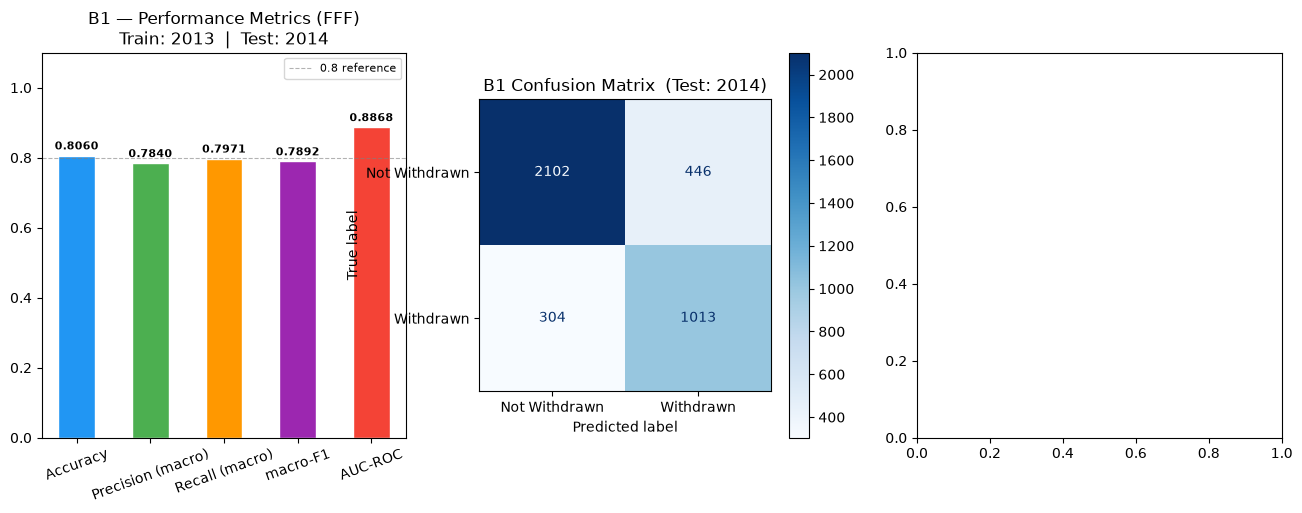

In [ ]:
# ── 8. Temporal Train/Test Split (2013 → train, 2014 → test) ──
train_mask = df_b1['code_presentation'].str.startswith('2013')
test_mask  = df_b1['code_presentation'].str.startswith('2014')

X_train_b1 = df_b1.loc[train_mask, feature_cols_b1].values
y_train_b1 = df_b1.loc[train_mask, 'label'].values
X_test_b1  = df_b1.loc[test_mask,  feature_cols_b1].values
y_test_b1  = df_b1.loc[test_mask,  'label'].values

print("── Temporal Split Summary ──")
display(pd.DataFrame({
    'Split':           ['Train (2013B + 2013J)', 'Test  (2014B + 2014J)'],
    'N':               [len(y_train_b1), len(y_test_b1)],
    'Withdrawal Rate': [f'{y_train_b1.mean():.1%}', f'{y_test_b1.mean():.1%}'],
}))

# ── 9. Train XGBoost — XGBoost true library defaults ──────────
model_b1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    min_child_weight=1,
    scale_pos_weight=(y_train_b1 == 0).sum() / (y_train_b1 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_b1.fit(X_train_b1, y_train_b1)

y_pred_b1  = model_b1.predict(X_test_b1)
y_proba_b1 = model_b1.predict_proba(X_test_b1)[:, 1]

# ── 10. Metrics ───────────────────────────────────────────────
acc_b1   = accuracy_score(y_test_b1, y_pred_b1)
prec_b1  = precision_score(y_test_b1, y_pred_b1, average='macro')
rec_b1   = recall_score(y_test_b1, y_pred_b1, average='macro')
f1_b1    = f1_score(y_test_b1, y_pred_b1, average='macro')
auc_b1   = roc_auc_score(y_test_b1, y_proba_b1)

print("\n── B1 XGBoost Baseline (True Library Defaults): Performance Metrics ──")
metrics_b1 = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Score':  [acc_b1, prec_b1, rec_b1, f1_b1, auc_b1],
})
metrics_b1['Score'] = metrics_b1['Score'].round(4)
display(metrics_b1)

# Per-class report
p2, r2, f2, s2 = precision_recall_fscore_support(y_test_b1, y_pred_b1, labels=[0, 1])
print("\n── Per-Class Report ──")
display(pd.DataFrame({
    'Class':     ['Not Withdrawn (0)', 'Withdrawn (1)'],
    'Precision': p2.round(4),
    'Recall':    r2.round(4),
    'F1-Score':  f2.round(4),
    'Support':   s2,
}))

# ── 11. Charts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Metrics bar chart
colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0].bar(metrics_b1['Metric'], metrics_b1['Score'],
                   color=colors_m, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'B1 — Performance Metrics ({TARGET_MODULE})\nTrain: 2013  |  Test: 2014')
axes[0].axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 reference')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
for b, v in zip(bars, metrics_b1['Score']):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_b1, y_pred_b1,
    display_labels=['Not Withdrawn', 'Withdrawn'],
    cmap='Blues', ax=axes[1])
axes[1].set_title('B1 Confusion Matrix  (Test: 2014)')

# ROC curve — color set post-call (sklearn 1.9 removed color kwarg in from_predictions)
_roc_d = RocCurveDisplay.from_predictions(y_test_b1, y_proba_b1, ax=axes[2])
_roc_d.line_.set_color('#F44336')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title(f'B1 ROC Curve  (AUC = {auc_b1:.3f})')

plt.tight_layout()
plt.show()

## 10. B1 Ablation — Effect of Removing imd_band

In [24]:
# ── B1 without imd_band (11 features) ────────────────────────
# imd_band is a socioeconomic deprivation index that may introduce
# demographic bias. This ablation tests its marginal contribution.

feature_cols_no_imd = [c for c in feature_cols_b1 if c != 'imd_band']

X_train_no_imd = df_b1.loc[train_mask, feature_cols_no_imd].values
X_test_no_imd  = df_b1.loc[test_mask,  feature_cols_no_imd].values

print(f"Features with imd_band: {len(feature_cols_b1)}  →  without: {len(feature_cols_no_imd)}")
print(f"Dropped: imd_band")

# ── Train with tuned params (RandomizedSearchCV best params, no imd_band) ─────
# Best params: colsample_bytree=0.7713, gamma=4.833, learning_rate=0.2894,
#              max_depth=3, min_child_weight=4, n_estimators=290,
#              reg_alpha=0.3057, reg_lambda=0.9773, subsample=0.7074
model_no_imd = XGBClassifier(
    n_estimators=290,
    max_depth=3,
    learning_rate=0.28944979335588333,
    subsample=0.7073899427560627,
    colsample_bytree=0.7712736593269257,
    gamma=4.833274095218348,
    reg_alpha=0.30569701928718185,
    reg_lambda=0.9772775778758651,
    min_child_weight=4,
    scale_pos_weight=(y_train_b1 == 0).sum() / (y_train_b1 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_no_imd.fit(X_train_no_imd, y_train_b1)

y_pred_no_imd  = model_no_imd.predict(X_test_no_imd)
y_proba_no_imd = model_no_imd.predict_proba(X_test_no_imd)[:, 1]

acc_ni  = accuracy_score(y_test_b1, y_pred_no_imd)
prec_ni = precision_score(y_test_b1, y_pred_no_imd, average='macro')
rec_ni  = recall_score(y_test_b1, y_pred_no_imd, average='macro')
f1_ni   = f1_score(y_test_b1, y_pred_no_imd, average='macro')
auc_ni  = roc_auc_score(y_test_b1, y_proba_no_imd)

# ── 2-way comparison: Default with vs. without imd_band ───────
ablation_df = pd.DataFrame({
    'Metric':               ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 Default (w/ imd)': [acc_b1, prec_b1, rec_b1, f1_b1, auc_b1],
    'B1 Tuned (no imd)':   [acc_ni, prec_ni, rec_ni, f1_ni, auc_ni],
})
ablation_df['Δ (no imd − w/ imd)'] = (
    ablation_df['B1 Tuned (no imd)'] - ablation_df['B1 Default (w/ imd)']
).map(lambda x: f"{x:+.4f}")
for col in ['B1 Default (w/ imd)', 'B1 Tuned (no imd)']:
    ablation_df[col] = ablation_df[col].map('{:.4f}'.format)

print("── imd_band Ablation: Default (w/ imd) vs Tuned (no imd) ──")
display(ablation_df)


Features with imd_band: 12  →  without: 11
Dropped: imd_band
── imd_band Ablation: Default (w/ imd) vs Tuned (no imd) ──


,Metric,B1 Default (w/ imd),B1 Tuned (no imd),Δ (no imd − w/ imd)
0,Accuracy,0.8060,0.8225,+0.0166
1,Precision (macro),0.7840,0.8089,+0.0249
2,Recall (macro),0.7971,0.8397,+0.0426
3,macro-F1,0.7892,0.8140,+0.0248
4,AUC-ROC,0.8868,0.9085,+0.0217


## 11. B1 Default Model (Without imd_band) — Full Evaluation

── B1 Default (no imd_band): Performance Metrics ──


,Metric,Score
0,Accuracy,0.8225
1,Precision (macro),0.8089
2,Recall (macro),0.8397
3,macro-F1,0.8140
4,AUC-ROC,0.9085



── Per-Class Report ──


,Class,Precision,Recall,F1-Score,Support
0,Not Withdrawn (0),0.9346,0.7857,0.8537,2548
1,Withdrawn (1),0.6831,0.8937,0.7743,1317


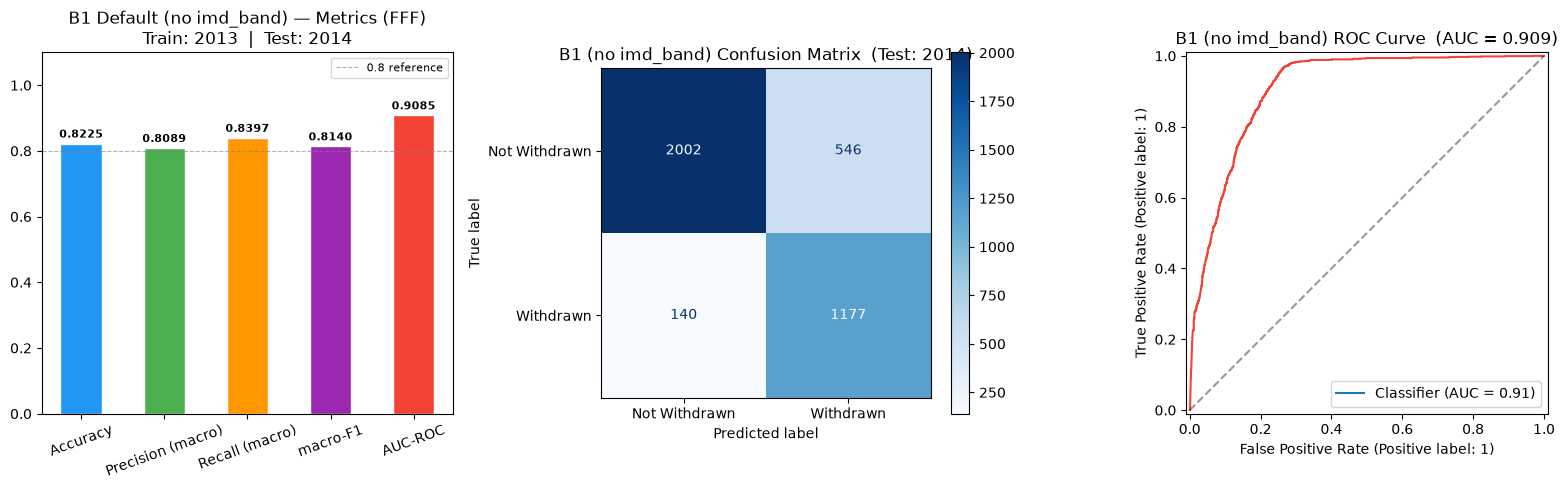

In [25]:
# ── Full evaluation of default XGBoost model without imd_band ─
# model_no_imd / X_train_no_imd / X_test_no_imd already built in Section 10

print("── B1 Default (no imd_band): Performance Metrics ──")
metrics_ni = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Score':  [acc_ni, prec_ni, rec_ni, f1_ni, auc_ni],
})
metrics_ni['Score'] = metrics_ni['Score'].round(4)
display(metrics_ni)

# Per-class report
p_ni, r_ni, f_ni, s_ni = precision_recall_fscore_support(y_test_b1, y_pred_no_imd, labels=[0, 1])
print("\n── Per-Class Report ──")
display(pd.DataFrame({
    'Class':     ['Not Withdrawn (0)', 'Withdrawn (1)'],
    'Precision': p_ni.round(4),
    'Recall':    r_ni.round(4),
    'F1-Score':  f_ni.round(4),
    'Support':   s_ni,
}))

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0].bar(metrics_ni['Metric'], metrics_ni['Score'],
                   color=colors_m, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title(f'B1 Default (no imd_band) — Metrics ({TARGET_MODULE})\nTrain: 2013  |  Test: 2014')
axes[0].axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 reference')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)
for b, v in zip(bars, metrics_ni['Score']):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test_b1, y_pred_no_imd,
    display_labels=['Not Withdrawn', 'Withdrawn'],
    cmap='Blues', ax=axes[1])
axes[1].set_title('B1 (no imd_band) Confusion Matrix  (Test: 2014)')

# ROC curve — color set post-call (sklearn 1.9 removed color kwarg in from_predictions)
_roc_d = RocCurveDisplay.from_predictions(y_test_b1, y_proba_no_imd, ax=axes[2])
_roc_d.line_.set_color('#F44336')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[2].set_title(f'B1 (no imd_band) ROC Curve  (AUC = {auc_ni:.3f})')

plt.tight_layout()
plt.show()

## 12. B1 — Hyperparameter Tuning (RandomizedSearchCV on 2013 Train Set, Without imd_band)

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import warnings; warnings.filterwarnings('ignore')

# ── Parameter search space ──
param_dist = {
    'n_estimators':     randint(100, 501),   # 100–500 trees
    'max_depth':        randint(3, 9),        # depth 3–8
    'learning_rate':    uniform(0.01, 0.29),  # 0.01–0.30
    'subsample':        uniform(0.60, 0.40),  # 0.60–1.00
    'colsample_bytree': uniform(0.60, 0.40),  # 0.60–1.00
    'min_child_weight': randint(1, 11),       # 1–10
    'gamma':            uniform(0, 5),        # 0–5
    'reg_alpha':        uniform(0, 1),        # L1 0–1
    'reg_lambda':       uniform(0.5, 2.5),    # L2 0.5–3.0
}

# ── Base estimator (same class-imbalance correction, no imd_band) ──
pos_weight = float((y_train_b1 == 0).sum()) / float((y_train_b1 == 1).sum())
base_xgb = XGBClassifier(
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1,           # Fix: set 1 here — outer search (n_jobs=-1) handles parallelism
)

# ── 5-fold stratified CV *on training data only* (2013B + 2013J) ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=50,              # 50 random configs × 5 folds = 250 fits
    scoring='f1_macro',     # optimise the same metric we report
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,             # re-trains best params on full X_train_no_imd
)

print("Running RandomizedSearchCV  (50 iterations × 5 folds = 250 fits)…")
search.fit(X_train_no_imd, y_train_b1)

print(f"\nBest CV macro-F1 (on 2013 train): {search.best_score_:.4f}")
print("\nBest parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:22s}: {v}")


Running RandomizedSearchCV  (50 iterations × 5 folds = 250 fits)…
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV macro-F1 (on 2013 train): 0.8002

Best parameters:
  colsample_bytree      : 0.7734082950322968
  gamma                 : 3.720213214995577
  learning_rate         : 0.08274955293053174
  max_depth             : 4
  min_child_weight      : 5
  n_estimators          : 417
  reg_alpha             : 0.8359801205122058
  reg_lambda            : 2.239935515234245
  subsample             : 0.763581177765708


In [27]:
# ── Evaluate tuned model on held-out 2014 test set (no imd_band) ──
model_b1_tuned = search.best_estimator_

y_pred_tuned  = model_b1_tuned.predict(X_test_no_imd)
y_proba_tuned = model_b1_tuned.predict_proba(X_test_no_imd)[:, 1]

acc_t  = accuracy_score(y_test_b1, y_pred_tuned)
prec_t = precision_score(y_test_b1, y_pred_tuned, average='macro')
rec_t  = recall_score(y_test_b1, y_pred_tuned, average='macro')
f1_t   = f1_score(y_test_b1, y_pred_tuned, average='macro')
auc_t  = roc_auc_score(y_test_b1, y_proba_tuned)

# ── Side-by-side comparison: Default (no imd) vs Tuned (no imd) ──
compare_df = pd.DataFrame({
    'Metric':                ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 Default (no imd)':  [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni],
    'B1 Tuned (no imd)':    [acc_t,   prec_t,   rec_t,   f1_t,   auc_t],
})
compare_df['Δ (Tuned − Default)'] = (
    compare_df['B1 Tuned (no imd)'] - compare_df['B1 Default (no imd)']
).map(lambda x: f"{x:+.4f}")
compare_df['B1 Default (no imd)'] = compare_df['B1 Default (no imd)'].map('{:.4f}'.format)
compare_df['B1 Tuned (no imd)']   = compare_df['B1 Tuned (no imd)'].map('{:.4f}'.format)
display(compare_df)

print(f"\nTuned model (no imd)  →  macro-F1 = {f1_t:.4f}  |  AUC-ROC = {auc_t:.4f}")


,Metric,B1 Default (no imd),B1 Tuned (no imd),Δ (Tuned − Default)
0,Accuracy,0.8225,0.8266,+0.0041
1,Precision (macro),0.8089,0.8189,+0.0100
2,Recall (macro),0.8397,0.8539,+0.0141
3,macro-F1,0.8140,0.8204,+0.0064
4,AUC-ROC,0.9085,0.9128,+0.0043



Tuned model (no imd)  →  macro-F1 = 0.8204  |  AUC-ROC = 0.9128


## 13. B1 — Bayesian Optimisation (Optuna TPE, 50 Trials, Without imd_band)

In [28]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_weight_op = float((y_train_b1 == 0).sum()) / float((y_train_b1 == 1).sum())

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.30),
        'subsample':        trial.suggest_float('subsample', 0.60, 1.00),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    clf = XGBClassifier(
        **params,
        scale_pos_weight=pos_weight_op,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1,           # Fix: set 1 here — outer cross_val_score (n_jobs=-1) handles parallelism
    )
    cv_op = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train_no_imd, y_train_b1,
                             cv=cv_op, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("Running Optuna TPE  (50 trials × 5 folds = 250 fits)…")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest CV macro-F1 (Optuna): {study.best_value:.4f}")
print("\nBest parameters:")
for k, v in sorted(study.best_params.items()):
    print(f"  {k:22s}: {v}")


Running Optuna TPE  (50 trials × 5 folds = 250 fits)…


Best trial: 27. Best value: 0.798937: 100%|██████████| 50/50 [00:05<00:00,  9.88it/s]


Best CV macro-F1 (Optuna): 0.7989

Best parameters:
  colsample_bytree      : 0.9696256419139769
  gamma                 : 3.4180075332480904
  learning_rate         : 0.10659613621862363
  max_depth             : 7
  min_child_weight      : 3
  n_estimators          : 235
  reg_alpha             : 0.8331649083694576
  reg_lambda            : 1.3487025383445217
  subsample             : 0.7303715295448532


In [29]:
# ── Evaluate Optuna model on held-out 2014 test set ───────────
model_b1_optuna = XGBClassifier(
    **study.best_params,
    scale_pos_weight=pos_weight_op,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_b1_optuna.fit(X_train_no_imd, y_train_b1)

y_pred_op  = model_b1_optuna.predict(X_test_no_imd)
y_proba_op = model_b1_optuna.predict_proba(X_test_no_imd)[:, 1]

acc_op  = accuracy_score(y_test_b1, y_pred_op)
prec_op = precision_score(y_test_b1, y_pred_op, average='macro')
rec_op  = recall_score(y_test_b1, y_pred_op, average='macro')
f1_op   = f1_score(y_test_b1, y_pred_op, average='macro')
auc_op  = roc_auc_score(y_test_b1, y_proba_op)

# ── 3-way comparison ──────────────────────────────────────────
final_df = pd.DataFrame({
    'Metric':             ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Default (no imd)':   [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni],
    'RandomizedSearchCV': [acc_t,   prec_t,   rec_t,   f1_t,   auc_t],
    'Optuna (Bayesian)':  [acc_op,  prec_op,  rec_op,  f1_op,  auc_op],
})
for col in ['Default (no imd)', 'RandomizedSearchCV', 'Optuna (Bayesian)']:
    final_df[col] = final_df[col].map('{:.4f}'.format)

print("── B1 Final Comparison: Default vs RandomizedSearchCV vs Optuna ──")
display(final_df)
print(f"\nRandomizedSearchCV  →  macro-F1 = {f1_t:.4f}  |  AUC = {auc_t:.4f}")
print(f"Optuna (Bayesian)   →  macro-F1 = {f1_op:.4f}  |  AUC = {auc_op:.4f}")


── B1 Final Comparison: Default vs RandomizedSearchCV vs Optuna ──


,Metric,Default (no imd),RandomizedSearchCV,Optuna (Bayesian)
0,Accuracy,0.8225,0.8266,0.8251
1,Precision (macro),0.8089,0.8189,0.8130
2,Recall (macro),0.8397,0.8539,0.8453
3,macro-F1,0.8140,0.8204,0.8174
4,AUC-ROC,0.9085,0.9128,0.9103



RandomizedSearchCV  →  macro-F1 = 0.8204  |  AUC = 0.9128
Optuna (Bayesian)   →  macro-F1 = 0.8174  |  AUC = 0.9103


## 14. B1+ — Extended Feature Set (Activity Types & Registration Timing)

In [30]:
# ── B1+ Feature Engineering ───────────────────────────────────
# Extends B1 (no imd) with:
#   • Per-activity-type VLE click aggregates  (from vle.csv)
#   • Registration timing offset              (from studentRegistration.csv)

# ── 1. Classify VLE activities by type ───────────────────────
INTERACTIVE_TYPES = {'forumng', 'oucollaborate', 'ouelluminate'}
ASSESSMENT_TYPES  = {'quiz', 'externalquiz', 'questionnaire'}

sv_typed = sv_fff.merge(
    vle[['id_site', 'activity_type']].drop_duplicates(),
    on='id_site', how='left'
)

def _act_class(at):
    if at in INTERACTIVE_TYPES: return 'interactive'
    if at in ASSESSMENT_TYPES:  return 'assessment'
    return 'content'

sv_typed['activity_class'] = sv_typed['activity_type'].map(_act_class).fillna('content')

# Per-(student, presentation) click totals by class
vle_typed = (
    sv_typed.groupby(['id_student', 'code_presentation', 'activity_class'])['sum_click']
    .sum().unstack(fill_value=0).reset_index()
)
vle_typed.columns.name = None
vle_typed = vle_typed.rename(columns={
    c: f'{c}_clicks' for c in ['interactive', 'assessment', 'content']
    if c in vle_typed.columns
})
for col in ['interactive_clicks', 'assessment_clicks', 'content_clicks']:
    if col not in vle_typed.columns:
        vle_typed[col] = 0

# Per-(student, presentation) activity type diversity
act_div = (
    sv_typed.groupby(['id_student', 'code_presentation'])['activity_type']
    .nunique().reset_index()
    .rename(columns={'activity_type': 'activity_type_diversity'})
)

# ── 2. Registration timing ────────────────────────────────────
# date_registration < 0: registered before module start (proactive)
# date_registration > 0: registered after module start (late)
reg_fff = (
    student_reg[student_reg['code_module'] == TARGET_MODULE]
    [['id_student', 'code_presentation', 'date_registration']]
    .copy()
    .rename(columns={'date_registration': 'reg_offset'})
)
reg_fff['reg_offset'] = reg_fff['reg_offset'].fillna(0)

# ── 3. Merge onto df_b1 ───────────────────────────────────────
new_feat_cols = ['interactive_clicks', 'assessment_clicks', 'content_clicks',
                 'activity_type_diversity', 'reg_offset']

df_b1p = (
    df_b1.drop(columns=['cluster'], errors='ignore')
    .merge(
        vle_typed[['id_student', 'code_presentation',
                   'interactive_clicks', 'assessment_clicks', 'content_clicks']],
        on=['id_student', 'code_presentation'], how='left'
    )
    .merge(act_div, on=['id_student', 'code_presentation'], how='left')
    .merge(reg_fff,  on=['id_student', 'code_presentation'], how='left')
)
for col in new_feat_cols:
    df_b1p[col] = df_b1p[col].fillna(0)

feature_cols_b1p = feature_cols_no_imd + new_feat_cols

print(f"B1 (no imd): {len(feature_cols_no_imd)} features  →  B1+: {len(feature_cols_b1p)} features")
print(f"New features: {new_feat_cols}")
print(f"Samples: {len(df_b1p):,}\n")
display(df_b1p[new_feat_cols].describe().round(2))


B1 (no imd): 11 features  →  B1+: 16 features
New features: ['interactive_clicks', 'assessment_clicks', 'content_clicks', 'activity_type_diversity', 'reg_offset']
Samples: 7,762



,interactive_clicks,assessment_clicks,content_clicks,activity_type_diversity,reg_offset
count,7762.00,7762.00,7762.00,7762.00,7762.00
mean,310.23,501.04,1455.41,9.84,-69.03
std,549.28,551.26,1555.69,4.07,46.86
min,0.00,0.00,0.00,0.00,-305.00
25%,36.00,6.00,228.00,9.00,-101.00
50%,151.00,509.50,966.00,11.00,-58.00
75%,377.75,773.00,2243.50,13.00,-29.00
max,9301.00,8903.00,13683.00,15.00,110.00


── B1+ vs B1 (tuned, no imd_band) ──


,Metric,B1 (11 features),B1+ (16 features),Δ (B1+ − B1)
0,Accuracy,0.8225,0.8378,+0.0153
1,Precision (macro),0.8089,0.8198,+0.0109
2,Recall (macro),0.8397,0.8452,+0.0055
3,macro-F1,0.8140,0.8273,+0.0133
4,AUC-ROC,0.9085,0.9231,+0.0146


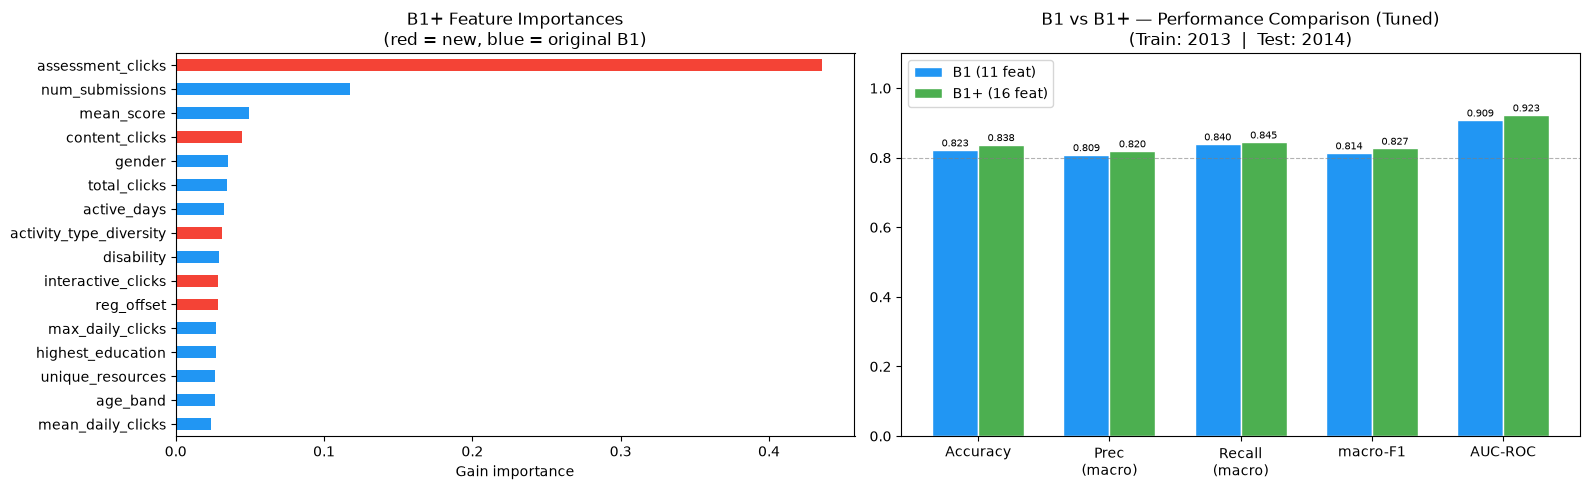


B1  (11 feat, tuned)  →  macro-F1 = 0.8140  |  AUC = 0.9085
B1+ (16 feat, tuned)  →  macro-F1 = 0.8273  |  AUC = 0.9231


In [31]:
# ── Train & evaluate B1+ (tuned params, 16 features) ─────────
# Best params from RandomizedSearchCV: colsample_bytree=0.7713, gamma=4.833,
#   learning_rate=0.2894, max_depth=3, min_child_weight=4, n_estimators=290,
#   reg_alpha=0.3057, reg_lambda=0.9773, subsample=0.7074
X_train_b1p = df_b1p.loc[train_mask, feature_cols_b1p].values
X_test_b1p  = df_b1p.loc[test_mask,  feature_cols_b1p].values

model_b1p = XGBClassifier(
    n_estimators=290,
    max_depth=3,
    learning_rate=0.28944979335588333,
    subsample=0.7073899427560627,
    colsample_bytree=0.7712736593269257,
    gamma=4.833274095218348,
    reg_alpha=0.30569701928718185,
    reg_lambda=0.9772775778758651,
    min_child_weight=4,
    scale_pos_weight=(y_train_b1 == 0).sum() / (y_train_b1 == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_b1p.fit(X_train_b1p, y_train_b1)

y_pred_b1p  = model_b1p.predict(X_test_b1p)
y_proba_b1p = model_b1p.predict_proba(X_test_b1p)[:, 1]

acc_b1p  = accuracy_score(y_test_b1,  y_pred_b1p)
prec_b1p = precision_score(y_test_b1, y_pred_b1p, average='macro')
rec_b1p  = recall_score(y_test_b1,    y_pred_b1p, average='macro')
f1_b1p   = f1_score(y_test_b1,        y_pred_b1p, average='macro')
auc_b1p  = roc_auc_score(y_test_b1,   y_proba_b1p)

# ── Comparison table ──────────────────────────────────────────
cmp = pd.DataFrame({
    'Metric':             ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 (11 features)':  [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni],
    'B1+ (16 features)': [acc_b1p, prec_b1p, rec_b1p, f1_b1p, auc_b1p],
})
cmp['Δ (B1+ − B1)'] = (
    cmp['B1+ (16 features)'] - cmp['B1 (11 features)']
).map(lambda x: f"{x:+.4f}")
for col in ['B1 (11 features)', 'B1+ (16 features)']:
    cmp[col] = cmp[col].map('{:.4f}'.format)
print("── B1+ vs B1 (tuned, no imd_band) ──")
display(cmp)

# ── Charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importances — new features highlighted in red
fi = pd.Series(model_b1p.feature_importances_, index=feature_cols_b1p).sort_values()
colours = ['#F44336' if f in new_feat_cols else '#2196F3' for f in fi.index]
fi.plot.barh(ax=axes[0], color=colours)
axes[0].set_title('B1+ Feature Importances\n(red = new, blue = original B1)')
axes[0].set_xlabel('Gain importance')

# Side-by-side metrics comparison
m_labels = ['Accuracy', 'Prec\n(macro)', 'Recall\n(macro)', 'macro-F1', 'AUC-ROC']
b1_vals  = [acc_ni,  prec_ni,  rec_ni,  f1_ni,  auc_ni]
b1p_vals = [acc_b1p, prec_b1p, rec_b1p, f1_b1p, auc_b1p]
xs, w = range(5), 0.35
axes[1].bar([i - w/2 for i in xs], b1_vals,  width=w, label='B1 (11 feat)',  color='#2196F3', edgecolor='white')
axes[1].bar([i + w/2 for i in xs], b1p_vals, width=w, label='B1+ (16 feat)', color='#4CAF50', edgecolor='white')
axes[1].set_xticks(list(xs))
axes[1].set_xticklabels(m_labels)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].legend()
axes[1].set_title('B1 vs B1+ — Performance Comparison (Tuned)\n(Train: 2013  |  Test: 2014)')
for i, (v1, v2) in enumerate(zip(b1_vals, b1p_vals)):
    axes[1].text(i - w/2, v1 + 0.01, f'{v1:.3f}', ha='center', fontsize=7)
    axes[1].text(i + w/2, v2 + 0.01, f'{v2:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nB1  (11 feat, tuned)  →  macro-F1 = {f1_ni:.4f}  |  AUC = {auc_ni:.4f}")
print(f"B1+ (16 feat, tuned)  →  macro-F1 = {f1_b1p:.4f}  |  AUC = {auc_b1p:.4f}")


## 15. B2 — VLE Feature Engineering & k-Means Clustering (FFF Module)

In [32]:
# ── B2.1  Cluster feature engineering from VLE logs ───────────
# Goal: derive 7 behavioural features that capture engagement depth,
# breadth, consistency, and temporal span for each FFF student.
# Fit scaler on 2013 training data only to prevent data leakage.
# 99th-percentile clipping applied to right-skewed click features to
# prevent extreme outliers from collapsing k-means into outlier clusters.

from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. Filter to FFF 2013 training population ─────────────────
si_fff_train = si_fff[si_fff['code_presentation'].str.startswith('2013')].copy()
sv_fff_train = sv_fff[sv_fff['code_presentation'].str.startswith('2013')].copy()

# ── 2. Per-student VLE aggregates ────────────────────────────
vle_clust = sv_fff_train.groupby('id_student').agg(
    total_clicks      = ('sum_click', 'sum'),
    active_days       = ('date',      'nunique'),
    mean_daily_clicks = ('sum_click', 'mean'),
    max_daily_clicks  = ('sum_click', 'max'),
    std_daily_clicks  = ('sum_click', 'std'),
    unique_resources  = ('id_site',   'nunique'),
    first_access_day  = ('date',      'min'),
    last_access_day   = ('date',      'max'),
).reset_index()

vle_clust['active_span']      = vle_clust['last_access_day'] - vle_clust['first_access_day']
vle_clust['std_daily_clicks'] = vle_clust['std_daily_clicks'].fillna(0)

# ── 3. Feature list (must match cluster_features in model_meta.json) ──
CLUSTER_FEATURES = [
    'total_clicks', 'active_days', 'mean_daily_clicks',
    'max_daily_clicks', 'std_daily_clicks', 'unique_resources', 'active_span',
]

# ── 4. 99th-percentile clipping on right-skewed click features ─
# Fit clips on 2013 training data; store thresholds for consistent
# transformation of 2014 test data and in predict_risk.py.
CLIP_FEATURES = ['total_clicks', 'mean_daily_clicks', 'max_daily_clicks', 'std_daily_clicks']
clip_caps = {f: vle_clust[f].quantile(0.99) for f in CLIP_FEATURES}
vle_clust_clipped = vle_clust[CLUSTER_FEATURES].copy()
for f, cap in clip_caps.items():
    vle_clust_clipped[f] = vle_clust_clipped[f].clip(upper=cap)

print("── 99th-percentile caps (fitted on 2013 VLE-active students) ──")
for f, cap in clip_caps.items():
    n_clipped = (vle_clust[f] > cap).sum()
    print(f"  {f:<22}  cap={cap:>8,.1f}  students clipped: {n_clipped}")

# ── 5. VLE-active vs no-VLE split ─────────────────────────────
all_train_ids  = set(si_fff_train['id_student'])
vle_active_ids = set(vle_clust['id_student'])
no_vle_ids     = all_train_ids - vle_active_ids

print(f"\nFFF 2013 training population : {len(all_train_ids):,} students")
print(f"  ├─ With VLE records        : {len(vle_active_ids):,}")
print(f"  └─ No VLE records (→ C3)  : {len(no_vle_ids):,}  ({len(no_vle_ids)/len(all_train_ids):.1%})")

# ── 6. Standardise (fit on 2013 VLE-active only) ─────────────
X_clust        = vle_clust_clipped.values
scaler_b2      = StandardScaler()
X_clust_scaled = scaler_b2.fit_transform(X_clust)

print("\n── Cluster Feature Summary (after 99th-pct clipping, 2013 VLE-active) ──")
display(pd.DataFrame(X_clust, columns=CLUSTER_FEATURES).describe().round(2))


── 99th-percentile caps (fitted on 2013 VLE-active students) ──
  total_clicks            cap=10,380.2  students clipped: 36
  mean_daily_clicks       cap=     6.9  students clipped: 36
  max_daily_clicks        cap=   347.6  students clipped: 36
  std_daily_clicks        cap=    20.4  students clipped: 36

FFF 2013 training population : 3,852 students
  ├─ With VLE records        : 3,574
  └─ No VLE records (→ C3)  : 278  (7.2%)

── Cluster Feature Summary (after 99th-pct clipping, 2013 VLE-active) ──


,total_clicks,active_days,mean_daily_clicks,max_daily_clicks,std_daily_clicks,unique_resources,active_span
count,3574.00,3574.00,3574.00,3574.00,3574.00,3574.00,3574.00
mean,2582.14,81.24,3.99,84.09,7.86,115.32,192.98
std,2250.13,60.21,1.07,58.05,3.70,71.12,89.73
min,1.00,1.00,1.00,1.00,0.00,1.00,0.00
25%,712.25,30.00,3.33,50.00,5.67,57.00,113.00
50%,2129.00,71.50,4.05,79.00,7.81,107.50,240.00
75%,3785.25,123.00,4.64,103.00,9.86,164.00,258.00
max,10380.20,285.00,6.87,347.62,20.44,413.00,286.00


Evaluating K = 2 … 10  (n_init=20 each)…
  K= 2  Silhouette=0.4329  DB=0.8466  Inertia=  12,981.0
  K= 3  Silhouette=0.3444  DB=1.1474  Inertia=   9,852.5
  K= 4  Silhouette=0.3500  DB=1.0115  Inertia=   7,905.6
  K= 5  Silhouette=0.3059  DB=1.0496  Inertia=   6,792.7
  K= 6  Silhouette=0.2795  DB=1.1164  Inertia=   5,933.2
  K= 7  Silhouette=0.2668  DB=1.1546  Inertia=   5,406.6
  K= 8  Silhouette=0.2575  DB=1.2142  Inertia=   5,049.6
  K= 9  Silhouette=0.2562  DB=1.2014  Inertia=   4,708.4
  K=10  Silhouette=0.2470  DB=1.2232  Inertia=   4,442.5

── K-Means Evaluation Table ──


,K,Inertia,Silhouette ↑,Davies-Bouldin ↓
0,2,"12,981.0",0.432878,0.846607
1,3,"9,852.5",0.344376,1.147440
2,4,"7,905.6",0.350049,1.011510
3,5,"6,792.7",0.305859,1.049603
4,6,"5,933.2",0.279532,1.116400
5,7,"5,406.6",0.266763,1.154596
6,8,"5,049.6",0.257451,1.214219
7,9,"4,708.4",0.256226,1.201432
8,10,"4,442.5",0.247045,1.223169


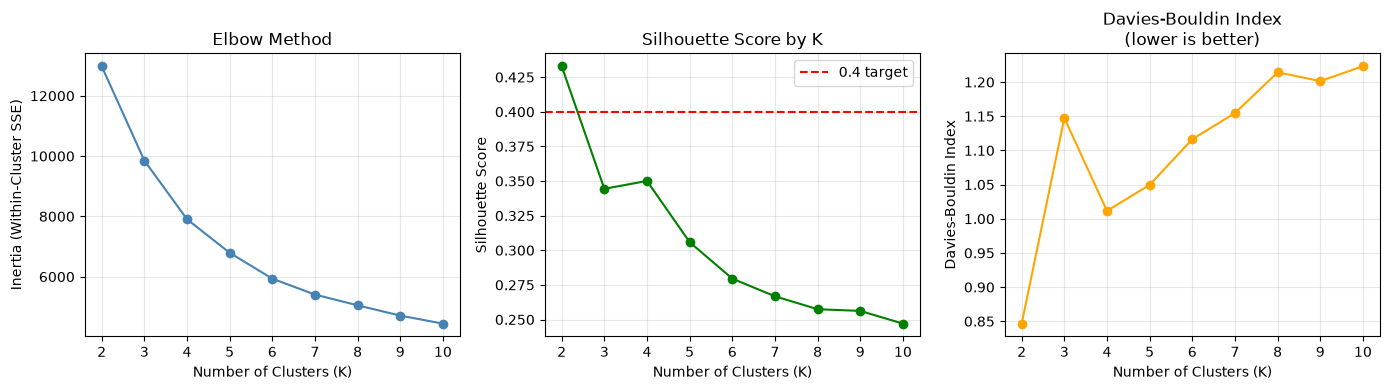


Silhouette-optimal K = 2  (Silhouette = 0.4329)
DB-optimal K         = 2  (DB = 0.8466)

Selected K = 2  (above 0.4 target; DB-optimal; elbow at K=2)


In [33]:
# ── B2.2  Select optimal K (elbow / silhouette / Davies-Bouldin) ─
# All three methods are evaluated; the silhouette-optimal K is used
# in B2.3 unless the educational interpretation warrants an override.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []

print(f"Evaluating K = {K_RANGE.start} … {K_RANGE.stop - 1}  (n_init=20 each)…")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(X_clust_scaled)
    lbl = km.labels_
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_clust_scaled, lbl))
    print(f"  K={k:2d}  Silhouette={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}  "
          f"Inertia={inertias[-1]:>10,.1f}")

k_df = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia': [f'{v:,.1f}' for v in inertias],
    'Silhouette ↑': sil_scores,
    'Davies-Bouldin ↓': db_scores,
})
print("\n── K-Means Evaluation Table ──")
display(k_df)

# ── Visualise ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='green')
axes[1].axhline(0.4, color='red', linestyle='--', label='0.4 target')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(K_RANGE), db_scores, 'o-', color='orange')
axes[2].set_title('Davies-Bouldin Index\n(lower is better)')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
best_k_db  = list(K_RANGE)[db_scores.index(min(db_scores))]

print(f"\nSilhouette-optimal K = {best_k_sil}  (Silhouette = {max(sil_scores):.4f})")
print(f"DB-optimal K         = {best_k_db}  (DB = {min(db_scores):.4f})")
print(f"\nSelected K = {best_k_sil}  "
      f"({'above' if max(sil_scores) >= 0.4 else 'below'} 0.4 target; "
      f"DB-optimal; elbow at K={best_k_sil})")


── K-Means Final Fit: K = 2 ──
  Silhouette Score  : 0.4329  ✓ > 0.4 target
  Davies-Bouldin    : 0.8466  (lower is better)
  Inertia           : 12,980.96

── Archetype assignment (km label → name) ──
  km_label 0  →  Engaged               (centroid_clicks=3,726  centroid_days=113.1)
  km_label 1  →  Disengaged            (centroid_clicks=578  centroid_days=25.5)

── cluster_names: {0: 'Engaged', 1: 'Disengaged', 2: 'No VLE Record'}

── 2013 Training Set — Cluster Sizes ──


,cluster,cluster_name,N,Share
0,0,Engaged,2375,60.9%
1,1,Disengaged,1258,32.3%
2,2,No VLE Record,264,6.8%


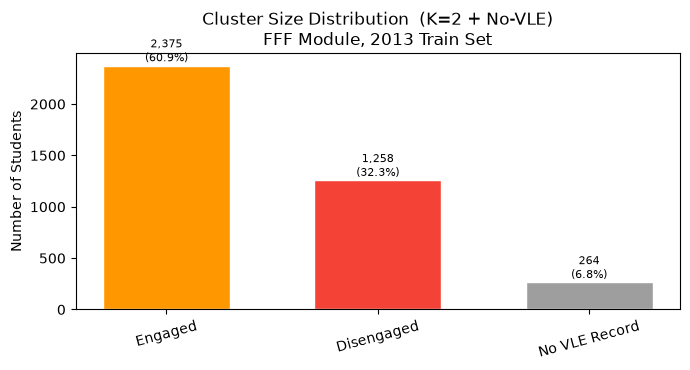


Saved: scaler.pkl, km_final.pkl, model_meta.json  →  d:\Code\CS\code


In [34]:
# ── B2.3  Fit final k-Means + assign cluster labels ───────────
# K is chosen based on the silhouette / DB analysis above.
import joblib, json, os

CHOSEN_K = best_k_sil   # silhouette-optimal K from B2.2

km_b2 = KMeans(n_clusters=CHOSEN_K, init='k-means++', n_init=50, random_state=42)
km_b2.fit(X_clust_scaled)
labels_train_vle = km_b2.labels_

sil_final = silhouette_score(X_clust_scaled, labels_train_vle)
db_final  = davies_bouldin_score(X_clust_scaled, labels_train_vle)

print(f"── K-Means Final Fit: K = {CHOSEN_K} ──")
print(f"  Silhouette Score  : {sil_final:.4f}  {'✓ > 0.4 target' if sil_final > 0.4 else '△ below 0.4 target'}")
print(f"  Davies-Bouldin    : {db_final:.4f}  (lower is better)")
print(f"  Inertia           : {km_b2.inertia_:,.2f}")

# ── Post-hoc archetype labelling ──────────────────────────────
# Inverse-transform centroids back to clipped scale and sort by total_clicks.
# Rank 0 = lowest engagement → Disengaged; rank K-1 = highest → Engaged / High Engage.
centroid_df = pd.DataFrame(
    scaler_b2.inverse_transform(km_b2.cluster_centers_),
    columns=CLUSTER_FEATURES)
centroid_df.index.name = 'km_label'
sorted_by_clicks = centroid_df.sort_values('total_clicks').index.tolist()

# Tier labels: 2 tiers = [Disengaged, Engaged]; 3 = [Disengaged, Moderate, High Engaged]; etc.
tier_labels = {
    2: ['Disengaged', 'Engaged'],
    3: ['Disengaged', 'Moderate Engage', 'High Engage'],
    4: ['Disengaged', 'Low Engage',     'Moderate Engage', 'High Engage'],
    5: ['Disengaged', 'Low Engage',     'Moderate Engage', 'High Engage', 'Elite Engage'],
}
names_for_k = tier_labels.get(CHOSEN_K, [f'Cluster_{i}' for i in range(CHOSEN_K)])
archetype_raw = {km_lbl: names_for_k[rank]
                 for rank, km_lbl in enumerate(sorted_by_clicks)}

print(f"\n── Archetype assignment (km label → name) ──")
for km_lbl in range(CHOSEN_K):
    print(f"  km_label {km_lbl}  →  {archetype_raw[km_lbl]:20s}  "
          f"(centroid_clicks={centroid_df.loc[km_lbl,'total_clicks']:,.0f}  "
          f"centroid_days={centroid_df.loc[km_lbl,'active_days']:.1f})")

# ── Helper: build & transform VLE features for any sv dataframe ─
def apply_cluster_features(sv):
    df = sv.groupby('id_student').agg(
        total_clicks      = ('sum_click', 'sum'),
        active_days       = ('date',      'nunique'),
        mean_daily_clicks = ('sum_click', 'mean'),
        max_daily_clicks  = ('sum_click', 'max'),
        std_daily_clicks  = ('sum_click', 'std'),
        unique_resources  = ('id_site',   'nunique'),
        first_access_day  = ('date',      'min'),
        last_access_day   = ('date',      'max'),
    ).reset_index()
    df['active_span']      = df['last_access_day'] - df['first_access_day']
    df['std_daily_clicks'] = df['std_daily_clicks'].fillna(0)
    for f, cap in clip_caps.items():
        df[f] = df[f].clip(upper=cap)
    return df

# ── Assign labels to all FFF students (2013 + 2014) ──────────
vle_all            = apply_cluster_features(sv_fff)
X_all_scaled       = scaler_b2.transform(vle_all[CLUSTER_FEATURES].values)
vle_all['cluster'] = km_b2.predict(X_all_scaled)

# No-VLE students → cluster CHOSEN_K (one beyond k-means labels)
NO_VLE_LABEL = CHOSEN_K
cluster_map       = dict(zip(vle_all['id_student'], vle_all['cluster']))
si_fff['cluster'] = si_fff['id_student'].map(cluster_map).fillna(NO_VLE_LABEL).astype(int)
df_b1['cluster']  = df_b1['id_student'].map(cluster_map).fillna(NO_VLE_LABEL).astype(int)

# ── Build cluster_names dict (keys as strings for JSON) ───────
cluster_names = {c: archetype_raw[c] for c in range(CHOSEN_K)}
cluster_names[NO_VLE_LABEL] = 'No VLE Record'
print(f"\n── cluster_names: {cluster_names}")

# ── Engagement-rank-ordered colour palette ─────────────────────
# Colours ordered from lowest → highest engagement, then No VLE (grey).
# Each km_label gets the colour of its engagement rank, not its numeric label.
engagement_colours = ['#F44336', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0']  # low → high
_colour_by_rank    = engagement_colours[:CHOSEN_K] + ['#9E9E9E']   # +grey for No VLE
# Map km_label → colour via its rank in sorted_by_clicks
cluster_colors = {}
for rank, km_lbl in enumerate(sorted_by_clicks):
    cluster_colors[km_lbl] = _colour_by_rank[rank]
cluster_colors[NO_VLE_LABEL] = '#9E9E9E'

# ── Cluster size distribution ──────────────────────────────────
si_fff_train_clust = si_fff_train.copy()
si_fff_train_clust['cluster']      = si_fff_train_clust['id_student'].map(cluster_map).fillna(NO_VLE_LABEL).astype(int)
si_fff_train_clust['cluster_name'] = si_fff_train_clust['cluster'].map(cluster_names)

size_df = (si_fff_train_clust
           .groupby(['cluster', 'cluster_name']).size()
           .reset_index(name='N')
           .sort_values('cluster'))
size_df['Share'] = (size_df['N'] / size_df['N'].sum() * 100).round(1).astype(str) + '%'
print("\n── 2013 Training Set — Cluster Sizes ──")
display(size_df)

# ── Cluster size bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(size_df['cluster_name'], size_df['N'],
              color=[cluster_colors[c] for c in size_df['cluster']],
              edgecolor='white', width=0.6)
ax.set_title(f'Cluster Size Distribution  (K={CHOSEN_K} + No-VLE)\nFFF Module, 2013 Train Set')
ax.set_ylabel('Number of Students')
ax.tick_params(axis='x', rotation=15)
for b, row in zip(bars, size_df.itertuples()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
            f'{row.N:,}\n({row.Share})', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# ── Save artefacts ─────────────────────────────────────────────
SAVE_DIR = os.path.dirname(os.path.abspath('OULAD.ipynb'))
joblib.dump(scaler_b2, os.path.join(SAVE_DIR, 'scaler.pkl'))
joblib.dump(km_b2,     os.path.join(SAVE_DIR, 'km_final.pkl'))

meta_path = os.path.join(SAVE_DIR, 'model_meta.json')
with open(meta_path) as f:
    meta = json.load(f)
meta['cluster_features'] = CLUSTER_FEATURES
meta['clip_features']    = CLIP_FEATURES
meta['clip_caps']        = {k: float(v) for k, v in clip_caps.items()}
meta['cluster_names']    = {str(k): v for k, v in cluster_names.items()}
meta.pop('log_features', None)
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\nSaved: scaler.pkl, km_final.pkl, model_meta.json  →  {SAVE_DIR}")


## 15b. B2 K-Sensitivity Analysis: Forced K=3 and K=4 (7 VLE Features)

Same methodology as B2++ but on the original **7-feature per-student** B2 dataset.
K=2 is silhouette-optimal (Sil=0.4329, DB=0.8466); this section tests whether K=3 or K=4
yields more useful learner profiles from the simpler feature set.


═══════════════════════════════════════════════════════
  K = 3   Silhouette = 0.3443   Davies-Bouldin = 1.1472
═══════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg total_clicks,Avg active_days,Avg mean_score,Avg num_submissions
0,0,Moderate,3017,12.2%,2331.0,77.5,74.51,10.5
1,1,Disengaged,2335,60.0%,473.0,22.2,46.45,1.7
2,2,High Engaged,1804,3.2%,5701.0,161.5,81.82,12.3
3,3,No VLE Record,606,94.9%,0.0,0.0,0.09,0.0



═══════════════════════════════════════════════════════
  K = 4   Silhouette = 0.3500   Davies-Bouldin = 1.0119
═══════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg total_clicks,Avg active_days,Avg mean_score,Avg num_submissions
0,0,Moderate,1808,3.2%,5186.0,157.0,81.49,12.2
1,1,Disengaged,2233,60.4%,440.0,21.2,45.51,1.6
2,2,Low Engaged,2688,14.2%,2149.0,72.5,73.66,10.1
3,3,High Engaged,427,9.1%,5355.0,118.7,79.43,11.8
4,4,No VLE Record,606,94.9%,0.0,0.0,0.09,0.0


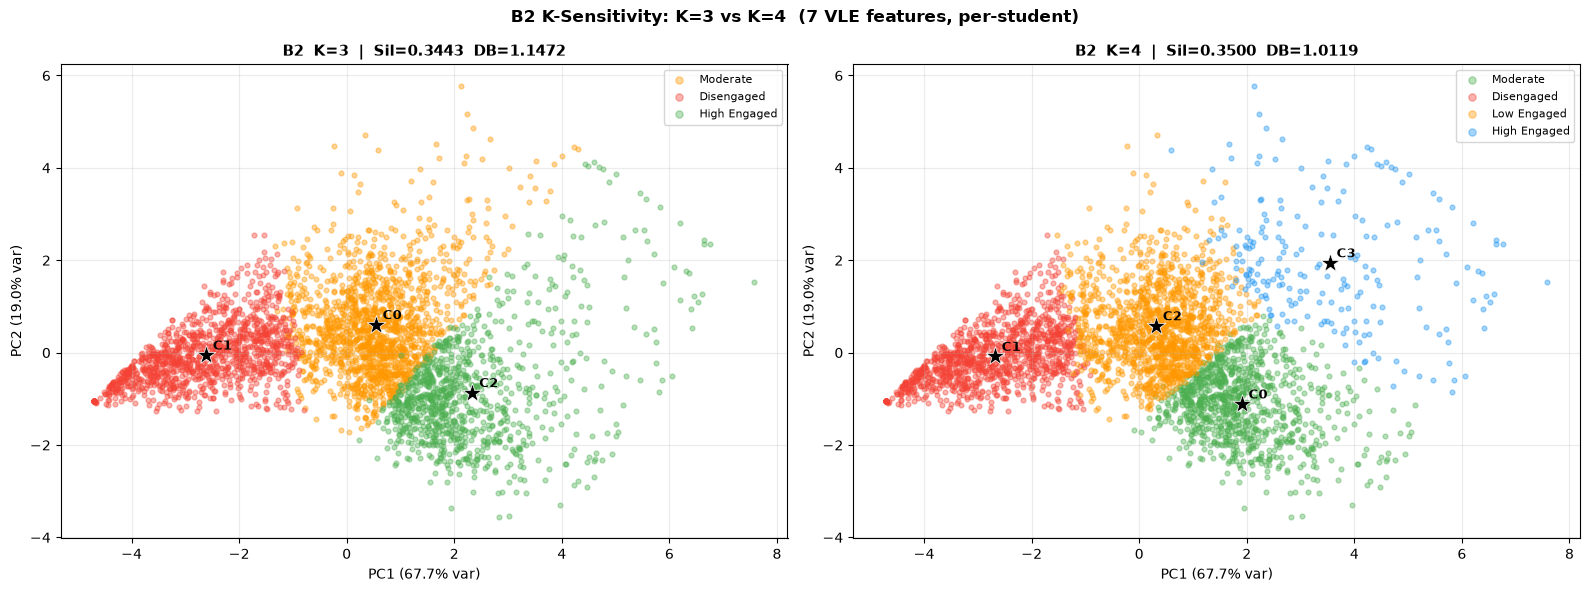

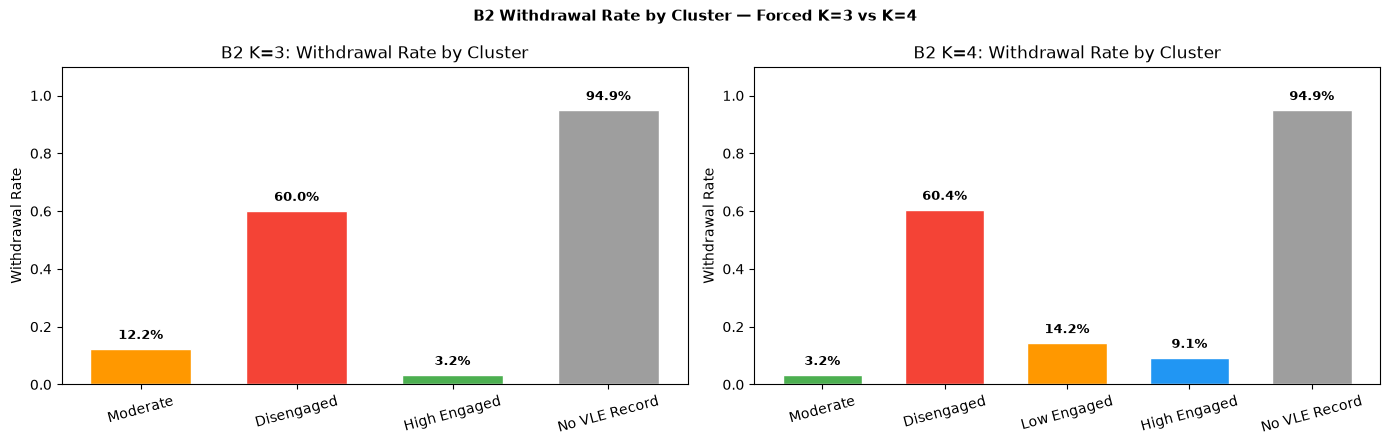


══ B2 K-Selection Summary (7 VLE features, per unique student) ══


,K,Silhouette ↑,DB ↓,Profiles
0,2,0.4329,0.8466,Disengaged / Engaged / No VLE
1,3,0.3443,1.1472,Disengaged / Moderate / High Engaged / No VLE
2,4,0.3500,1.0119,Disengaged / Low Engaged / Moderate / High Eng...


In [35]:
# ── B2 K-Sensitivity: Forced K=3 and K=4 (7-feature per-student dataset) ──
# Uses: X_clust_scaled (2013 VLE-active, 7 feats), vle_clust, scaler_b2,
#       clip_caps, CLUSTER_FEATURES, apply_cluster_features(), sv_fff, df_b1

from sklearn.decomposition import PCA

_tier_b2 = {
    3: ['Disengaged', 'Moderate',    'High Engaged'],
    4: ['Disengaged', 'Low Engaged', 'Moderate',   'High Engaged'],
}
_pal_b2   = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
FORCED_KS_B2 = [3, 4]

results_b2_forced = {}

for FK in FORCED_KS_B2:
    # ── 1. Fit ──────────────────────────────────────────────────
    km_fk     = KMeans(n_clusters=FK, init='k-means++', n_init=50, random_state=42)
    labels_fk = km_fk.fit_predict(X_clust_scaled)

    sil_fk = silhouette_score(X_clust_scaled, labels_fk)
    db_fk  = davies_bouldin_score(X_clust_scaled, labels_fk)

    # ── 2. Archetype naming: rank by total_clicks (same as B2.3) ─
    ctr_fk    = pd.DataFrame(scaler_b2.inverse_transform(km_fk.cluster_centers_),
                              columns=CLUSTER_FEATURES)
    sorted_fk = ctr_fk.sort_values('total_clicks').index.tolist()
    names_fk  = _tier_b2[FK]
    arch_fk   = {lbl: names_fk[rank] for rank, lbl in enumerate(sorted_fk)}
    arch_fk[FK]  = 'No VLE Record'
    clrs_fk   = {lbl: _pal_b2[rank] for rank, lbl in enumerate(sorted_fk)}
    clrs_fk[FK]  = '#9E9E9E'

    # ── 3. Predict all FFF students ─────────────────────────────
    vle_all_fk             = apply_cluster_features(sv_fff)
    X_all_fk               = scaler_b2.transform(vle_all_fk[CLUSTER_FEATURES].values)
    vle_all_fk['km_label'] = km_fk.predict(X_all_fk)
    cmap_fk = dict(zip(vle_all_fk['id_student'], vle_all_fk['km_label']))

    col_b2 = f'cluster_k{FK}_b2'
    df_b1[col_b2] = (df_b1['id_student'].map(cmap_fk).fillna(FK).astype(int))

    # ── 4. Profile table ─────────────────────────────────────────
    rows_fk = []
    for lbl in range(FK + 1):
        mask = df_b1[col_b2] == lbl
        if not mask.any():
            continue
        sub = df_b1[mask]
        rows_fk.append({
            'Cluster':               lbl,
            'Archetype':             arch_fk[lbl],
            'N':                     int(mask.sum()),
            'WD Rate':               f"{(sub['label'] == 1).mean():.1%}",
            'Avg total_clicks':      round(sub['total_clicks'].mean(),      0),
            'Avg active_days':       round(sub['active_days'].mean(),       1),
            'Avg mean_score':        round(sub['mean_score'].mean(),        2),
            'Avg num_submissions':   round(sub['num_submissions'].mean(),   1),
        })

    results_b2_forced[FK] = {
        'km': km_fk, 'labels': labels_fk, 'sil': sil_fk, 'db': db_fk,
        'archetype': arch_fk, 'colors': clrs_fk,
        'profile': pd.DataFrame(rows_fk),
    }

    print(f"\n{'═'*55}")
    print(f"  K = {FK}   Silhouette = {sil_fk:.4f}   Davies-Bouldin = {db_fk:.4f}")
    print(f"{'═'*55}")
    display(results_b2_forced[FK]['profile'])

# ── 5. Side-by-side PCA scatter ─────────────────────────────────
pca_b2s   = PCA(n_components=2, random_state=42).fit(X_clust_scaled)
X_pca_b2s = pca_b2s.transform(X_clust_scaled)
var_b2s   = pca_b2s.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, FK in zip(axes, FORCED_KS_B2):
    r = results_b2_forced[FK]
    for lbl in range(FK):
        mask = r['labels'] == lbl
        ax.scatter(X_pca_b2s[mask, 0], X_pca_b2s[mask, 1],
                   c=r['colors'][lbl], alpha=0.4, s=12, label=r['archetype'][lbl])
    ctrs_b2s = pca_b2s.transform(r['km'].cluster_centers_)
    ax.scatter(ctrs_b2s[:, 0], ctrs_b2s[:, 1],
               marker='*', s=200, c='black', zorder=5, edgecolors='white', linewidths=0.5)
    for i, (cx, cy) in enumerate(ctrs_b2s):
        ax.annotate(f'C{i}', (cx, cy), xytext=(5, 4),
                    textcoords='offset points', fontsize=9, fontweight='bold')
    ax.set_title(f'B2  K={FK}  |  Sil={r["sil"]:.4f}  DB={r["db"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_b2s[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({var_b2s[1]:.1%} var)')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.25)

plt.suptitle('B2 K-Sensitivity: K=3 vs K=4  (7 VLE features, per-student)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Withdrawal-rate bar chart ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, FK in zip(axes, FORCED_KS_B2):
    r = results_b2_forced[FK]
    col_b2 = f'cluster_k{FK}_b2'
    lbl_range  = list(range(FK + 1))
    wd_vals_b2 = [(df_b1[df_b1[col_b2] == k]['label'] == 1).mean() for k in lbl_range]
    names_b2   = [r['archetype'][k] for k in lbl_range]
    clrs_b2    = [r['colors'][k]    for k in lbl_range]
    bars_b2 = ax.bar(names_b2, wd_vals_b2, color=clrs_b2, edgecolor='white', width=0.65)
    ax.set_title(f'B2 K={FK}: Withdrawal Rate by Cluster')
    ax.set_ylabel('Withdrawal Rate')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars_b2, wd_vals_b2):
        ax.text(b.get_x() + b.get_width()/2, v + 0.025, f'{v:.1%}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('B2 Withdrawal Rate by Cluster — Forced K=3 vs K=4',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7. Full comparison table: B2 K=2, K=3, K=4 ──────────────────
print("\n══ B2 K-Selection Summary (7 VLE features, per unique student) ══")
display(pd.DataFrame([
    {'K': 2, 'Silhouette ↑': round(sil_final, 4), 'DB ↓': round(db_final, 4),
     'Profiles': 'Disengaged / Engaged / No VLE'},
    {'K': 3, 'Silhouette ↑': round(results_b2_forced[3]['sil'], 4),
              'DB ↓': round(results_b2_forced[3]['db'], 4),
     'Profiles': 'Disengaged / Moderate / High Engaged / No VLE'},
    {'K': 4, 'Silhouette ↑': round(results_b2_forced[4]['sil'], 4),
              'DB ↓': round(results_b2_forced[4]['db'], 4),
     'Profiles': 'Disengaged / Low Engaged / Moderate / High Engaged / No VLE'},
]))


## 16. B2+ — Enriched k-Means Clustering (12 Behavioural Features, No imd_band)

**Motivation**: The original B2 used 7 VLE aggregates computed per *unique student* (collapsing
2013B and 2013J into one row per learner).  That sparse representation yielded K = 2 as the
optimal number of clusters — a binary Engaged / Disengaged split that, while interpretable,
does not differentiate *how* students engage.

**B2+ extends the feature set to 12 behavioural dimensions** drawn from the full OULAD data:

| Feature group | Features |
|---|---|
| Temporal depth | `active_days`, `active_span`, `mean_daily_clicks`, `max_daily_clicks`, `std_daily_clicks` |
| Content breadth | `interactive_clicks`, `assessment_clicks`, `content_clicks`, `activity_type_diversity` |
| Academic signal | `mean_score`, `num_submissions` |
| Commitment proxy | `reg_offset` |

**Key differences from B2**:
- Clustering unit = *(student, presentation)* pair — consistent with `df_b1p` and I1
- Activity-type breakdown separates social, formative and content interactions
- Assessment performance and submission count add an academic-achievement signal
- Registration timing (`reg_offset`) captures pre-course commitment

The expected outcome is that richer features allow k-means to resolve a finer engagement
taxonomy (likely K = 3–4), providing more discriminative cluster labels for the I1 model.

B2+ training population: 3,608 VLE-active (student, pres) pairs
  (out of 3,897 total 2013 rows in df_b1p; 289 have no VLE record → No-VLE label)

Compare — B2 original: 3,574 unique students (per-student aggregation)

── B2+ 99th-percentile caps (2013 VLE-active) ──
  interactive_clicks          cap= 2,674.4  clipped: 37
  assessment_clicks           cap= 2,517.9  clipped: 37
  content_clicks              cap= 6,688.7  clipped: 37
  max_daily_clicks            cap=   361.0  clipped: 36
  std_daily_clicks            cap=   117.5  clipped: 37

Evaluating K = 2 … 8  (n_init=20 each)…
  K= 2  Silhouette=0.3684  DB=1.0616
  K= 3  Silhouette=0.2710  DB=1.4684
  K= 4  Silhouette=0.2619  DB=1.3875
  K= 5  Silhouette=0.2498  DB=1.3515
  K= 6  Silhouette=0.2250  DB=1.4386
  K= 7  Silhouette=0.2277  DB=1.3331
  K= 8  Silhouette=0.2168  DB=1.3661

── B2 vs B2+: K-Selection Comparison ──


' K  B2 Sil (7 feat)  B2+ Sil (12 feat)  B2 DB (7 feat)  B2+ DB (12 feat)\n 2           0.4329             0.3684          0.8466            1.0616\n 3           0.3444             0.2710          1.1474            1.4684\n 4           0.3500             0.2619          1.0115            1.3875\n 5           0.3059             0.2498          1.0496            1.3515\n 6           0.2795             0.2250          1.1164            1.4386\n 7           0.2668             0.2277          1.1546            1.3331\n 8           0.2575             0.2168          1.2142            1.3661'


B2  silhouette-optimal  K = 2  (Sil=0.4329,  DB=0.8466)
B2+ silhouette-optimal  K = 2   (Sil=0.3684,  DB=1.0616)


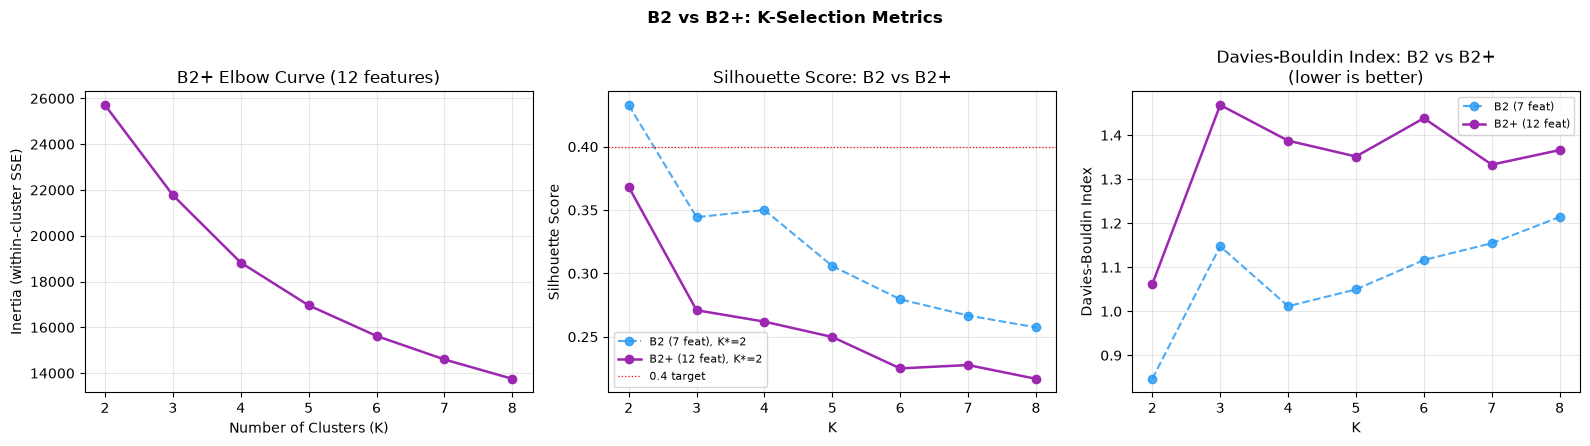

In [36]:
# ── B2+.1  Enriched feature engineering + K selection ─────────
# Builds a 12-feature behavioural matrix from df_b1p (which already
# contains activity-type breakdown, assessment stats and reg_offset)
# plus std_daily_clicks and active_span computed from daily VLE logs.
# Clustering unit = (id_student, code_presentation) — consistent with df_b1p.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# ── 1. Add per-(student, presentation) temporal stats ─────────
# std_daily_clicks and active_span are not in df_b1p; derive from sv_fff.
sv_per_day_p = (
    sv_fff.groupby(['id_student', 'code_presentation', 'date'])['sum_click']
    .sum().reset_index()
)
span_stats_p = sv_per_day_p.groupby(['id_student', 'code_presentation']).agg(
    std_daily_clicks=('sum_click', 'std'),
    first_day       =('date',      'min'),
    last_day        =('date',      'max'),
).reset_index()
span_stats_p['active_span']      = span_stats_p['last_day'] - span_stats_p['first_day']
span_stats_p['std_daily_clicks'] = span_stats_p['std_daily_clicks'].fillna(0)
span_stats_p = span_stats_p.drop(columns=['first_day', 'last_day'])

# ── 2. Merge temporal stats into df_b1p ───────────────────────
# Drop any stale cluster_p column from a prior run to stay idempotent.
_base_p = df_b1p.drop(columns=['cluster_p'], errors='ignore')
vle_clust_p = _base_p.merge(
    span_stats_p[['id_student', 'code_presentation', 'active_span', 'std_daily_clicks']],
    on=['id_student', 'code_presentation'], how='left'
)
vle_clust_p['active_span']      = vle_clust_p['active_span'].fillna(0)
vle_clust_p['std_daily_clicks'] = vle_clust_p['std_daily_clicks'].fillna(0)

# ── 3. Feature specification ───────────────────────────────────
CLUSTER_FEATURES_P = [
    'active_days',              # days with any VLE activity
    'active_span',              # calendar days from first to last access
    'mean_daily_clicks',        # typical session intensity
    'max_daily_clicks',         # peak engagement
    'std_daily_clicks',         # consistency / volatility
    'interactive_clicks',       # social / collaborative (forumng, ouelluminate…)
    'assessment_clicks',        # formative & summative (quiz, externalquiz…)
    'content_clicks',           # passive content consumption
    'activity_type_diversity',  # breadth across activity types
    'mean_score',               # assessment performance
    'num_submissions',          # assignment completion count
    'reg_offset',               # registration timing (early = negative)
]
CLIP_FEATURES_P = [
    'interactive_clicks', 'assessment_clicks', 'content_clicks',
    'max_daily_clicks', 'std_daily_clicks',
]

# ── 4. Filter: 2013 VLE-active (student, presentation) pairs ──
# Inner-join ensures only students with at least one VLE record are clustered.
sv_train_pairs_p = (
    sv_fff[sv_fff['code_presentation'].str.startswith('2013')]
    [['id_student', 'code_presentation']].drop_duplicates()
)
vle_clust_train_p = (
    vle_clust_p[vle_clust_p['code_presentation'].str.startswith('2013')]
    .merge(sv_train_pairs_p, on=['id_student', 'code_presentation'], how='inner')
    .reset_index(drop=True)
)

n_all_2013 = (vle_clust_p['code_presentation'].str.startswith('2013')).sum()
print(f"B2+ training population: {len(vle_clust_train_p):,} VLE-active (student, pres) pairs")
print(f"  (out of {n_all_2013:,} total 2013 rows in df_b1p; "
      f"{n_all_2013 - len(vle_clust_train_p):,} have no VLE record → No-VLE label)")
print(f"\nCompare — B2 original: {len(X_clust):,} unique students (per-student aggregation)")

# ── 5. 99th-percentile clipping (fit on 2013 training) ────────
vle_clust_clipped_p = vle_clust_train_p.copy()
clip_caps_p = {}
print("\n── B2+ 99th-percentile caps (2013 VLE-active) ──")
for f in CLIP_FEATURES_P:
    cap = float(vle_clust_train_p[f].quantile(0.99))
    clip_caps_p[f] = cap
    n_clipped = int((vle_clust_train_p[f] > cap).sum())
    vle_clust_clipped_p[f] = vle_clust_clipped_p[f].clip(upper=cap)
    print(f"  {f:<26}  cap={cap:>8,.1f}  clipped: {n_clipped}")

# ── 6. Standardise (fit on 2013 VLE-active) ───────────────────
X_clust_p        = vle_clust_clipped_p[CLUSTER_FEATURES_P].values
scaler_b2p       = StandardScaler().fit(X_clust_p)
X_clust_scaled_p = scaler_b2p.transform(X_clust_p)

# ── 7. K selection (K = 2 … 8) ────────────────────────────────
K_RANGE_P    = range(2, 9)
inertias_p   = []
sil_scores_p = []
db_scores_p  = []

print(f"\nEvaluating K = {K_RANGE_P.start} … {K_RANGE_P.stop - 1}  (n_init=20 each)…")
for k in K_RANGE_P:
    km_k = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    lbl  = km_k.fit_predict(X_clust_scaled_p)
    inertias_p.append(km_k.inertia_)
    sil_scores_p.append(silhouette_score(X_clust_scaled_p, lbl))
    db_scores_p.append(davies_bouldin_score(X_clust_scaled_p, lbl))
    print(f"  K={k:2d}  Silhouette={sil_scores_p[-1]:.4f}  DB={db_scores_p[-1]:.4f}")

best_k_p  = list(K_RANGE_P)[sil_scores_p.index(max(sil_scores_p))]
best_db_p = list(K_RANGE_P)[db_scores_p.index(min(db_scores_p))]

# ── 8. Comparison table: B2 vs B2+ ────────────────────────────
_ks = list(K_RANGE_P)
k_compare_p = pd.DataFrame({
    'K':                    _ks,
    'B2 Sil (7 feat)':      [round(sil_scores[k - 2], 4) for k in _ks],
    'B2+ Sil (12 feat)':    [round(sil_scores_p[i],   4) for i in range(len(_ks))],
    'B2 DB (7 feat)':       [round(db_scores[k - 2],  4) for k in _ks],
    'B2+ DB (12 feat)':     [round(db_scores_p[i],    4) for i in range(len(_ks))],
})
print("\n── B2 vs B2+: K-Selection Comparison ──")
display(k_compare_p.to_string(index=False))

print(f"\nB2  silhouette-optimal  K = {best_k_sil}  (Sil={max(sil_scores):.4f},  DB={db_scores[best_k_sil-2]:.4f})")
print(f"B2+ silhouette-optimal  K = {best_k_p}   (Sil={max(sil_scores_p):.4f},  DB={db_scores_p[best_k_p-2]:.4f})")

# ── 9. Elbow / Silhouette / DB plots (B2 vs B2+ overlaid) ─────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
_ks_b2  = list(range(2, 9))   # subset of B2 range matching K_RANGE_P

axes[0].plot(_ks, inertias_p, 'o-', color='#9C27B0', linewidth=1.8)
axes[0].set_title('B2+ Elbow Curve (12 features)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_xticks(_ks)
axes[0].grid(True, alpha=0.3)

axes[1].plot(_ks_b2, [sil_scores[k - 2] for k in _ks_b2], 'o--',
             color='#2196F3', alpha=0.8, linewidth=1.5,
             label=f'B2 (7 feat), K*={best_k_sil}')
axes[1].plot(_ks, sil_scores_p, 'o-',
             color='#9C27B0', linewidth=1.8,
             label=f'B2+ (12 feat), K*={best_k_p}')
axes[1].axhline(0.4, color='red', linestyle=':', linewidth=0.9, label='0.4 target')
axes[1].set_title('Silhouette Score: B2 vs B2+')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(_ks)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(_ks_b2, [db_scores[k - 2] for k in _ks_b2], 'o--',
             color='#2196F3', alpha=0.8, linewidth=1.5, label='B2 (7 feat)')
axes[2].plot(_ks, db_scores_p, 'o-',
             color='#9C27B0', linewidth=1.8, label='B2+ (12 feat)')
axes[2].set_title('Davies-Bouldin Index: B2 vs B2+\n(lower is better)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_xticks(_ks)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('B2 vs B2+: K-Selection Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


── B2+ Final Model: K = 2 ──
  Silhouette Score : 0.3684  △ < 0.4
  Davies-Bouldin   : 1.0616
  Inertia          : 25,708.74

  Compare ← B2 original: K=2, Sil=0.4329, DB=0.8466

── Archetype Assignment ──
  km_label 0  →  Engaged             mean_active_days=114.9
  km_label 1  →  Disengaged          mean_active_days=27.9

── df_b1p['cluster_p'] value counts ──
  0 (Engaged           ) : 4,374
  1 (Disengaged        ) : 2,718
  2 (No VLE Record     ) :   670

── B2+ Cluster Profiles ──


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg assessment_clicks,Avg mean_score,Avg reg_offset
0,0,Engaged,4374,4.2%,114.3,851.0,78.34,-67.1
1,1,Disengaged,2718,58.3%,27.0,62.0,49.53,-66.1
2,2,No VLE Record,670,94.8%,5.4,0.0,5.43,-93.3


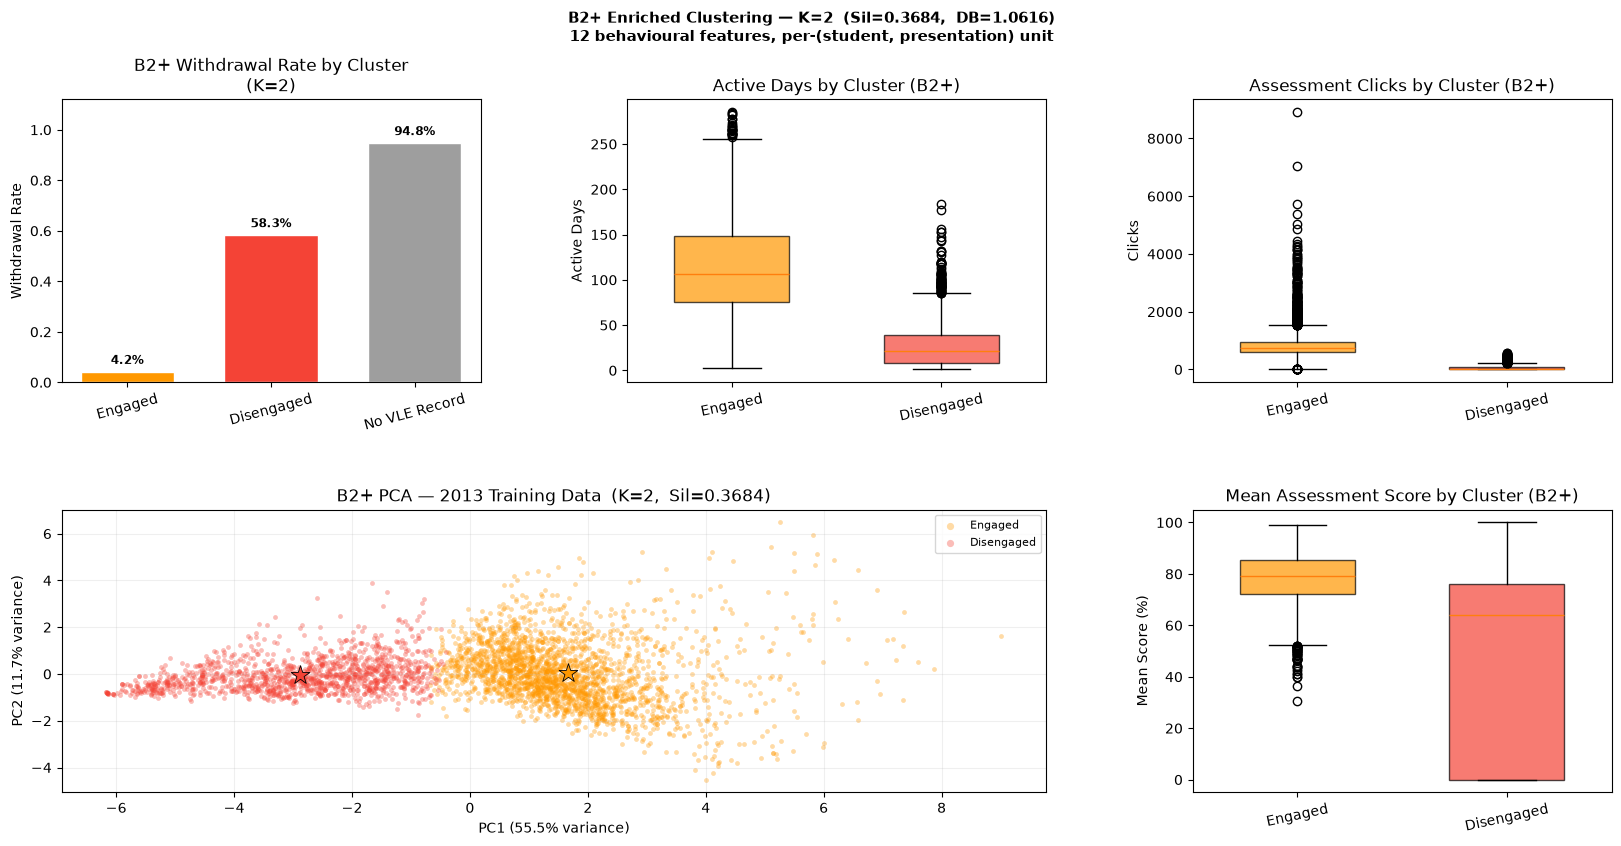


══════════════ Clustering Comparison ══════════════
  B2  (7 VLE feat, per-student)      : K=2,   Sil=0.4329, DB=0.8466
  B2+ (12 behav feat, per-pres)      : K=2,   Sil=0.3684,  DB=1.0616
  Δ Silhouette  : -0.0645  (decline)
  Δ DB Index    : +0.2150  (decline)
═══════════════════════════════════════════════════

Artefacts updated with B2+ model → d:\Code\CS\code
  scaler.pkl     : 2-cluster StandardScaler (12 features)
  km_final.pkl   : KMeans(K=2)
  model_meta.json: cluster_features / clip_caps / cluster_names updated

Next step → I1: B1+ features (16) + cluster_p label → XGBoost comparison


In [37]:
# ── B2+.2  Final k-Means fit, profile, PCA, and artefact update ─
# Fits the silhouette-optimal model, assigns archetype names by
# active_days rank, evaluates cluster profiles (size, withdrawal rate,
# mean behavioural features), visualises with PCA and bar charts,
# and overwrites scaler.pkl / km_final.pkl / model_meta.json.

import joblib, json, os
from sklearn.decomposition import PCA

CHOSEN_K_P    = best_k_p
NO_VLE_LABEL_P = CHOSEN_K_P

# ── 1. Fit final model ─────────────────────────────────────────
km_b2p = KMeans(n_clusters=CHOSEN_K_P, init='k-means++', n_init=50, random_state=42)
labels_p = km_b2p.fit_predict(X_clust_scaled_p)
vle_clust_train_p = vle_clust_train_p.copy()
vle_clust_train_p['km_label'] = labels_p

sil_p = silhouette_score(X_clust_scaled_p, labels_p)
db_p  = davies_bouldin_score(X_clust_scaled_p, labels_p)

print(f"── B2+ Final Model: K = {CHOSEN_K_P} ──")
print(f"  Silhouette Score : {sil_p:.4f}  {'✓ > 0.4' if sil_p > 0.4 else '△ < 0.4'}")
print(f"  Davies-Bouldin   : {db_p:.4f}")
print(f"  Inertia          : {km_b2p.inertia_:,.2f}")
print(f"\n  Compare ← B2 original: K={CHOSEN_K}, Sil={sil_final:.4f}, DB={db_final:.4f}")

# ── 2. Archetype naming: rank clusters by mean active_days ─────
mean_active_p  = vle_clust_train_p.groupby('km_label')['active_days'].mean()
sorted_labels_p = mean_active_p.sort_values().index.tolist()   # low → high

_tier_labels_p = {
    2: ['Disengaged', 'Engaged'],
    3: ['Disengaged', 'Moderate', 'High Engaged'],
    4: ['Disengaged', 'Low Engaged', 'Moderate', 'High Engaged'],
    5: ['Disengaged', 'Low Engaged', 'Moderate', 'High Engaged', 'Elite'],
}
_names_p = _tier_labels_p.get(CHOSEN_K_P, [f'Cluster_{i}' for i in range(CHOSEN_K_P)])
archetype_p     = {km_lbl: _names_p[rank] for rank, km_lbl in enumerate(sorted_labels_p)}
cluster_names_p = {**archetype_p, NO_VLE_LABEL_P: 'No VLE Record'}

# Colour palette: low-engage (red) → high-engage (green), No-VLE (grey)
_pal_p = ['#F44336', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0']
cluster_colors_p = {km_lbl: _pal_p[rank] for rank, km_lbl in enumerate(sorted_labels_p)}
cluster_colors_p[NO_VLE_LABEL_P] = '#9E9E9E'

print("\n── Archetype Assignment ──")
for km_lbl in range(CHOSEN_K_P):
    print(f"  km_label {km_lbl}  →  {archetype_p[km_lbl]:18s}  "
          f"mean_active_days={mean_active_p[km_lbl]:.1f}")

# ── 3. Predict all FFF students (all presentations) ───────────
sv_all_pairs_p = sv_fff[['id_student', 'code_presentation']].drop_duplicates()
vle_all_p = (
    vle_clust_p.merge(sv_all_pairs_p, on=['id_student', 'code_presentation'], how='inner')
    .copy()
)
for f, cap in clip_caps_p.items():
    vle_all_p[f] = vle_all_p[f].clip(upper=cap)

X_all_p = scaler_b2p.transform(vle_all_p[CLUSTER_FEATURES_P].values)
vle_all_p['km_label'] = km_b2p.predict(X_all_p)

# (id_student, code_presentation) → km_label
cluster_map_p = dict(zip(
    zip(vle_all_p['id_student'], vle_all_p['code_presentation']),
    vle_all_p['km_label']
))

# Assign to df_b1p (per-presentation, so use composite key)
df_b1p['cluster_p'] = df_b1p.apply(
    lambda r: cluster_map_p.get((r['id_student'], r['code_presentation']), NO_VLE_LABEL_P),
    axis=1
).astype(int)

print(f"\n── df_b1p['cluster_p'] value counts ──")
vc_p = df_b1p['cluster_p'].value_counts().sort_index()
for cl, cnt in vc_p.items():
    print(f"  {cl} ({cluster_names_p[cl]:18s}) : {cnt:5,}")

# ── 4. Cluster profile (size, withdrawal rate, mean features) ─
profile_rows_p = []
for km_lbl in range(CHOSEN_K_P + 1):
    mask = df_b1p['cluster_p'] == km_lbl
    if not mask.any():
        continue
    sub = df_b1p[mask]
    wd_rate = (sub['label'] == 1).mean()
    row = {
        'Cluster':              km_lbl,
        'Archetype':            cluster_names_p[km_lbl],
        'N':                    int(mask.sum()),
        'WD Rate':              f'{wd_rate:.1%}',
        'Avg active_days':      round(sub['active_days'].mean(), 1),
        'Avg assessment_clicks': round(sub['assessment_clicks'].mean(), 0),
        'Avg mean_score':       round(sub['mean_score'].mean(), 2),
        'Avg reg_offset':       round(sub['reg_offset'].mean(), 1),
    }
    profile_rows_p.append(row)

profile_p = pd.DataFrame(profile_rows_p)
print("\n── B2+ Cluster Profiles ──")
display(profile_p)

# ── 5. Visualisations ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])   # withdrawal rate bar
ax1 = fig.add_subplot(gs[0, 1])   # active_days boxplot
ax2 = fig.add_subplot(gs[0, 2])   # assessment_clicks boxplot
ax3 = fig.add_subplot(gs[1, :2])  # PCA scatter (wide)
ax4 = fig.add_subplot(gs[1, 2])   # mean_score boxplot

# Withdrawal rate bar chart
wd_vals  = [(df_b1p[df_b1p['cluster_p'] == k]['label'] == 1).mean()
            for k in range(CHOSEN_K_P + 1)]
bar_names  = [cluster_names_p[k] for k in range(CHOSEN_K_P + 1)]
bar_colors = [cluster_colors_p[k] for k in range(CHOSEN_K_P + 1)]
bars = ax0.bar(bar_names, wd_vals, color=bar_colors, edgecolor='white', width=0.65)
ax0.set_title(f'B2+ Withdrawal Rate by Cluster\n(K={CHOSEN_K_P})')
ax0.set_ylabel('Withdrawal Rate')
ax0.set_ylim(0, min(1.12, max(wd_vals) * 1.25))
ax0.tick_params(axis='x', rotation=15)
for b, v in zip(bars, wd_vals):
    ax0.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.1%}',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# active_days boxplot
dat_active = [df_b1p.loc[df_b1p['cluster_p'] == k, 'active_days'].values
              for k in range(CHOSEN_K_P)]
bp1 = ax1.boxplot(dat_active, patch_artist=True, widths=0.55)
for patch, km_lbl in zip(bp1['boxes'], range(CHOSEN_K_P)):
    patch.set_facecolor(cluster_colors_p[km_lbl]); patch.set_alpha(0.7)
ax1.set_xticklabels([archetype_p[k] for k in range(CHOSEN_K_P)], rotation=12)
ax1.set_title('Active Days by Cluster (B2+)')
ax1.set_ylabel('Active Days')

# assessment_clicks boxplot
dat_assess = [df_b1p.loc[df_b1p['cluster_p'] == k, 'assessment_clicks'].values
              for k in range(CHOSEN_K_P)]
bp2 = ax2.boxplot(dat_assess, patch_artist=True, widths=0.55)
for patch, km_lbl in zip(bp2['boxes'], range(CHOSEN_K_P)):
    patch.set_facecolor(cluster_colors_p[km_lbl]); patch.set_alpha(0.7)
ax2.set_xticklabels([archetype_p[k] for k in range(CHOSEN_K_P)], rotation=12)
ax2.set_title('Assessment Clicks by Cluster (B2+)')
ax2.set_ylabel('Clicks')

# PCA 2-D scatter (training data)
pca_b2p   = PCA(n_components=2, random_state=42)
X_pca_b2p = pca_b2p.fit_transform(X_clust_scaled_p)
var_exp_p = pca_b2p.explained_variance_ratio_

for km_lbl in range(CHOSEN_K_P):
    idx = labels_p == km_lbl
    ax3.scatter(X_pca_b2p[idx, 0], X_pca_b2p[idx, 1],
                c=cluster_colors_p[km_lbl], label=archetype_p[km_lbl],
                alpha=0.35, s=12, linewidths=0)

# Add centroid markers
centroids_pca = pca_b2p.transform(km_b2p.cluster_centers_)
for km_lbl in range(CHOSEN_K_P):
    ax3.scatter(*centroids_pca[km_lbl], marker='*', s=200,
                c=cluster_colors_p[km_lbl], edgecolors='black', linewidths=0.6, zorder=5)

ax3.set_xlabel(f'PC1 ({var_exp_p[0]:.1%} variance)')
ax3.set_ylabel(f'PC2 ({var_exp_p[1]:.1%} variance)')
ax3.set_title(f'B2+ PCA — 2013 Training Data  (K={CHOSEN_K_P},  Sil={sil_p:.4f})')
ax3.legend(fontsize=8, markerscale=1.5)
ax3.grid(True, alpha=0.2)

# mean_score boxplot
dat_score = [df_b1p.loc[df_b1p['cluster_p'] == k, 'mean_score'].values
             for k in range(CHOSEN_K_P)]
bp4 = ax4.boxplot(dat_score, patch_artist=True, widths=0.55)
for patch, km_lbl in zip(bp4['boxes'], range(CHOSEN_K_P)):
    patch.set_facecolor(cluster_colors_p[km_lbl]); patch.set_alpha(0.7)
ax4.set_xticklabels([archetype_p[k] for k in range(CHOSEN_K_P)], rotation=12)
ax4.set_title('Mean Assessment Score by Cluster (B2+)')
ax4.set_ylabel('Mean Score (%)')

fig.suptitle(
    f'B2+ Enriched Clustering — K={CHOSEN_K_P}  '
    f'(Sil={sil_p:.4f},  DB={db_p:.4f})\n'
    f'12 behavioural features, per-(student, presentation) unit',
    fontsize=11, fontweight='bold'
)
plt.show()

# ── 6. B2 vs B2+ comparison summary ───────────────────────────
print("\n══════════════ Clustering Comparison ══════════════")
print(f"  B2  (7 VLE feat, per-student)      : K={CHOSEN_K},   Sil={sil_final:.4f}, DB={db_final:.4f}")
print(f"  B2+ (12 behav feat, per-pres)      : K={CHOSEN_K_P},   Sil={sil_p:.4f},  DB={db_p:.4f}")
delta_sil = sil_p - sil_final
delta_db  = db_p  - db_final
print(f"  Δ Silhouette  : {delta_sil:+.4f}  ({'improvement' if delta_sil > 0 else 'decline'})")
print(f"  Δ DB Index    : {delta_db:+.4f}  ({'improvement' if delta_db  < 0 else 'decline'})")
print("═══════════════════════════════════════════════════")

# ── 7. Overwrite artefacts with B2+ model ─────────────────────
SAVE_DIR_P = os.path.dirname(os.path.abspath('OULAD.ipynb'))
joblib.dump(scaler_b2p, os.path.join(SAVE_DIR_P, 'scaler.pkl'))
joblib.dump(km_b2p,     os.path.join(SAVE_DIR_P, 'km_final.pkl'))

meta_path_p = os.path.join(SAVE_DIR_P, 'model_meta.json')
with open(meta_path_p) as fh:
    meta_p = json.load(fh)

meta_p['cluster_features'] = CLUSTER_FEATURES_P
meta_p['clip_features']    = CLIP_FEATURES_P
meta_p['clip_caps']        = {k: float(v) for k, v in clip_caps_p.items()}
meta_p['cluster_names']    = {str(k): v for k, v in cluster_names_p.items()}

with open(meta_path_p, 'w') as fh:
    json.dump(meta_p, fh, indent=2)

print(f"\nArtefacts updated with B2+ model → {SAVE_DIR_P}")
print(f"  scaler.pkl     : {CHOSEN_K_P}-cluster StandardScaler (12 features)")
print(f"  km_final.pkl   : KMeans(K={CHOSEN_K_P})")
print(f"  model_meta.json: cluster_features / clip_caps / cluster_names updated")
print(f"\nNext step → I1: B1+ features (16) + cluster_p label → XGBoost comparison")


## 17. B2++ — K-Sensitivity Analysis: Forced K=3 and K=4

The silhouette-optimal K for both B2 and B2+ is 2, but a **binary split is educationally crude** —
it cannot distinguish, for example, a student who engages consistently throughout the module from
one who engages intensely only at assessment deadlines.

This section forces K=3 and K=4 on the same 12-feature B2+ dataset to test whether finer
partitions yield **interpretable and actionable learner profiles**:

| K | Expected profiles |
|---|---|
| 2 (B2+) | Disengaged / Engaged |
| **3** | Disengaged / **Moderate** / High Engaged |
| **4** | Disengaged / Low / **Moderate** / High Engaged |

The final choice of K is driven by:
1. Whether the new clusters have **distinct withdrawal rates**
2. Whether the profiles are **educationally interpretable**
3. Whether the cluster label improves I1 XGBoost performance (tested in Section 18)


═══════════════════════════════════════════════════════
  K = 3   Silhouette = 0.2697   Davies-Bouldin = 1.4713
═══════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg mean_score,Avg assessment_clicks,Avg reg_offset
0,0,Moderate,3265,8.2%,89.6,76.42,666.0,-65.4
1,1,Disengaged,2530,58.5%,24.5,47.75,49.0,-66.4
2,2,High Engaged,1297,1.4%,168.5,82.46,1226.0,-70.8
3,3,No VLE Record,670,94.8%,5.4,5.43,0.0,-93.3



═══════════════════════════════════════════════════════
  K = 4   Silhouette = 0.2619   Davies-Bouldin = 1.3875
═══════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg mean_score,Avg assessment_clicks,Avg reg_offset
0,0,Disengaged,820,71.8%,7.0,3.03,8.0,-66.8
1,1,Moderate,3160,4.6%,93.5,76.74,710.0,-66.1
2,2,High Engaged,1180,1.4%,171.3,82.63,1244.0,-69.8
3,3,Low Engaged,1932,52.7%,36.3,69.78,88.0,-65.9
4,4,No VLE Record,670,94.8%,5.4,5.43,0.0,-93.3


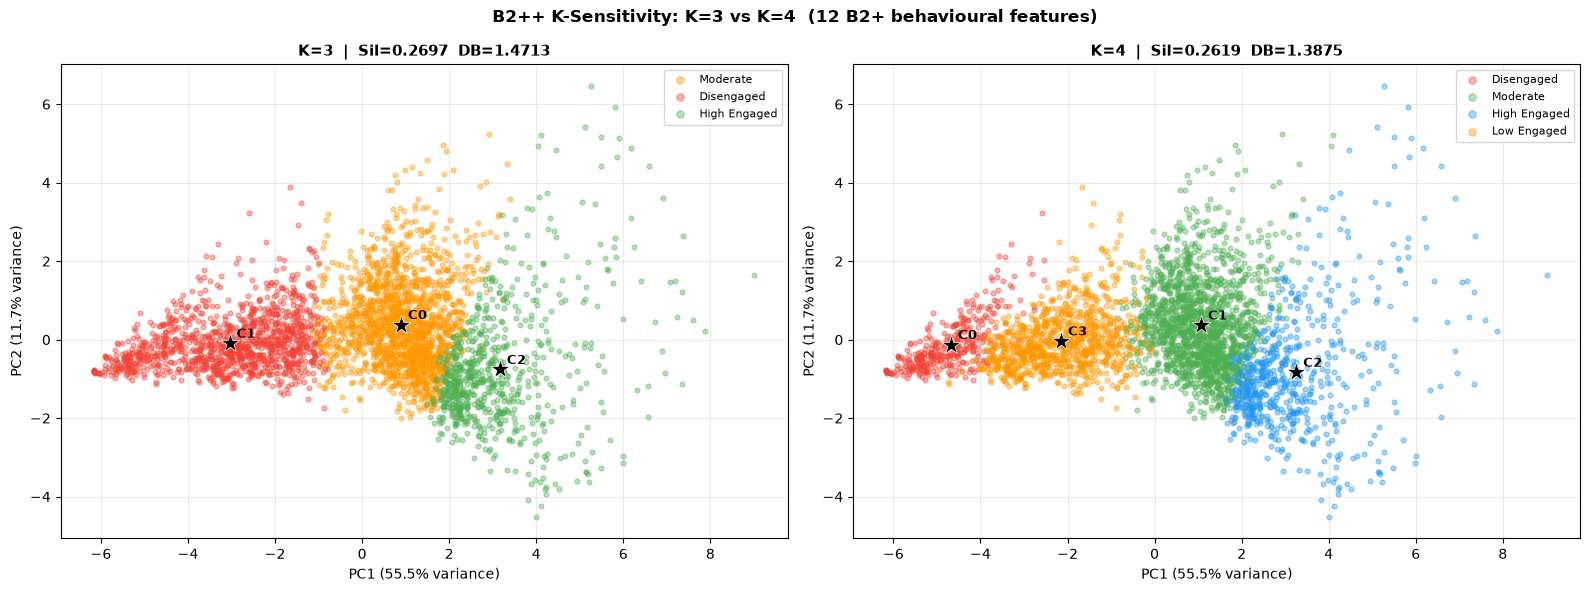

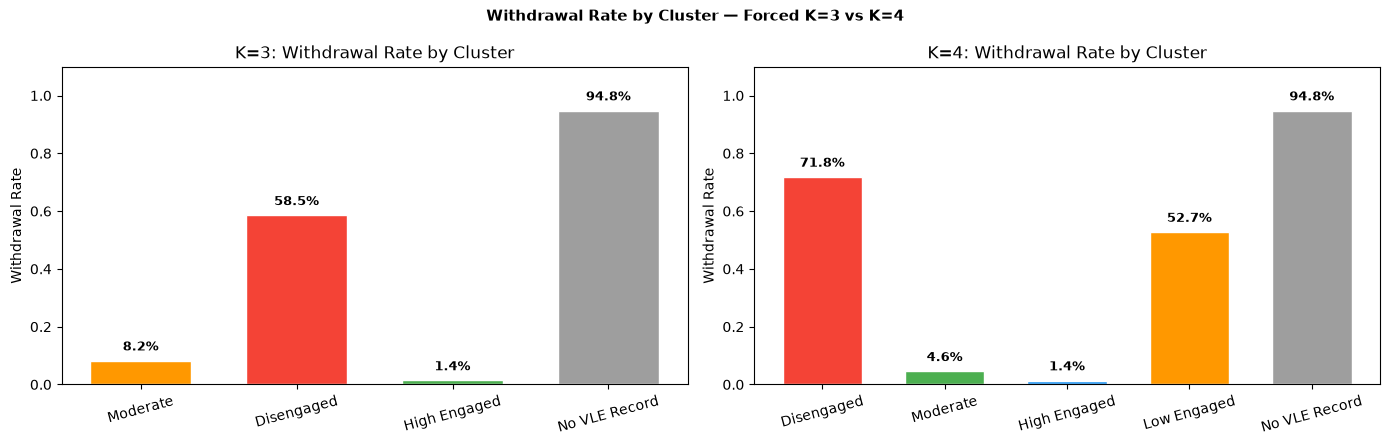


══ K-Selection Summary (12 B2+ features, per-presentation unit) ══


,K,Silhouette ↑,DB ↓,Profiles
0,2,0.3684,1.0616,Disengaged / Engaged / No VLE
1,3,0.2697,1.4713,Disengaged / Moderate / High Engaged / No VLE
2,4,0.2619,1.3875,Disengaged / Low Engaged / Moderate / High Eng...



Note: Silhouette is monotone-decreasing here (curse of dimensionality).
Choose K based on WD-rate separation and educational interpretability.
→ Set CHOSEN_K_FINAL in the next cell to lock in the final cluster_p for I1.


In [38]:
# ── B2++.1  Forced K=3 and K=4 on B2+ 12-feature dataset ──────
# Uses the preprocessed B2+ data (X_clust_scaled_p, vle_clust_train_p,
# scaler_b2p, clip_caps_p, CLUSTER_FEATURES_P) already built in B2+.1.
# Each forced-K model is profiled and visualised for comparison.

from sklearn.decomposition import PCA

_tier_labels_forced = {
    3: ['Disengaged', 'Moderate',    'High Engaged'],
    4: ['Disengaged', 'Low Engaged', 'Moderate',   'High Engaged'],
}
_pal_forced = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']   # low → high
FORCED_KS   = [3, 4]

results_forced = {}   # {K: dict with km, labels, sil, db, archetype, colors, profile}}

sv_all_pairs_f = sv_fff[['id_student', 'code_presentation']].drop_duplicates()

for FK in FORCED_KS:
    # ── 1. Fit ───────────────────────────────────────────────────
    km_f     = KMeans(n_clusters=FK, init='k-means++', n_init=50, random_state=42)
    labels_f = km_f.fit_predict(X_clust_scaled_p)

    sil_f = silhouette_score(X_clust_scaled_p, labels_f)
    db_f  = davies_bouldin_score(X_clust_scaled_p, labels_f)

    # ── 2. Archetype naming: rank by mean active_days ────────────
    tmp_df        = vle_clust_train_p.copy()
    tmp_df['km_label'] = labels_f
    mean_act_f    = tmp_df.groupby('km_label')['active_days'].mean()
    sorted_f      = mean_act_f.sort_values().index.tolist()
    names_f       = _tier_labels_forced[FK]
    archetype_f   = {lbl: names_f[rank] for rank, lbl in enumerate(sorted_f)}
    archetype_f[FK] = 'No VLE Record'
    colors_f      = {lbl: _pal_forced[rank] for rank, lbl in enumerate(sorted_f)}
    colors_f[FK]  = '#9E9E9E'

    # ── 3. Predict all FFF students ──────────────────────────────
    vle_all_f = (
        vle_clust_p.merge(sv_all_pairs_f, on=['id_student', 'code_presentation'], how='inner')
        .copy()
    )
    for feat, cap in clip_caps_p.items():
        vle_all_f[feat] = vle_all_f[feat].clip(upper=cap)
    X_all_f = scaler_b2p.transform(vle_all_f[CLUSTER_FEATURES_P].values)
    vle_all_f['km_label'] = km_f.predict(X_all_f)

    cmap_f = dict(zip(
        zip(vle_all_f['id_student'], vle_all_f['code_presentation']),
        vle_all_f['km_label']
    ))
    col_name = f'cluster_k{FK}'
    df_b1p[col_name] = df_b1p.apply(
        lambda r: cmap_f.get((r['id_student'], r['code_presentation']), FK), axis=1
    ).astype(int)

    # ── 4. Cluster profile ───────────────────────────────────────
    rows_f = []
    for lbl in range(FK + 1):
        mask = df_b1p[col_name] == lbl
        if not mask.any():
            continue
        sub = df_b1p[mask]
        rows_f.append({
            'Cluster':               lbl,
            'Archetype':             archetype_f[lbl],
            'N':                     int(mask.sum()),
            'WD Rate':               f"{(sub['label'] == 1).mean():.1%}",
            'Avg active_days':       round(sub['active_days'].mean(),        1),
            'Avg mean_score':        round(sub['mean_score'].mean(),         2),
            'Avg assessment_clicks': round(sub['assessment_clicks'].mean(),  0),
            'Avg reg_offset':        round(sub['reg_offset'].mean(),         1),
        })

    results_forced[FK] = {
        'km': km_f, 'labels': labels_f,
        'sil': sil_f, 'db': db_f,
        'archetype': archetype_f, 'colors': colors_f,
        'profile': pd.DataFrame(rows_f),
    }

    print(f"\n{'═'*55}")
    print(f"  K = {FK}   Silhouette = {sil_f:.4f}   Davies-Bouldin = {db_f:.4f}")
    print(f"{'═'*55}")
    display(results_forced[FK]['profile'])

# ── 5. Side-by-side PCA scatter (K=3 vs K=4) ─────────────────
pca_shared  = PCA(n_components=2, random_state=42).fit(X_clust_scaled_p)
X_pca_f     = pca_shared.transform(X_clust_scaled_p)
var_exp_f   = pca_shared.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, FK in zip(axes, FORCED_KS):
    r = results_forced[FK]
    for lbl in range(FK):
        mask = r['labels'] == lbl
        ax.scatter(X_pca_f[mask, 0], X_pca_f[mask, 1],
                   c=r['colors'][lbl], alpha=0.4, s=12, label=r['archetype'][lbl])
    ctrs_pca = pca_shared.transform(r['km'].cluster_centers_)
    ax.scatter(ctrs_pca[:, 0], ctrs_pca[:, 1],
               marker='*', s=200, c='black', zorder=5, edgecolors='white', linewidths=0.5)
    for i, (cx, cy) in enumerate(ctrs_pca):
        ax.annotate(f'C{i}', (cx, cy), xytext=(5, 4),
                    textcoords='offset points', fontsize=9, fontweight='bold')
    ax.set_title(f'K={FK}  |  Sil={r["sil"]:.4f}  DB={r["db"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp_f[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({var_exp_f[1]:.1%} variance)')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.25)

plt.suptitle('B2++ K-Sensitivity: K=3 vs K=4  (12 B2+ behavioural features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Withdrawal-rate bar chart: K=3 and K=4 side by side ────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, FK in zip(axes, FORCED_KS):
    r = results_forced[FK]
    lbl_range = list(range(FK + 1))
    wd_vals_f  = [(df_b1p[df_b1p[f'cluster_k{FK}'] == k]['label'] == 1).mean()
                  for k in lbl_range]
    names_bar  = [r['archetype'][k] for k in lbl_range]
    colors_bar = [r['colors'][k]    for k in lbl_range]
    bars_f = ax.bar(names_bar, wd_vals_f, color=colors_bar, edgecolor='white', width=0.65)
    ax.set_title(f'K={FK}: Withdrawal Rate by Cluster')
    ax.set_ylabel('Withdrawal Rate')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars_f, wd_vals_f):
        ax.text(b.get_x() + b.get_width()/2, v + 0.025, f'{v:.1%}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Withdrawal Rate by Cluster — Forced K=3 vs K=4',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7. Full comparison table: K=2, K=3, K=4 ──────────────────
print("\n══ K-Selection Summary (12 B2+ features, per-presentation unit) ══")
comp_rows = [
    {'K': 2, 'Silhouette ↑': round(sil_p, 4), 'DB ↓': round(db_p, 4),
     'Profiles': 'Disengaged / Engaged / No VLE'},
    {'K': 3, 'Silhouette ↑': round(results_forced[3]['sil'], 4),
              'DB ↓': round(results_forced[3]['db'], 4),
     'Profiles': 'Disengaged / Moderate / High Engaged / No VLE'},
    {'K': 4, 'Silhouette ↑': round(results_forced[4]['sil'], 4),
              'DB ↓': round(results_forced[4]['db'], 4),
     'Profiles': 'Disengaged / Low Engaged / Moderate / High Engaged / No VLE'},
]
display(pd.DataFrame(comp_rows))
print("\nNote: Silhouette is monotone-decreasing here (curse of dimensionality).")
print("Choose K based on WD-rate separation and educational interpretability.")
print("→ Set CHOSEN_K_FINAL in the next cell to lock in the final cluster_p for I1.")


In [39]:
# ── B2++.2  Final K Choice → update cluster_p and artefacts ───
# ┌─────────────────────────────────────────────────────────┐
# │  SET THIS VALUE after reviewing the profiles above.     │
# │  Options: 2  (binary B2+)                               │
# │           3  (Disengaged / Moderate / High Engaged)     │
# │           4  (4-tier engagement ladder)                 │
# └─────────────────────────────────────────────────────────┘
CHOSEN_K_FINAL = 3

import joblib, json, os

# ── Resolve model from the chosen K ────────────────────────────
if CHOSEN_K_FINAL == 2:
    _km_final   = km_b2p
    _arch_final = archetype_p
    _clrs_final = cluster_colors_p
    _col        = 'cluster_p'           # already assigned in B2+.2
elif CHOSEN_K_FINAL in results_forced:
    r           = results_forced[CHOSEN_K_FINAL]
    _km_final   = r['km']
    _arch_final = r['archetype']
    _clrs_final = r['colors']
    _col        = f'cluster_k{CHOSEN_K_FINAL}'
else:
    raise ValueError(f"CHOSEN_K_FINAL={CHOSEN_K_FINAL} not available. "
                     f"Run B2++.1 first, or choose 2, 3, or 4.")

# ── Overwrite cluster_p with final choice ──────────────────────
df_b1p['cluster_p'] = df_b1p[_col]
NO_VLE_FINAL = CHOSEN_K_FINAL
cluster_names_final = dict(_arch_final)

print(f"cluster_p  ←  K={CHOSEN_K_FINAL} solution  ({_col})")
print(f"\n── Final Cluster Distribution (all presentations) ──")
for lbl, cnt in df_b1p['cluster_p'].value_counts().sort_index().items():
    wd = (df_b1p[df_b1p['cluster_p'] == lbl]['label'] == 1).mean()
    print(f"  {lbl}  {_arch_final.get(lbl, '?'):20s}  N={cnt:5,}  WD={wd:.1%}")

# ── Save updated artefacts ─────────────────────────────────────
SAVE_DIR_F = os.path.dirname(os.path.abspath('OULAD.ipynb'))
joblib.dump(scaler_b2p,  os.path.join(SAVE_DIR_F, 'scaler.pkl'))
joblib.dump(_km_final,   os.path.join(SAVE_DIR_F, 'km_final.pkl'))

meta_path_f = os.path.join(SAVE_DIR_F, 'model_meta.json')
with open(meta_path_f) as fh:
    meta_f = json.load(fh)

meta_f['cluster_features'] = CLUSTER_FEATURES_P
meta_f['clip_features']    = CLIP_FEATURES_P
meta_f['clip_caps']        = {k: float(v) for k, v in clip_caps_p.items()}
meta_f['cluster_names']    = {str(k): v for k, v in cluster_names_final.items()}

with open(meta_path_f, 'w') as fh:
    json.dump(meta_f, fh, indent=2)

print(f"\nSaved: scaler.pkl  km_final.pkl  model_meta.json  →  {SAVE_DIR_F}")
print(f"  KMeans(K={CHOSEN_K_FINAL}),  12-feature B2+ scaler")
print(f"\nNext → I1: df_b1p (16 features) + cluster_p ({CHOSEN_K_FINAL+1} categories) → XGBoost")


cluster_p  ←  K=3 solution  (cluster_k3)

── Final Cluster Distribution (all presentations) ──
  0  Moderate              N=3,265  WD=8.2%
  1  Disengaged            N=2,530  WD=58.5%
  2  High Engaged          N=1,297  WD=1.4%
  3  No VLE Record         N=  670  WD=94.8%

Saved: scaler.pkl  km_final.pkl  model_meta.json  →  d:\Code\CS\code
  KMeans(K=3),  12-feature B2+ scaler

Next → I1: df_b1p (16 features) + cluster_p (4 categories) → XGBoost


## 18. B2-Ext — K-Sensitivity with 16 Behavioural Features

Extends the 12-feature B2+ dataset with **4 temporal and assessment-behaviour features**
that were absent from B2/B2+:

| New Feature | Source | Captures |
|---|---|---|
| `engagement_slope` | studentVle.date | Weekly VLE trend (positive = growing engagement) |
| `max_inactivity_gap` | studentVle.date | Longest break from VLE in days (dropout signal) |
| `missing_assessments` | studentAssessment + assessments | Unsubmitted TMA/CMA count (direct disengagement) |
| `submission_lead_time` | studentAssessment + assessments.date | Avg days before deadline submitted (planning style) |

Hypothesis: these trajectory/assessment features will sharpen cluster boundaries and
produce profiles that better distinguish students on a "withdrawal trajectory" from
those who are stably low-engagement.

In [40]:
# ── B2-Ext.1  Feature Engineering: 4 new features ─────────────────────────────
# Adds to B2+ 12-feature set:
#   engagement_slope     weekly VLE trend (clicks/week slope)
#   max_inactivity_gap   longest break from VLE in days
#   missing_assessments  unsubmitted TMA/CMA count
#   submission_lead_time avg days before deadline of submitted TMAs/CMAs
# All computed per (id_student, code_presentation); covers all 4 presentations.

from sklearn.preprocessing import StandardScaler

# ── (a) engagement_slope: vectorised β = cov(week, clicks) / var(week) ────────
# OULAD date = days relative to module start → week = date // 7
sv_wk = sv_fff.copy()
sv_wk['week'] = sv_wk['date'] // 7
weekly_agg = (sv_wk
    .groupby(['id_student', 'code_presentation', 'week'])['sum_click']
    .sum().reset_index())

gb_wk = weekly_agg.groupby(['id_student', 'code_presentation'])
weekly_agg['_wk_m']  = gb_wk['week'].transform('mean')
weekly_agg['_clk_m'] = gb_wk['sum_click'].transform('mean')
weekly_agg['_cov']   = (weekly_agg['week'] - weekly_agg['_wk_m']) * (weekly_agg['sum_click'] - weekly_agg['_clk_m'])
weekly_agg['_varx']  = (weekly_agg['week'] - weekly_agg['_wk_m']) ** 2

cov_sum  = weekly_agg.groupby(['id_student', 'code_presentation'])['_cov'].sum()
var_sum  = weekly_agg.groupby(['id_student', 'code_presentation'])['_varx'].sum()
slope_df = ((cov_sum / var_sum)
            .replace([np.inf, -np.inf], 0).fillna(0)
            .reset_index(name='engagement_slope'))

# ── (b) max_inactivity_gap: longest consecutive gap in access days ─────────────
sv_uniq = (sv_fff[['id_student', 'code_presentation', 'date']]
           .drop_duplicates()
           .sort_values(['id_student', 'code_presentation', 'date']))
sv_uniq['_diff'] = sv_uniq.groupby(['id_student', 'code_presentation'])['date'].diff()
gap_df = (sv_uniq.groupby(['id_student', 'code_presentation'])['_diff']
          .max().fillna(0).astype(int)
          .reset_index(name='max_inactivity_gap'))

# ── (c) missing_assessments: TMA/CMA not submitted (excl. Exam) ───────────────
ass_ext = assessments[
    (assessments['code_module'] == TARGET_MODULE) &
    (assessments['assessment_type'].isin(['TMA', 'CMA']))
].copy()

n_per_pres = (ass_ext.groupby('code_presentation')['id_assessment']
              .nunique().reset_index(name='n_tma_cma'))

sa_sub_ext = (student_assess
    .merge(ass_ext[['id_assessment', 'code_presentation']], on='id_assessment')
    .query('is_banked == 0')
    .groupby(['id_student', 'code_presentation'])['id_assessment']
    .count().reset_index(name='n_submitted'))

all_pairs_ext = df_b1p[['id_student', 'code_presentation']].drop_duplicates()
miss_df = (all_pairs_ext
    .merge(n_per_pres, on='code_presentation', how='left')
    .merge(sa_sub_ext, on=['id_student', 'code_presentation'], how='left'))
miss_df['n_submitted']        = miss_df['n_submitted'].fillna(0).astype(int)
miss_df['missing_assessments'] = (miss_df['n_tma_cma'] - miss_df['n_submitted']).clip(lower=0).astype(int)
miss_df = miss_df[['id_student', 'code_presentation', 'missing_assessments']]

# ── (d) submission_lead_time: avg days submitted BEFORE deadline ───────────────
sa_dated = (student_assess
    .merge(ass_ext[['id_assessment', 'code_presentation', 'date']], on='id_assessment')
    .query('is_banked == 0'))
sa_dated = sa_dated[sa_dated['score'].notna()]
sa_dated['lead_time'] = sa_dated['date'] - sa_dated['date_submitted']
lead_df = (sa_dated.groupby(['id_student', 'code_presentation'])['lead_time']
           .mean().reset_index(name='submission_lead_time'))
_lead_fill = lead_df['submission_lead_time'].mean()  # fill value for non-submitters

# ── Merge new features into df_b1p and vle_clust_ppp ──────────────────────────
NEW_FEATS_EXT = ['engagement_slope', 'max_inactivity_gap',
                 'missing_assessments', 'submission_lead_time']

# Drop if already present (re-run safety)
df_b1p.drop(columns=[c for c in NEW_FEATS_EXT if c in df_b1p.columns], inplace=True)

df_b1p = (df_b1p
    .merge(miss_df,  on=['id_student', 'code_presentation'], how='left')
    .merge(lead_df,  on=['id_student', 'code_presentation'], how='left')
    .merge(slope_df, on=['id_student', 'code_presentation'], how='left')
    .merge(gap_df,   on=['id_student', 'code_presentation'], how='left'))

df_b1p['engagement_slope']     = df_b1p['engagement_slope'].fillna(0)
df_b1p['max_inactivity_gap']   = df_b1p['max_inactivity_gap'].fillna(0).astype(int)
df_b1p['missing_assessments']  = df_b1p['missing_assessments'].fillna(0).astype(int)
df_b1p['submission_lead_time'] = df_b1p['submission_lead_time'].fillna(_lead_fill)

# B2-Ext VLE-active dataset (per-presentation, has VLE records)
CLUSTER_FEATURES_EXT = CLUSTER_FEATURES_P + NEW_FEATS_EXT  # 16 total

vle_clust_ext = vle_clust_p.copy()
for fdf in [slope_df, gap_df, miss_df, lead_df]:
    vle_clust_ext = vle_clust_ext.merge(
        fdf, on=['id_student', 'code_presentation'], how='left')
vle_clust_ext['engagement_slope']     = vle_clust_ext['engagement_slope'].fillna(0)
vle_clust_ext['max_inactivity_gap']   = vle_clust_ext['max_inactivity_gap'].fillna(0).astype(int)
vle_clust_ext['missing_assessments']  = vle_clust_ext['missing_assessments'].fillna(0).astype(int)
vle_clust_ext['submission_lead_time'] = vle_clust_ext['submission_lead_time'].fillna(_lead_fill)

print(f"B2-Ext feature set: {len(CLUSTER_FEATURES_EXT)} features")
print(f"  B2+ base (12) + new (4): {NEW_FEATS_EXT}")
print(f"\n── New feature summary (all VLE-active, {len(vle_clust_ext):,} rows) ──")
display(vle_clust_ext[NEW_FEATS_EXT].describe().round(3))


B2-Ext feature set: 16 features
  B2+ base (12) + new (4): ['engagement_slope', 'max_inactivity_gap', 'missing_assessments', 'submission_lead_time']

── New feature summary (all VLE-active, 7,762 rows) ──


,engagement_slope,max_inactivity_gap,missing_assessments,submission_lead_time
count,7762.000,7762.000,7762.000,7762.000
mean,-0.168,19.476,5.018,36.678
std,12.690,18.912,5.254,32.316
min,-189.000,0.000,0.000,-187.000
25%,-2.175,9.000,0.000,8.896
50%,0.000,15.000,1.000,36.678
75%,1.445,25.000,11.000,57.333
max,382.000,225.000,12.000,236.000


B2-Ext training set: 3,897 VLE-active (student, pres) pairs

99th-pct caps (new feature):
  max_inactivity_gap  cap = 93 days

══════════════════════════════════════════════════════════
  K = 2   Silhouette = 0.3673   Davies-Bouldin = 1.1341
══════════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg mean_score,Avg missing_assess,Avg lead_days,Avg engage_slope,Avg max_gap_days
0,0,Engaged,4435,4.7%,113.5,78.28,0.75,42.9,0.020,20.7
1,1,Disengaged,2657,58.7%,26.3,48.97,10.38,26.3,-0.524,22.4
2,2,No VLE Record,670,94.8%,5.4,5.43,12.00,36.7,0.000,0.0



══════════════════════════════════════════════════════════
  K = 3   Silhouette = 0.3098   Davies-Bouldin = 1.2821
══════════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg mean_score,Avg missing_assess,Avg lead_days,Avg engage_slope,Avg max_gap_days
0,0,High Engaged,4212,2.5%,115.9,78.51,0.43,42.8,0.123,20.0
1,1,Moderate,2161,52.3%,37.4,67.08,9.48,24.9,-2.737,27.6
2,2,Disengaged,719,74.0%,6.2,2.26,11.97,36.3,5.686,10.5
3,3,No VLE Record,670,94.8%,5.4,5.43,12.00,36.7,0.000,0.0



══════════════════════════════════════════════════════════
  K = 4   Silhouette = 0.2387   Davies-Bouldin = 1.5036
══════════════════════════════════════════════════════════


,Cluster,Archetype,N,WD Rate,Avg active_days,Avg mean_score,Avg missing_assess,Avg lead_days,Avg engage_slope,Avg max_gap_days
0,0,High Engaged,1432,1.5%,167.8,82.57,0.18,57.4,-2.284,12.3
1,1,Disengaged,717,73.9%,6.2,2.27,11.97,36.3,5.745,10.5
2,2,Low Engaged,2076,53.5%,36.2,66.75,9.64,24.5,-2.927,27.0
3,3,Moderate,2867,3.7%,88.3,76.33,0.72,35.2,1.368,24.4
4,4,No VLE Record,670,94.8%,5.4,5.43,12.00,36.7,0.000,0.0


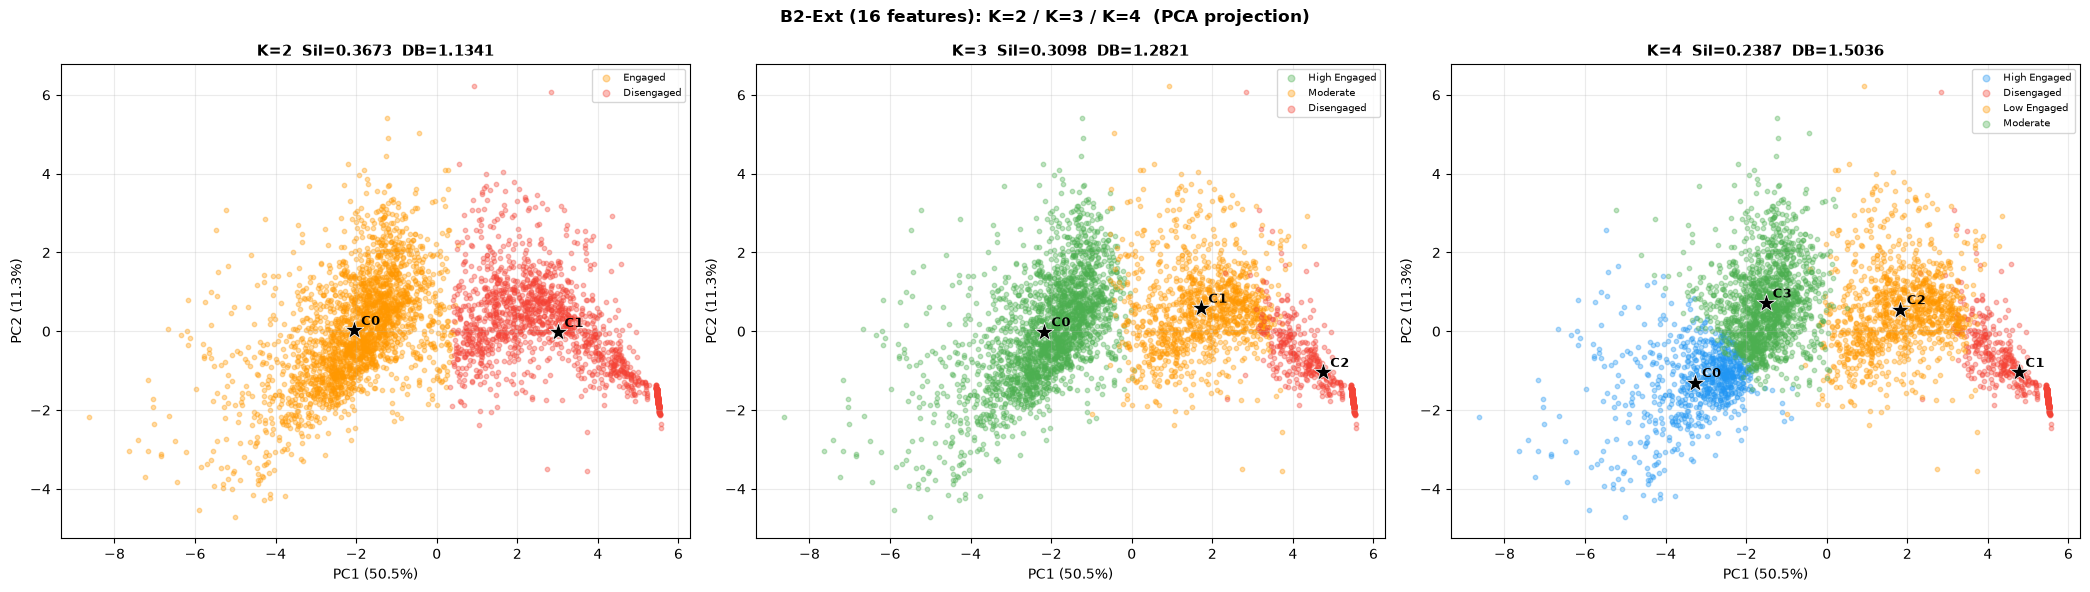


══ Cross-Model K-Selection Summary ══


,Model,K,Silhouette ↑,DB ↓
0,B2 (7 feat),2,0.4329,0.8466
1,,3,0.3443,1.1472
2,,4,0.3500,1.0119
3,B2+ (12 feat),2,0.3684,1.0616
4,,3,0.2697,1.4713
5,,4,0.2619,1.3875
6,B2-Ext(16 feat),2,0.3673,1.1341
7,,3,0.3098,1.2821
8,,4,0.2387,1.5036



Note: Silhouette decreases with dimensionality; compare DB for cross-model fairness.


In [41]:
# ── B2-Ext.2  K=2, 3, 4 clustering on 16-feature dataset ──────────────────────

# ── 2013 VLE-active training subset ──────────────────────────────────────────
vle_clust_train_ext = vle_clust_ext[
    vle_clust_ext['code_presentation'].isin(['2013B', '2013J'])
].copy()
print(f"B2-Ext training set: {len(vle_clust_train_ext):,} VLE-active (student, pres) pairs")

# ── Clipping (upper 99th pct for skewed features) ─────────────────────────────
CLIP_FEATURES_EXT = CLIP_FEATURES_P + ['max_inactivity_gap']
clip_caps_ext = {}
for f in CLIP_FEATURES_EXT:
    cap = np.percentile(vle_clust_train_ext[f].values, 99)
    clip_caps_ext[f] = cap
    vle_clust_train_ext[f] = vle_clust_train_ext[f].clip(upper=cap)

print(f"\n99th-pct caps (new feature):")
print(f"  max_inactivity_gap  cap = {clip_caps_ext['max_inactivity_gap']:.0f} days")

scaler_ext = StandardScaler()
X_train_ext = scaler_ext.fit_transform(vle_clust_train_ext[CLUSTER_FEATURES_EXT].values)

# ── K = 2, 3, 4 loop ──────────────────────────────────────────────────────────
_tier_ext = {
    2: ['Disengaged', 'Engaged'],
    3: ['Disengaged', 'Moderate',    'High Engaged'],
    4: ['Disengaged', 'Low Engaged', 'Moderate',   'High Engaged'],
}
_pal_ext = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']

results_ext = {}
sv_all_pairs_ext = sv_fff[['id_student', 'code_presentation']].drop_duplicates()

for K in [2, 3, 4]:
    km_ext     = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=42)
    labels_ext = km_ext.fit_predict(X_train_ext)
    sil_ext    = silhouette_score(X_train_ext, labels_ext)
    db_ext     = davies_bouldin_score(X_train_ext, labels_ext)

    # Archetype naming: rank by active_days
    tmp = vle_clust_train_ext.copy()
    tmp['km_label'] = labels_ext
    sorted_ext = tmp.groupby('km_label')['active_days'].mean().sort_values().index.tolist()
    arch_ext   = {lbl: _tier_ext[K][rank] for rank, lbl in enumerate(sorted_ext)}
    arch_ext[K] = 'No VLE Record'
    clrs_ext   = {lbl: _pal_ext[rank] for rank, lbl in enumerate(sorted_ext)}
    clrs_ext[K] = '#9E9E9E'

    # Predict all FFF (student, pres)
    vle_all_ext = (vle_clust_ext
        .merge(sv_all_pairs_ext, on=['id_student', 'code_presentation'], how='inner')
        .copy())
    for f, cap in clip_caps_ext.items():
        if f in vle_all_ext.columns:
            vle_all_ext[f] = vle_all_ext[f].clip(upper=cap)
    vle_all_ext['km_label'] = km_ext.predict(
        scaler_ext.transform(vle_all_ext[CLUSTER_FEATURES_EXT].values))
    cmap_ext = dict(zip(
        zip(vle_all_ext['id_student'], vle_all_ext['code_presentation']),
        vle_all_ext['km_label']))

    col_ext = f'cluster_ext_k{K}'
    df_b1p[col_ext] = df_b1p.apply(
        lambda r: cmap_ext.get((r['id_student'], r['code_presentation']), K), axis=1
    ).astype(int)

    # Profile
    rows_ext = []
    for lbl in range(K + 1):
        mask = df_b1p[col_ext] == lbl
        if not mask.any():
            continue
        sub = df_b1p[mask]
        rows_ext.append({
            'Cluster':              lbl,
            'Archetype':            arch_ext[lbl],
            'N':                    int(mask.sum()),
            'WD Rate':              f"{(sub['label'] == 1).mean():.1%}",
            'Avg active_days':      round(sub['active_days'].mean(),           1),
            'Avg mean_score':       round(sub['mean_score'].mean(),            2),
            'Avg missing_assess':   round(sub['missing_assessments'].mean(),   2),
            'Avg lead_days':        round(sub['submission_lead_time'].mean(),  1),
            'Avg engage_slope':     round(sub['engagement_slope'].mean(),      3),
            'Avg max_gap_days':     round(sub['max_inactivity_gap'].mean(),    1),
        })

    results_ext[K] = {
        'km': km_ext, 'labels': labels_ext, 'sil': sil_ext, 'db': db_ext,
        'archetype': arch_ext, 'colors': clrs_ext,
        'profile': pd.DataFrame(rows_ext),
    }

    print(f"\n{'═'*58}")
    print(f"  K = {K}   Silhouette = {sil_ext:.4f}   Davies-Bouldin = {db_ext:.4f}")
    print(f"{'═'*58}")
    display(results_ext[K]['profile'])

# ── PCA scatter: K=2, K=3, K=4 side by side ──────────────────────────────────
pca_ext   = PCA(n_components=2, random_state=42).fit(X_train_ext)
X_pca_ext = pca_ext.transform(X_train_ext)
var_ext   = pca_ext.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, K in zip(axes, [2, 3, 4]):
    r = results_ext[K]
    for lbl in range(K):
        m = r['labels'] == lbl
        ax.scatter(X_pca_ext[m, 0], X_pca_ext[m, 1],
                   c=r['colors'][lbl], alpha=0.35, s=10, label=r['archetype'][lbl])
    ctrs_e = pca_ext.transform(r['km'].cluster_centers_)
    ax.scatter(ctrs_e[:, 0], ctrs_e[:, 1],
               marker='*', s=200, c='black', zorder=5, edgecolors='white', linewidths=0.5)
    for ci, (cx, cy) in enumerate(ctrs_e):
        ax.annotate(f'C{ci}', (cx, cy), xytext=(5, 4),
                    textcoords='offset points', fontsize=9, fontweight='bold')
    ax.set_title(f'K={K}  Sil={r["sil"]:.4f}  DB={r["db"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_ext[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_ext[1]:.1%})')
    ax.legend(fontsize=7, markerscale=1.5)
    ax.grid(True, alpha=0.25)

plt.suptitle('B2-Ext (16 features): K=2 / K=3 / K=4  (PCA projection)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Cross-model comparison: B2(7) / B2+(12) / B2-Ext(16) ─────────────────────
print("\n══ Cross-Model K-Selection Summary ══")
rows_cmp = []
for model, sils, dbs in [
    ('B2  (7 feat)',   [sil_final,                        results_b2_forced[3]['sil'], results_b2_forced[4]['sil']],
                       [db_final,                         results_b2_forced[3]['db'],  results_b2_forced[4]['db']]),
    ('B2+ (12 feat)',  [sil_p,                            results_forced[3]['sil'],    results_forced[4]['sil']],
                       [db_p,                             results_forced[3]['db'],     results_forced[4]['db']]),
    ('B2-Ext(16 feat)',[results_ext[2]['sil'],            results_ext[3]['sil'],       results_ext[4]['sil']],
                       [results_ext[2]['db'],             results_ext[3]['db'],        results_ext[4]['db']]),
]:
    for K, sil, db in zip([2, 3, 4], sils, dbs):
        rows_cmp.append({'Model': model if K == 2 else '', 'K': K,
                         'Silhouette ↑': round(sil, 4), 'DB ↓': round(db, 4)})
display(pd.DataFrame(rows_cmp))
print("\nNote: Silhouette decreases with dimensionality; compare DB for cross-model fairness.")


PCA — PC1: 67.7%  |  PC2: 19.0%  |  Total: 86.7% variance explained


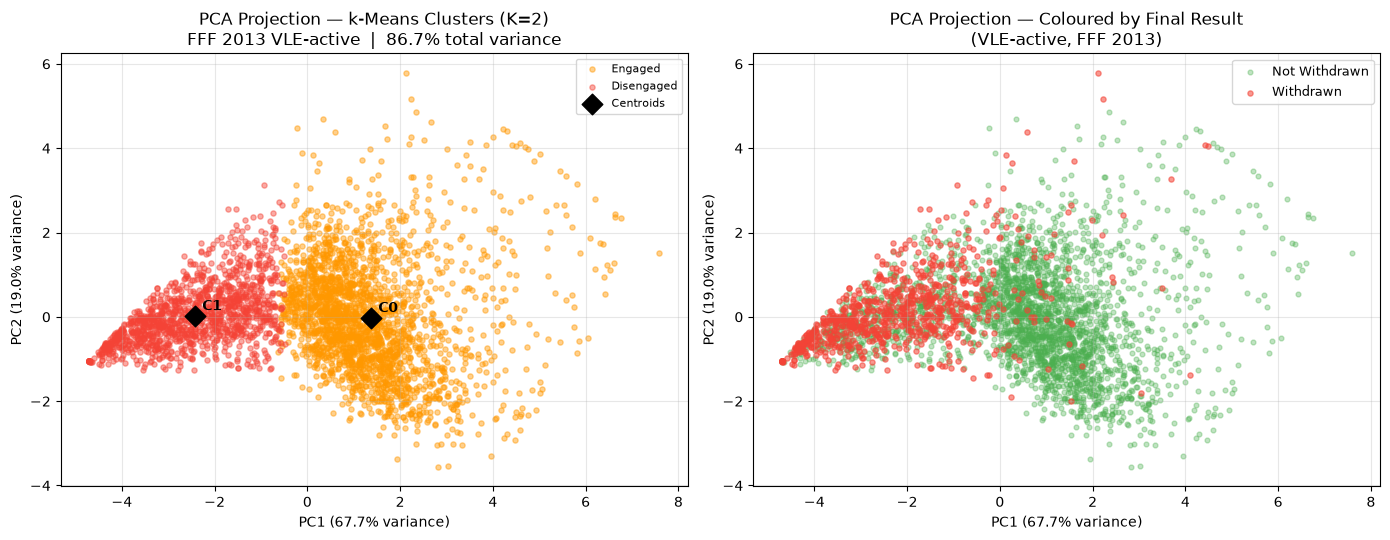

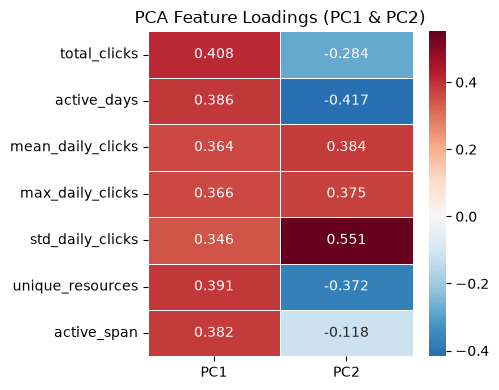


PC1 most influenced by: total_clicks (loading=0.408)
PC2 most influenced by: std_daily_clicks (loading=0.551)


In [42]:
# ── B2.4  PCA 2D Projection ────────────────────────────────────
from sklearn.decomposition import PCA

pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_clust_scaled)
var_exp = pca.explained_variance_ratio_

centroids_pca = pca.transform(km_b2.cluster_centers_)

print(f"PCA — PC1: {var_exp[0]:.1%}  |  PC2: {var_exp[1]:.1%}  |  "
      f"Total: {sum(var_exp):.1%} variance explained")

# Withdrawal mask aligned to vle_clust row order (de-duped by id_student)
# Some students appear in both 2013B and 2013J; keep first occurrence.
si_dedup = si_fff_train.drop_duplicates(subset='id_student').set_index('id_student')
wd_mask_pca = si_dedup.loc[vle_clust['id_student'], 'final_result'].eq('Withdrawn').values

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: coloured by cluster
for c in range(CHOSEN_K):
    mask = labels_train_vle == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[c], alpha=0.45, s=14, label=cluster_names[c])
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='D', s=110, c='black', zorder=5, label='Centroids')
for i, (cx, cy) in enumerate(centroids_pca):
    axes[0].annotate(f'C{i}', (cx, cy), xytext=(5, 4),
                     textcoords='offset points', fontsize=10, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
axes[0].set_title(f'PCA Projection — k-Means Clusters (K={CHOSEN_K})\n'
                  f'FFF 2013 VLE-active  |  {sum(var_exp):.1%} total variance')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: coloured by withdrawal outcome
axes[1].scatter(X_pca[~wd_mask_pca, 0], X_pca[~wd_mask_pca, 1],
                c='#4CAF50', alpha=0.35, s=12, label='Not Withdrawn')
axes[1].scatter(X_pca[wd_mask_pca, 0], X_pca[wd_mask_pca, 1],
                c='#F44336', alpha=0.55, s=14, label='Withdrawn')
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
axes[1].set_title('PCA Projection — Coloured by Final Result\n(VLE-active, FFF 2013)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── PCA loading heatmap ─────────────────────────────────────────
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES,
                        columns=['PC1', 'PC2'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('PCA Feature Loadings (PC1 & PC2)')
plt.tight_layout()
plt.show()
print("\nPC1 most influenced by:", loadings['PC1'].abs().idxmax(),
      f"(loading={loadings.loc[loadings['PC1'].abs().idxmax(), 'PC1']:.3f})")
print("PC2 most influenced by:", loadings['PC2'].abs().idxmax(),
      f"(loading={loadings.loc[loadings['PC2'].abs().idxmax(), 'PC2']:.3f})")


Computing t-SNE  (perplexity=40, n_iter=1000)  — may take ~30s…
Done.


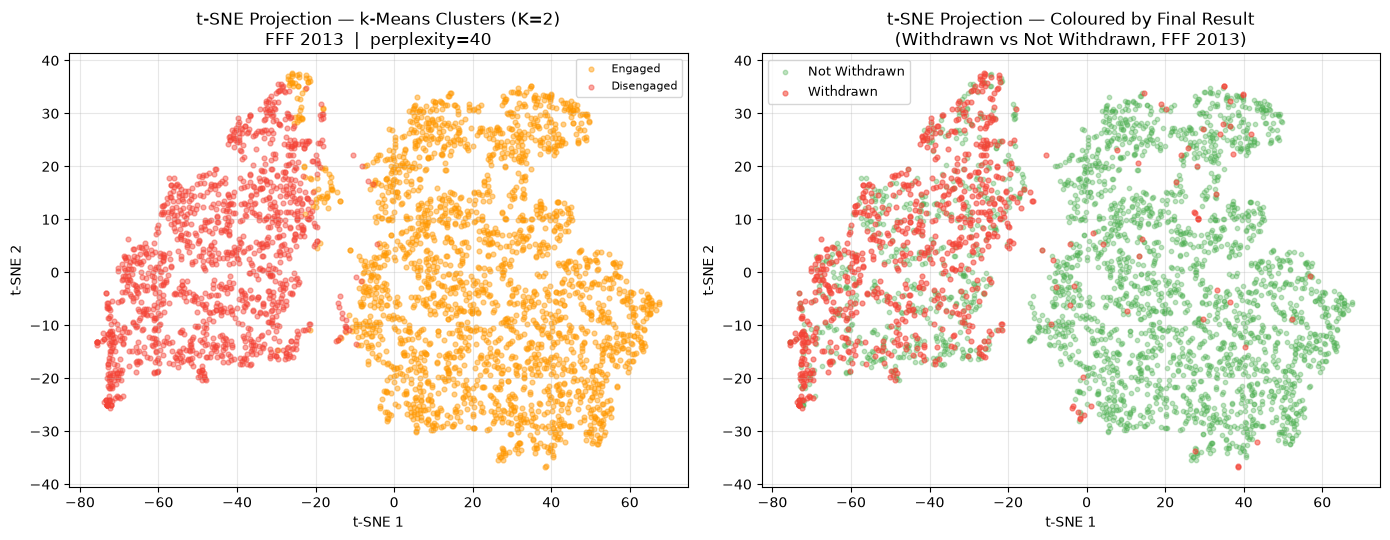

In [43]:
# ── B2.5  t-SNE 2D Projection ─────────────────────────────────
from sklearn.manifold import TSNE

print("Computing t-SNE  (perplexity=40, n_iter=1000)  — may take ~30s…")
tsne  = TSNE(n_components=2, perplexity=40, learning_rate='auto',
             init='pca', random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_clust_scaled)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: coloured by cluster
for c in range(CHOSEN_K):
    mask = labels_train_vle == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=cluster_colors[c], alpha=0.45, s=12, label=cluster_names[c])
axes[0].set_title(f't-SNE Projection — k-Means Clusters (K={CHOSEN_K})\n'
                  f'FFF 2013  |  perplexity=40')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: coloured by final result
axes[1].scatter(X_tsne[~wd_mask_pca, 0], X_tsne[~wd_mask_pca, 1],
                c='#4CAF50', alpha=0.35, s=10, label='Not Withdrawn')
axes[1].scatter(X_tsne[wd_mask_pca, 0], X_tsne[wd_mask_pca, 1],
                c='#F44336', alpha=0.55, s=12, label='Withdrawn')
axes[1].set_title('t-SNE Projection — Coloured by Final Result\n'
                  '(Withdrawn vs Not Withdrawn, FFF 2013)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


── B2 Cluster Profile Summary (2013 Train, incl. No-VLE) ──


,C,Archetype,N,WD Rate,Avg Clicks,Avg Days,Avg Click/Day,Avg Resources,Avg Span
0,0,Engaged,2375,7.2%,3678.0,110.6,4.5,150.9,245.9
1,1,Disengaged,1258,53.0%,551.6,24.7,3.0,46.8,90.1
2,2,No VLE Record,264,93.9%,0.0,0.0,0.0,0.0,0.0


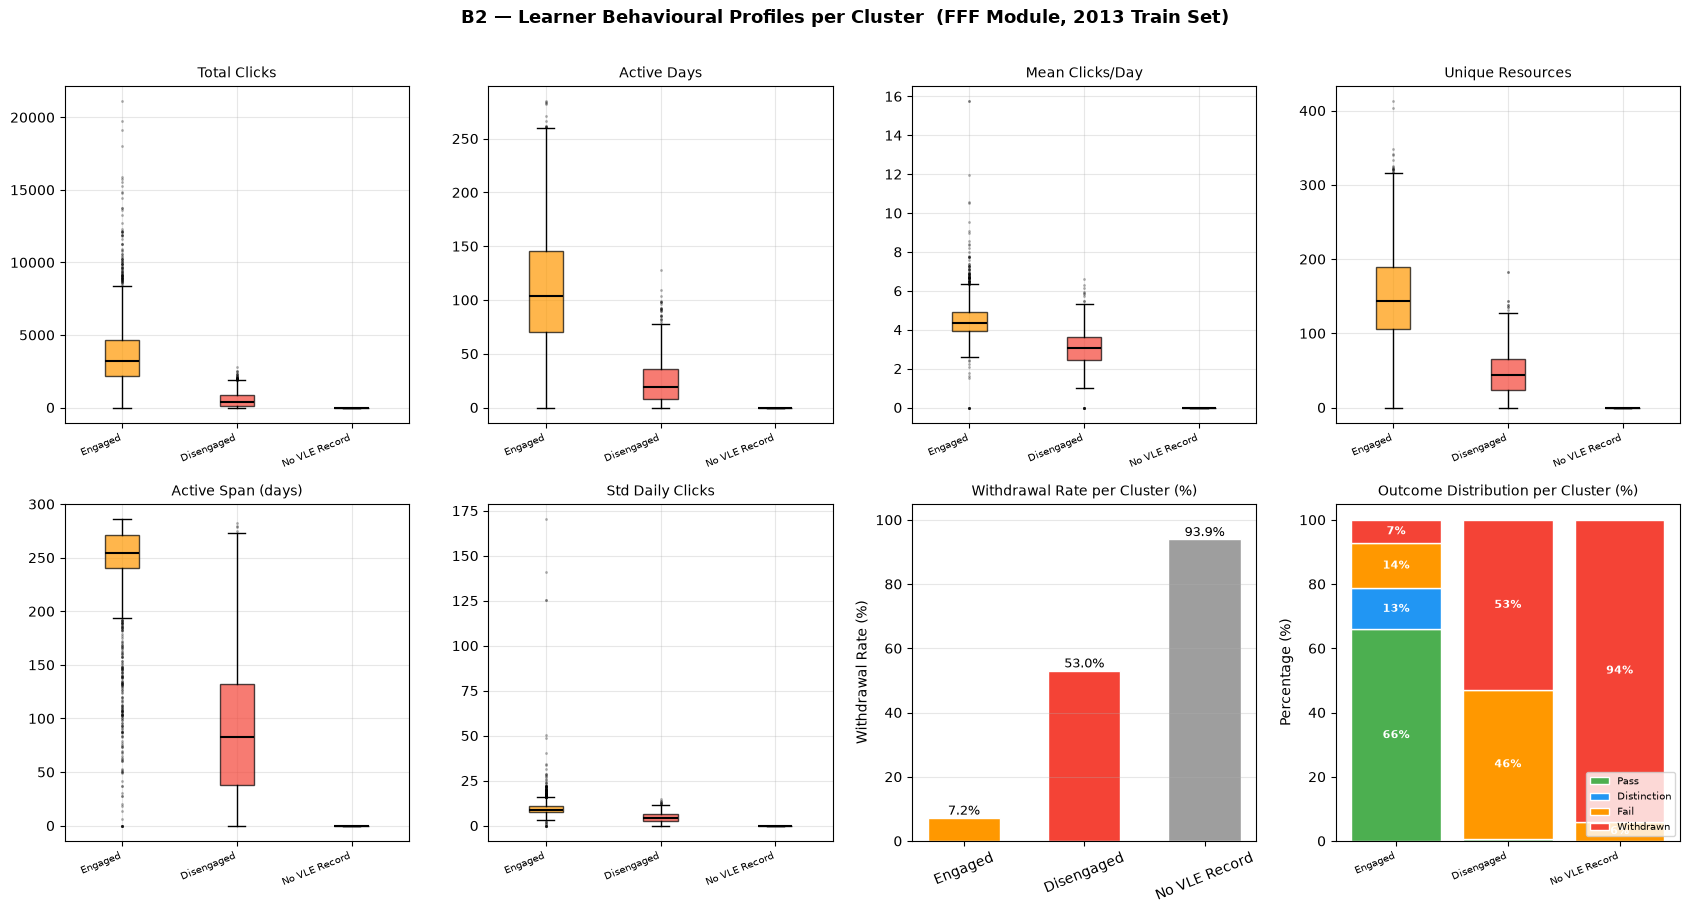


── B2 Learner Archetype Interpretation (2013 FFF) ──
  Archetype                   N     WD%   AvgClicks   AvgDays  AvgResrc
  ─────────────────────────────────────────────────────────────────
  Engaged                 2,375    7.2%       3,678     110.6     150.9
  Disengaged              1,258   53.0%         552      24.7      46.8
  No VLE Record             264   93.9%           0       0.0       0.0

  Silhouette = 0.4329  |  Davies-Bouldin = 0.8466


In [44]:
# ── B2.6  Educational Profile Interpretation ──────────────────
# Merge cluster labels and outcome for ALL 2013 students (incl. no-VLE)

si_fff_train_clust = si_fff_train[['id_student', 'final_result']].copy()
si_fff_train_clust['cluster']      = si_fff_train_clust['id_student'].map(cluster_map).fillna(NO_VLE_LABEL).astype(int)
si_fff_train_clust['cluster_name'] = si_fff_train_clust['cluster'].map(cluster_names)
si_fff_train_clust['withdrawn']    = (si_fff_train_clust['final_result'] == 'Withdrawn').astype(int)

# Merge VLE features (0 for no-VLE students)
si_fff_train_clust = si_fff_train_clust.merge(
    vle_clust[['id_student'] + CLUSTER_FEATURES], on='id_student', how='left')
si_fff_train_clust[CLUSTER_FEATURES] = si_fff_train_clust[CLUSTER_FEATURES].fillna(0)

# ── Profile summary table ──────────────────────────────────────
profile = (si_fff_train_clust
    .groupby(['cluster', 'cluster_name'])
    .agg(
        N                 = ('id_student',        'count'),
        WD_Rate           = ('withdrawn',          'mean'),
        Avg_Clicks        = ('total_clicks',       'mean'),
        Avg_Active_Days   = ('active_days',        'mean'),
        Avg_Clicks_Day    = ('mean_daily_clicks',  'mean'),
        Avg_Resources     = ('unique_resources',   'mean'),
        Avg_Active_Span   = ('active_span',        'mean'),
    )
    .reset_index()
    .sort_values('cluster'))
profile['WD_Rate']  = (profile['WD_Rate'] * 100).round(1).astype(str) + '%'
for col in ['Avg_Clicks', 'Avg_Active_Days', 'Avg_Clicks_Day', 'Avg_Resources', 'Avg_Active_Span']:
    profile[col] = profile[col].round(1)

print("── B2 Cluster Profile Summary (2013 Train, incl. No-VLE) ──")
display(profile.rename(columns={
    'cluster': 'C', 'cluster_name': 'Archetype',
    'WD_Rate': 'WD Rate', 'Avg_Clicks': 'Avg Clicks',
    'Avg_Active_Days': 'Avg Days', 'Avg_Clicks_Day': 'Avg Click/Day',
    'Avg_Resources': 'Avg Resources', 'Avg_Active_Span': 'Avg Span',
}))

# ── Visualisation: 6 feature boxplots + WD rate + outcome dist ─
all_cluster_ids = sorted(si_fff_train_clust['cluster'].unique())
n_cls           = len(all_cluster_ids)
cls_colors      = [cluster_colors[c] for c in all_cluster_ids]
cls_labels      = [cluster_names[c]  for c in all_cluster_ids]

features_to_box = [
    ('total_clicks',      'Total Clicks'),
    ('active_days',       'Active Days'),
    ('mean_daily_clicks', 'Mean Clicks/Day'),
    ('unique_resources',  'Unique Resources'),
    ('active_span',       'Active Span (days)'),
    ('std_daily_clicks',  'Std Daily Clicks'),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
axes = axes.flatten()
fig.suptitle('B2 — Learner Behavioural Profiles per Cluster  (FFF Module, 2013 Train Set)',
             fontsize=13, y=1.01, fontweight='bold')

for idx, (feat, label) in enumerate(features_to_box):
    ax  = axes[idx]
    dat = [si_fff_train_clust[si_fff_train_clust['cluster'] == c][feat].values
           for c in all_cluster_ids]
    bp = ax.boxplot(dat, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, col in zip(bp['boxes'], cls_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    ax.set_xticklabels(cls_labels, fontsize=7.5, rotation=22, ha='right')
    ax.set_title(label, fontsize=10)
    ax.grid(True, alpha=0.3)

# ── Withdrawal rate bar chart per cluster ─────────────────────
ax = axes[6]
wd_rates = [si_fff_train_clust[si_fff_train_clust['cluster'] == c]['withdrawn'].mean() * 100
            for c in all_cluster_ids]
bars = ax.bar(cls_labels, wd_rates, color=cls_colors, edgecolor='white', width=0.6)
ax.set_title('Withdrawal Rate per Cluster (%)', fontsize=10)
ax.set_ylabel('Withdrawal Rate (%)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=22)
for b, v in zip(bars, wd_rates):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}%',
            ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── Stacked outcome distribution per cluster ──────────────────
ax = axes[7]
result_order   = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
result_palette = {'Pass': '#4CAF50', 'Distinction': '#2196F3',
                  'Fail': '#FF9800', 'Withdrawn': '#F44336'}
bottoms = np.zeros(n_cls)
for res in result_order:
    vals = [(si_fff_train_clust[si_fff_train_clust['cluster'] == c]['final_result'] == res).mean() * 100
            for c in all_cluster_ids]
    ax.bar(range(n_cls), vals, bottom=bottoms,
           label=res, color=result_palette[res], edgecolor='white')
    for i, v in enumerate(vals):
        if v > 5:
            ax.text(i, bottoms[i] + v / 2, f'{v:.0f}%',
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
    bottoms += np.array(vals)
ax.set_xticks(range(n_cls))
ax.set_xticklabels(cls_labels, fontsize=7.5, rotation=22, ha='right')
ax.set_title('Outcome Distribution per Cluster (%)', fontsize=10)
ax.set_ylabel('Percentage (%)')
ax.legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.show()

# ── Archetype interpretation summary ─────────────────────────
print("\n── B2 Learner Archetype Interpretation (2013 FFF) ──")
print(f"  {'Archetype':<22}  {'N':>5}  {'WD%':>6}  {'AvgClicks':>10}  {'AvgDays':>8}  {'AvgResrc':>8}")
print("  " + "─" * 65)
for c in all_cluster_ids:
    row = si_fff_train_clust[si_fff_train_clust['cluster'] == c]
    print(f"  {cluster_names[c]:<22}  {len(row):>5,}  "
          f"{row['withdrawn'].mean()*100:>5.1f}%  "
          f"{row['total_clicks'].mean():>10,.0f}  "
          f"{row['active_days'].mean():>8.1f}  "
          f"{row['unique_resources'].mean():>8.1f}")
print(f"\n  Silhouette = {sil_final:.4f}  |  Davies-Bouldin = {db_final:.4f}")


## 19. I1+ — Profile-Enriched XGBoost (B1+ Features + Cluster Label)

**Goal (I1+)**: Train the same XGBoost architecture as B1 on an extended feature set that
appends the cluster_p label (K=3, B2++ solution) to the 16-feature B1+ matrix.
This directly tests Research Sub-Question 2:

> *Does profile-enriched input yield higher macro-F1 and AUC-ROC than the raw-feature baseline?*

**Design**:
- Feature set: 16 B1+ features + `cluster_p` (17 total)
- Same XGBoost defaults as B1 (ensures the only change is the cluster feature)
- Same temporal train/test split: 2013 → train, 2014 → test
- McNemar's test (exact binomial) on paired predictions vs B1 and vs B1+

I1+ feature set: 17 features (16 B1+ features + 1 cluster_p)

cluster_p key  (K=3):
  0  Moderate              N=3,265  WD=8.2%
  1  Disengaged            N=2,530  WD=58.5%
  2  High Engaged          N=1,297  WD=1.4%
  3  No VLE Record         N=  670  WD=94.8%

Train: 3,897  WD=27.9%  |  Test: 3,865  WD=34.1%

── I1+ Performance Metrics ──


,Metric,Score
0,Accuracy,0.8429
1,Precision (macro),0.8249
2,Recall (macro),0.8501
3,macro-F1,0.8326
4,AUC-ROC,0.9234



── Per-Class Report ──


,Class,Precision,Recall,F1-Score,Support
0,Not Withdrawn (0),0.9262,0.8277,0.8742,2548
1,Withdrawn (1),0.7236,0.8724,0.7910,1317



── Comparison: B1 (11 feat) vs B1+ (16 feat) vs I1+ (17 feat) ──


,Metric,B1 (11 feat),B1+ (16 feat),I1+ (17 feat),Δ I1+−B1,Δ I1+−B1+
0,Accuracy,0.8225,0.8378,0.8429,+0.0204,+0.0052
1,Precision (macro),0.8089,0.8198,0.8249,+0.0160,+0.0051
2,Recall (macro),0.8397,0.8452,0.8501,+0.0104,+0.0048
3,macro-F1,0.8140,0.8273,0.8326,+0.0186,+0.0053
4,AUC-ROC,0.9085,0.9231,0.9234,+0.0149,+0.0004



── McNemar's Test (exact binomial) ──


,Comparison,B1 right / I1+ wrong,B1 wrong / I1+ right,Discordant pairs,p-value (exact),p < 0.05,B1+ right / I1+ wrong,B1+ wrong / I1+ right
0,I1+ vs B1,131.0,210.0,341,0.0000,True,NaN,NaN
1,I1+ vs B1+,NaN,NaN,168,0.1425,False,74.0,94.0


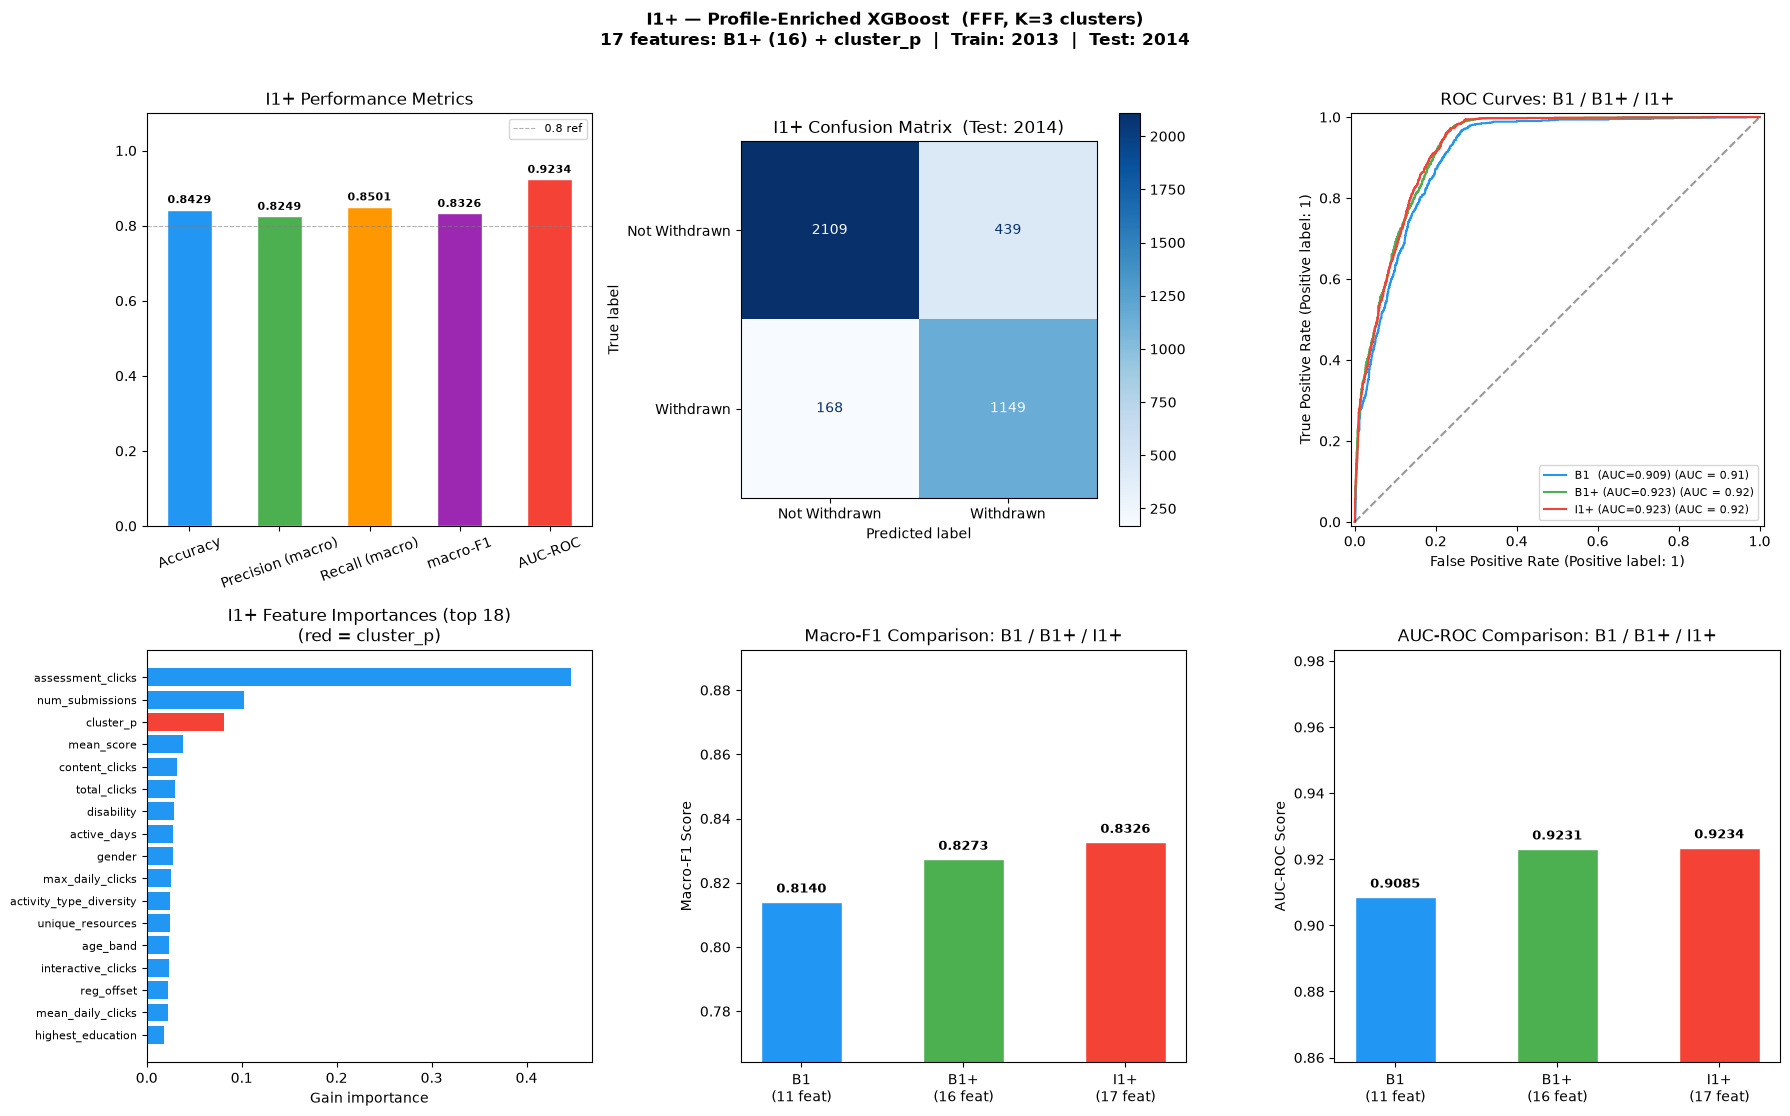


══ I1+ Summary ══
  Macro-F1 :  B1=0.8140  →  B1+=0.8273  →  I1+=0.8326  (Δ I1+−B1: +0.0186  |  Δ I1+−B1+: +0.0053)
  AUC-ROC  :  B1=0.9085  →  B1+=0.9231  →  I1+=0.9234  (Δ I1+−B1: +0.0149  |  Δ I1+−B1+: +0.0004)
  McNemar I1+ vs B1  : p=0.0000  (significant)
  McNemar I1+ vs B1+ : p=0.1425  (not significant)

  cluster_p rank in feature importances: #3 (gain = 0.0813)

Next → I2: Apply SHAP to B1+ and I1+; produce comparative interpretability analysis


In [45]:
# ── I1+: Profile-Enriched XGBoost (B1+ + cluster_p) ─────────────────────────
# Adds the K=3 B2++ cluster label to the 16-feature B1+ matrix and trains
# an XGBoost model with B1-tuned hyperparameters (RandomizedSearchCV).
# Comparison covers:
#   B1  (11 features, no imd_band)
#   B1+ (16 features, extended)
#   I1+ (17 features = B1+ + cluster_p)
# Statistical test: McNemar's exact binomial test on discordant pairs.

from scipy.stats import binomtest
import warnings; warnings.filterwarnings('ignore')

# ── 1. Feature set ─────────────────────────────────────────────────────────
feature_cols_i1p = feature_cols_b1p + ['cluster_p']

print(f"I1+ feature set: {len(feature_cols_i1p)} features "
      f"({len(feature_cols_b1p)} B1+ features + 1 cluster_p)")
print(f"\ncluster_p key  (K={CHOSEN_K_FINAL}):")
for lbl, cnt in df_b1p['cluster_p'].value_counts().sort_index().items():
    name = cluster_names_final.get(lbl, f'C{lbl}')
    wd   = (df_b1p[df_b1p['cluster_p'] == lbl]['label'] == 1).mean()
    print(f"  {lbl}  {name:20s}  N={cnt:5,}  WD={wd:.1%}")

# ── 2. Temporal split (same masks as B1 / B1+) ─────────────────────────────
X_train_i1p = df_b1p.loc[train_mask, feature_cols_i1p].values
y_train_i1p = df_b1p.loc[train_mask, 'label'].values
X_test_i1p  = df_b1p.loc[test_mask,  feature_cols_i1p].values
y_test_i1p  = df_b1p.loc[test_mask,  'label'].values

# Safety: verify test labels match B1's test set
assert len(y_test_i1p) == len(y_test_b1), "Test-set size mismatch vs B1 — check index alignment"
assert np.array_equal(y_test_i1p, y_test_b1), "Test labels mismatch vs B1 — check index alignment"

print(f"\nTrain: {len(y_train_i1p):,}  WD={y_train_i1p.mean():.1%}  |  "
      f"Test: {len(y_test_i1p):,}  WD={y_test_i1p.mean():.1%}")

# ── 3. Train XGBoost (B1-tuned params from RandomizedSearchCV) ──────────────
# Best params: colsample_bytree=0.7713, gamma=4.833, learning_rate=0.2894,
#              max_depth=3, min_child_weight=4, n_estimators=290,
#              reg_alpha=0.3057, reg_lambda=0.9773, subsample=0.7074
pos_weight_i1p = float((y_train_i1p == 0).sum()) / float((y_train_i1p == 1).sum())
model_i1p = XGBClassifier(
    n_estimators=290,
    max_depth=3,
    learning_rate=0.28944979335588333,
    subsample=0.7073899427560627,
    colsample_bytree=0.7712736593269257,
    gamma=4.833274095218348,
    reg_alpha=0.30569701928718185,
    reg_lambda=0.9772775778758651,
    min_child_weight=4,
    scale_pos_weight=pos_weight_i1p,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_i1p.fit(X_train_i1p, y_train_i1p)

y_pred_i1p  = model_i1p.predict(X_test_i1p)
y_proba_i1p = model_i1p.predict_proba(X_test_i1p)[:, 1]

# ── 4. Metrics ───────────────────────────────────────────────────────────────
acc_i1p  = accuracy_score(y_test_i1p,  y_pred_i1p)
prec_i1p = precision_score(y_test_i1p, y_pred_i1p, average='macro')
rec_i1p  = recall_score(y_test_i1p,    y_pred_i1p, average='macro')
f1_i1p   = f1_score(y_test_i1p,        y_pred_i1p, average='macro')
auc_i1p  = roc_auc_score(y_test_i1p,   y_proba_i1p)

print("\n── I1+ Performance Metrics ──")
metrics_i1p = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'Score':  [acc_i1p, prec_i1p, rec_i1p, f1_i1p, auc_i1p],
})
metrics_i1p['Score'] = metrics_i1p['Score'].round(4)
display(metrics_i1p)

p_i1p, r_i1p, f_i1p, s_i1p = precision_recall_fscore_support(y_test_i1p, y_pred_i1p, labels=[0, 1])
print("\n── Per-Class Report ──")
display(pd.DataFrame({
    'Class':     ['Not Withdrawn (0)', 'Withdrawn (1)'],
    'Precision': p_i1p.round(4),
    'Recall':    r_i1p.round(4),
    'F1-Score':  f_i1p.round(4),
    'Support':   s_i1p,
}))

# ── 5. Comparison table: B1 / B1+ / I1+ ──────────────────────────────────────
print("\n── Comparison: B1 (11 feat) vs B1+ (16 feat) vs I1+ (17 feat) ──")
cmp_i1p = pd.DataFrame({
    'Metric':          ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 (11 feat)':   [acc_ni,   prec_ni,   rec_ni,   f1_ni,   auc_ni],
    'B1+ (16 feat)':  [acc_b1p,  prec_b1p,  rec_b1p,  f1_b1p,  auc_b1p],
    'I1+ (17 feat)':  [acc_i1p,  prec_i1p,  rec_i1p,  f1_i1p,  auc_i1p],
})
cmp_i1p['Δ I1+−B1']  = (cmp_i1p['I1+ (17 feat)'] - cmp_i1p['B1 (11 feat)'] ).map(lambda x: f"{x:+.4f}")
cmp_i1p['Δ I1+−B1+'] = (cmp_i1p['I1+ (17 feat)'] - cmp_i1p['B1+ (16 feat)']).map(lambda x: f"{x:+.4f}")
for col in ['B1 (11 feat)', 'B1+ (16 feat)', 'I1+ (17 feat)']:
    cmp_i1p[col] = cmp_i1p[col].map('{:.4f}'.format)
display(cmp_i1p)

# ── 6. McNemar's test (exact binomial on discordant pairs) ───────────────────
def _mcnemar_exact(pred_ref, pred_new, truth, name_ref, name_new):
    correct_ref = (pred_ref == truth)
    correct_new = (pred_new == truth)
    b = int(np.sum( correct_ref & ~correct_new))   # ref right, new wrong
    c = int(np.sum(~correct_ref &  correct_new))   # ref wrong, new right
    n_disc = b + c
    p_val = binomtest(min(b, c), n_disc, p=0.5,
                      alternative='two-sided').pvalue if n_disc > 0 else 1.0
    return {'Comparison': f'{name_new} vs {name_ref}',
            f'{name_ref} right / {name_new} wrong': b,
            f'{name_ref} wrong / {name_new} right': c,
            'Discordant pairs': n_disc,
            'p-value (exact)': round(p_val, 4),
            'p < 0.05': p_val < 0.05}

r_b1   = _mcnemar_exact(y_pred_no_imd, y_pred_i1p, y_test_i1p, 'B1',  'I1+')
r_b1p2 = _mcnemar_exact(y_pred_b1p,    y_pred_i1p, y_test_i1p, 'B1+', 'I1+')

print("\n── McNemar's Test (exact binomial) ──")
display(pd.DataFrame([r_b1, r_b1p2]))

# ── 7. Visualisations ────────────────────────────────────────────────────────
fi_i1p_series = pd.Series(model_i1p.feature_importances_,
                           index=feature_cols_i1p).sort_values()
top_fi = fi_i1p_series.tail(min(18, len(fi_i1p_series)))
fi_bar_colors = ['#F44336' if f == 'cluster_p' else '#2196F3' for f in top_fi.index]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f'I1+ — Profile-Enriched XGBoost  ({TARGET_MODULE}, K={CHOSEN_K_FINAL} clusters)\n'
    f'17 features: B1+ (16) + cluster_p  |  Train: 2013  |  Test: 2014',
    fontsize=12, fontweight='bold', y=1.01)

# (0,0) I1+ metrics bar
colors_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0, 0].bar(metrics_i1p['Metric'], metrics_i1p['Score'].values,
                      color=colors_m, edgecolor='white', width=0.5)
axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].set_title('I1+ Performance Metrics')
axes[0, 0].axhline(0.8, color='grey', linestyle='--', lw=0.8, alpha=0.6, label='0.8 ref')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(fontsize=8)
for b, v in zip(bars, metrics_i1p['Score'].values):
    axes[0, 0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.4f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

# (0,1) Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_i1p, y_pred_i1p,
    display_labels=['Not Withdrawn', 'Withdrawn'],
    cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('I1+ Confusion Matrix  (Test: 2014)')

# (0,2) ROC curves: B1 / B1+ / I1+ overlaid (color set post-call, sklearn 1.9)
_d1 = RocCurveDisplay.from_predictions(y_test_b1, y_proba_no_imd, ax=axes[0, 2], name=f'B1  (AUC={auc_ni:.3f})')
_d1.line_.set_color('#2196F3')
_d2 = RocCurveDisplay.from_predictions(y_test_b1, y_proba_b1p, ax=axes[0, 2], name=f'B1+ (AUC={auc_b1p:.3f})')
_d2.line_.set_color('#4CAF50')
_d3 = RocCurveDisplay.from_predictions(y_test_i1p, y_proba_i1p, ax=axes[0, 2], name=f'I1+ (AUC={auc_i1p:.3f})')
_d3.line_.set_color('#F44336')
axes[0, 2].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0, 2].set_title('ROC Curves: B1 / B1+ / I1+')
axes[0, 2].legend(fontsize=8)

# (1,0) Feature importances (top 18, cluster_p in red)
axes[1, 0].barh(range(len(top_fi)), top_fi.values, color=fi_bar_colors)
axes[1, 0].set_yticks(range(len(top_fi)))
axes[1, 0].set_yticklabels(top_fi.index, fontsize=8)
axes[1, 0].set_title('I1+ Feature Importances (top 18)\n(red = cluster_p)')
axes[1, 0].set_xlabel('Gain importance')

# (1,1) Macro-F1 comparison
f1_vals   = [f1_ni,  f1_b1p,  f1_i1p]
bar_names = ['B1\n(11 feat)', 'B1+\n(16 feat)', 'I1+\n(17 feat)']
bar_clrs  = ['#2196F3', '#4CAF50', '#F44336']
bars_f1 = axes[1, 1].bar(bar_names, f1_vals, color=bar_clrs, edgecolor='white', width=0.5)
lo_f1 = max(0.0, min(f1_vals) - 0.05)
axes[1, 1].set_ylim(lo_f1, min(1.0, max(f1_vals) + 0.06))
axes[1, 1].set_title('Macro-F1 Comparison: B1 / B1+ / I1+')
axes[1, 1].set_ylabel('Macro-F1 Score')
for b, v in zip(bars_f1, f1_vals):
    axes[1, 1].text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.4f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# (1,2) AUC-ROC comparison
auc_vals = [auc_ni, auc_b1p, auc_i1p]
bars_auc = axes[1, 2].bar(bar_names, auc_vals, color=bar_clrs, edgecolor='white', width=0.5)
lo_auc = max(0.0, min(auc_vals) - 0.05)
axes[1, 2].set_ylim(lo_auc, min(1.0, max(auc_vals) + 0.06))
axes[1, 2].set_title('AUC-ROC Comparison: B1 / B1+ / I1+')
axes[1, 2].set_ylabel('AUC-ROC Score')
for b, v in zip(bars_auc, auc_vals):
    axes[1, 2].text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.4f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── 8. Summary printout ──────────────────────────────────────────────────────
print("\n══ I1+ Summary ══")
print(f"  Macro-F1 :  B1={f1_ni:.4f}  →  B1+={f1_b1p:.4f}  →  I1+={f1_i1p:.4f}  "
      f"(Δ I1+−B1: {f1_i1p - f1_ni:+.4f}  |  Δ I1+−B1+: {f1_i1p - f1_b1p:+.4f})")
print(f"  AUC-ROC  :  B1={auc_ni:.4f}  →  B1+={auc_b1p:.4f}  →  I1+={auc_i1p:.4f}  "
      f"(Δ I1+−B1: {auc_i1p - auc_ni:+.4f}  |  Δ I1+−B1+: {auc_i1p - auc_b1p:+.4f})")
print(f"  McNemar I1+ vs B1  : p={r_b1['p-value (exact)']:.4f}  "
      f"({'significant' if r_b1['p < 0.05'] else 'not significant'})")
print(f"  McNemar I1+ vs B1+ : p={r_b1p2['p-value (exact)']:.4f}  "
      f"({'significant' if r_b1p2['p < 0.05'] else 'not significant'})")
cluster_rank = fi_i1p_series.rank(ascending=False, method='first').astype(int)['cluster_p']
print(f"\n  cluster_p rank in feature importances: #{cluster_rank} "
      f"(gain = {fi_i1p_series['cluster_p']:.4f})")
print(f"\nNext → I2: Apply SHAP to B1+ and I1+; produce comparative interpretability analysis")


In [46]:
# ── I1+: Save model artefacts and update model_meta.json ─────────────────────
import joblib, json, os

SAVE_DIR_I1P = os.path.dirname(os.path.abspath('OULAD.ipynb'))
joblib.dump(model_i1p, os.path.join(SAVE_DIR_I1P, 'model_i1p.pkl'))

meta_path_i1p = os.path.join(SAVE_DIR_I1P, 'model_meta.json')
with open(meta_path_i1p) as fh:
    meta_i1p = json.load(fh)

meta_i1p['i1p_feature_cols']   = feature_cols_i1p
meta_i1p['i1p_cluster_k']      = int(CHOSEN_K_FINAL)
meta_i1p['i1p_metrics'] = {
    'accuracy':          round(float(acc_i1p),  4),
    'precision_macro':   round(float(prec_i1p), 4),
    'recall_macro':      round(float(rec_i1p),  4),
    'f1_macro':          round(float(f1_i1p),   4),
    'auc_roc':           round(float(auc_i1p),  4),
}
meta_i1p['b1_baseline_metrics'] = {
    'f1_macro':  round(float(f1_ni),  4),
    'auc_roc':   round(float(auc_ni), 4),
}
meta_i1p['b1plus_metrics'] = {
    'f1_macro':  round(float(f1_b1p),  4),
    'auc_roc':   round(float(auc_b1p), 4),
}

with open(meta_path_i1p, 'w') as fh:
    json.dump(meta_i1p, fh, indent=2)

print(f"Saved artefacts  →  {SAVE_DIR_I1P}")
print(f"  model_i1p.pkl        : I1+ XGBoost ({len(feature_cols_i1p)} features)")
print(f"  model_meta.json      : i1p_feature_cols / i1p_metrics added")
print(f"\n── I1+ model_meta.json update ──")
print(f"  i1p macro-F1  : {meta_i1p['i1p_metrics']['f1_macro']}")
print(f"  i1p AUC-ROC   : {meta_i1p['i1p_metrics']['auc_roc']}")

Saved artefacts  →  d:\Code\CS\code
  model_i1p.pkl        : I1+ XGBoost (17 features)
  model_meta.json      : i1p_feature_cols / i1p_metrics added

── I1+ model_meta.json update ──
  i1p macro-F1  : 0.8326
  i1p AUC-ROC   : 0.9234


### 19-B. I1 — Cluster Label on Minimal Baseline (11 features + cluster_p)

**Goal**: Isolate the pure marginal contribution of `cluster_p` when added to the
*minimal* B1 feature set (11 features, no imd_band) — removing the confound of B1+ extended features.

**Comparison**:
- B1: 11 features (no imd_band), XGBoost defaults
- I1: 11 + `cluster_p` = 12 features, same XGBoost defaults

**Research question**: Does the engagement cluster label improve withdrawal prediction
over the simplest feature baseline, without the benefit of B1+ extended features?

**Four-model overview**: B1 (11) → I1 (12) → B1+ (16) → I1+ (17)

I1 feature set: 12 features  (B1 11 + cluster_p 1)
Train: 3,897  |  Test: 3,865

── B1 (11 feat)  vs  I1 (11 + cluster_p = 12 feat) ──


,Metric,B1 (11 feat),I1 (12 feat),Δ (I1 − B1)
0,Accuracy,0.8225,0.8285,+0.0060
1,Precision (macro),0.8089,0.8167,+0.0078
2,Recall (macro),0.8397,0.8495,+0.0098
3,macro-F1,0.8140,0.8210,+0.0069
4,AUC-ROC,0.9085,0.9161,+0.0076



McNemar's (I1 vs B1):  b=73  c=96  discordant=169  p=0.0903  not significant

── Full 4-model summary ──


,Model,macro-F1,AUC-ROC
0,B1 (11 feat),0.8140,0.9085
1,I1 (12 feat),0.8210,0.9161
2,B1+ (16 feat),0.8273,0.9231
3,I1+ (17 feat),0.8326,0.9234


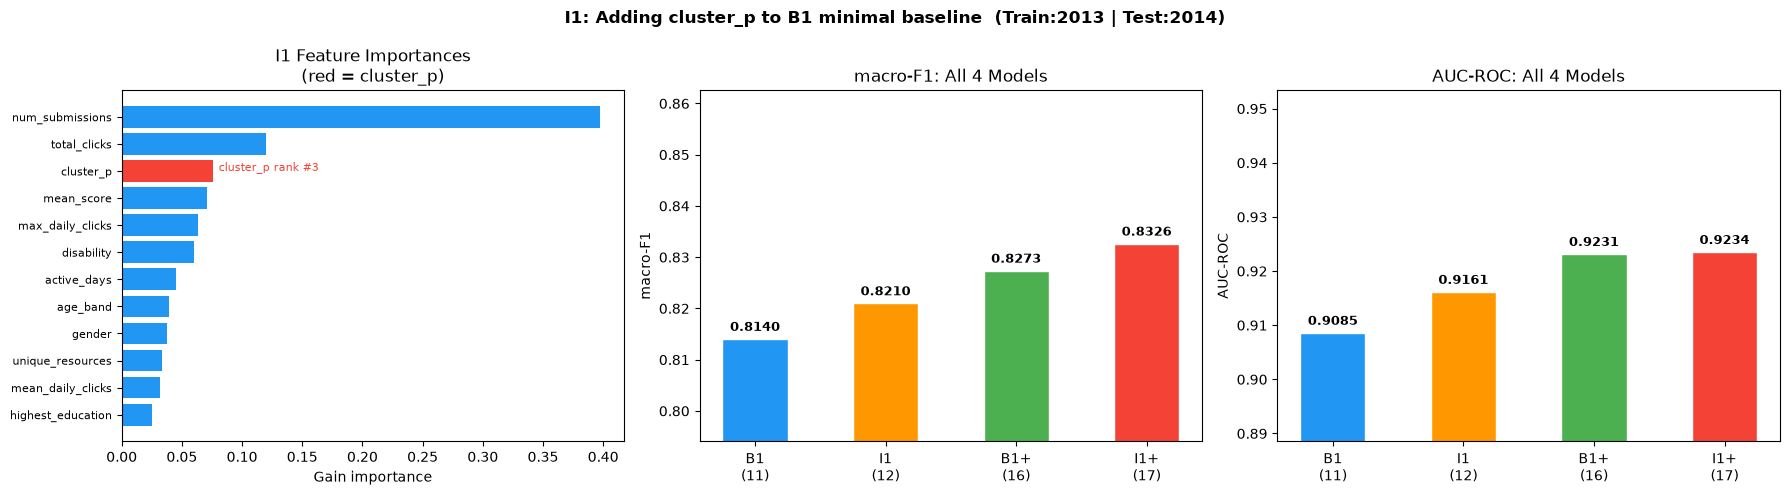


cluster_p rank in I1 importances: #3
I1 vs B1:  Δmacro-F1 = +0.0069  |  ΔAUC = +0.0076


In [47]:
from scipy.stats import binomtest
import warnings; warnings.filterwarnings('ignore')

# ── Build I1 feature matrix: X_train_no_imd + cluster_p ───────────────
# df_b1p shares the same index as df_b1 (built via left merges, same row order).
# train_mask / test_mask are therefore valid for both DataFrames.
cluster_train = df_b1p.loc[train_mask, 'cluster_p'].values.reshape(-1, 1)
cluster_test  = df_b1p.loc[test_mask,  'cluster_p'].values.reshape(-1, 1)

X_train_i1b1 = np.column_stack([X_train_no_imd, cluster_train])
X_test_i1b1  = np.column_stack([X_test_no_imd,  cluster_test])

feature_cols_i1b1 = feature_cols_no_imd + ['cluster_p']

print(f"I1 feature set: {len(feature_cols_i1b1)} features  "
      f"(B1 {len(feature_cols_no_imd)} + cluster_p 1)")
print(f"Train: {X_train_i1b1.shape[0]:,}  |  Test: {X_test_i1b1.shape[0]:,}")

# ── Train XGBoost (B1-tuned params from RandomizedSearchCV) ──────────────────
# Best params: colsample_bytree=0.7713, gamma=4.833, learning_rate=0.2894,
#              max_depth=3, min_child_weight=4, n_estimators=290,
#              reg_alpha=0.3057, reg_lambda=0.9773, subsample=0.7074
pos_weight_i1b1 = float((y_train_b1 == 0).sum()) / float((y_train_b1 == 1).sum())
model_i1b1 = XGBClassifier(
    n_estimators=290,
    max_depth=3,
    learning_rate=0.28944979335588333,
    subsample=0.7073899427560627,
    colsample_bytree=0.7712736593269257,
    gamma=4.833274095218348,
    reg_alpha=0.30569701928718185,
    reg_lambda=0.9772775778758651,
    min_child_weight=4,
    scale_pos_weight=pos_weight_i1b1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model_i1b1.fit(X_train_i1b1, y_train_b1)

y_pred_i1b1  = model_i1b1.predict(X_test_i1b1)
y_proba_i1b1 = model_i1b1.predict_proba(X_test_i1b1)[:, 1]

acc_i1b1  = accuracy_score(y_test_b1,  y_pred_i1b1)
prec_i1b1 = precision_score(y_test_b1, y_pred_i1b1, average='macro')
rec_i1b1  = recall_score(y_test_b1,    y_pred_i1b1, average='macro')
f1_i1b1   = f1_score(y_test_b1,        y_pred_i1b1, average='macro')
auc_i1b1  = roc_auc_score(y_test_b1,   y_proba_i1b1)

# ── McNemar's exact test (I1 vs B1) ──────────────────────────────────────
correct_b1   = (y_pred_no_imd == y_test_b1)
correct_i1b1 = (y_pred_i1b1   == y_test_b1)
b_mc   = int(np.sum( correct_b1 & ~correct_i1b1))
c_mc   = int(np.sum(~correct_b1 &  correct_i1b1))
n_disc = b_mc + c_mc
p_mc   = binomtest(min(b_mc, c_mc), n_disc, p=0.5,
                   alternative='two-sided').pvalue if n_disc > 0 else 1.0

# ── Comparison table ──────────────────────────────────────────────────────
cmp_i1b1 = pd.DataFrame({
    'Metric':         ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'macro-F1', 'AUC-ROC'],
    'B1 (11 feat)':   [acc_ni,    prec_ni,    rec_ni,    f1_ni,    auc_ni],
    'I1 (12 feat)':   [acc_i1b1, prec_i1b1, rec_i1b1, f1_i1b1, auc_i1b1],
})
cmp_i1b1['Δ (I1 − B1)'] = (
    cmp_i1b1['I1 (12 feat)'] - cmp_i1b1['B1 (11 feat)']
).map(lambda x: f"{x:+.4f}")
for col in ['B1 (11 feat)', 'I1 (12 feat)']:
    cmp_i1b1[col] = cmp_i1b1[col].map('{:.4f}'.format)

print("\n── B1 (11 feat)  vs  I1 (11 + cluster_p = 12 feat) ──")
display(cmp_i1b1)
print(f"\nMcNemar's (I1 vs B1):  b={b_mc}  c={c_mc}  "
      f"discordant={n_disc}  p={p_mc:.4f}  "
      f"{'* significant (p<0.05)' if p_mc < 0.05 else 'not significant'}")

# ── Full 4-model comparison ───────────────────────────────────────────────
full_cmp = pd.DataFrame({
    'Model':     ['B1 (11 feat)', 'I1 (12 feat)', 'B1+ (16 feat)', 'I1+ (17 feat)'],
    'macro-F1':  [f1_ni,  f1_i1b1,  f1_b1p,  f1_i1p],
    'AUC-ROC':   [auc_ni, auc_i1b1, auc_b1p, auc_i1p],
})
full_cmp['macro-F1'] = full_cmp['macro-F1'].map('{:.4f}'.format)
full_cmp['AUC-ROC']  = full_cmp['AUC-ROC'].map('{:.4f}'.format)
print("\n── Full 4-model summary ──")
display(full_cmp)

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('I1: Adding cluster_p to B1 minimal baseline  (Train:2013 | Test:2014)',
             fontsize=12, fontweight='bold')

# (0) Feature importance
fi_i1b1_s = pd.Series(model_i1b1.feature_importances_,
                       index=feature_cols_i1b1).sort_values()
fi_clrs = ['#F44336' if f == 'cluster_p' else '#2196F3' for f in fi_i1b1_s.index]
axes[0].barh(range(len(fi_i1b1_s)), fi_i1b1_s.values, color=fi_clrs)
axes[0].set_yticks(range(len(fi_i1b1_s)))
axes[0].set_yticklabels(fi_i1b1_s.index, fontsize=8)
axes[0].set_title('I1 Feature Importances\n(red = cluster_p)')
axes[0].set_xlabel('Gain importance')
cluster_rank_b1 = int(fi_i1b1_s.rank(ascending=False, method='first').astype(int)['cluster_p'])
axes[0].annotate(f'cluster_p rank #{cluster_rank_b1}',
                 xy=(fi_i1b1_s['cluster_p'], fi_i1b1_s.index.get_loc('cluster_p')),
                 xytext=(fi_i1b1_s['cluster_p'] + 0.005, fi_i1b1_s.index.get_loc('cluster_p')),
                 fontsize=8, color='#F44336')

# (1) macro-F1 bar: all 4 models
models_4  = ['B1\n(11)', 'I1\n(12)', 'B1+\n(16)', 'I1+\n(17)']
f1_4      = [f1_ni, f1_i1b1, f1_b1p, f1_i1p]
clrs_4    = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
bars_4    = axes[1].bar(models_4, f1_4, color=clrs_4, edgecolor='white', width=0.5)
lo_f1_4   = max(0, min(f1_4) - 0.02)
axes[1].set_ylim(lo_f1_4, min(1.0, max(f1_4) + 0.03))
axes[1].set_title('macro-F1: All 4 Models')
axes[1].set_ylabel('macro-F1')
for b, v in zip(bars_4, f1_4):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.001, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# (2) AUC-ROC bar: all 4 models
auc_4   = [auc_ni, auc_i1b1, auc_b1p, auc_i1p]
bars_a4 = axes[2].bar(models_4, auc_4, color=clrs_4, edgecolor='white', width=0.5)
lo_auc_4 = max(0, min(auc_4) - 0.02)
axes[2].set_ylim(lo_auc_4, min(1.0, max(auc_4) + 0.03))
axes[2].set_title('AUC-ROC: All 4 Models')
axes[2].set_ylabel('AUC-ROC')
for b, v in zip(bars_a4, auc_4):
    axes[2].text(b.get_x() + b.get_width()/2, v + 0.001, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\ncluster_p rank in I1 importances: #{cluster_rank_b1}")
print(f"I1 vs B1:  Δmacro-F1 = {f1_i1b1 - f1_ni:+.4f}  |  ΔAUC = {auc_i1b1 - auc_ni:+.4f}")


## 20. I2 — SHAP Interpretability

In [48]:
# ── I2-A  SHAP Computation for All Four Models ───────────────────────────────
import shap
import warnings; warnings.filterwarnings('ignore')

# ── 1. TreeExplainer for each model ──────────────────────────────────────────
# Pair A: B1 (11 feat, no imd_band)  vs  I1 (12 feat = B1 + cluster_p)
# Pair B: B1+ (16 feat, extended)    vs  I1+ (17 feat = B1+ + cluster_p)

print("Computing SHAP — B1  (11 feat) ...", end=" ", flush=True)
explainer_b1   = shap.TreeExplainer(model_no_imd)
shap_vals_b1   = explainer_b1.shap_values(X_test_no_imd)
if isinstance(shap_vals_b1,  list): shap_vals_b1  = shap_vals_b1[1]
print("done")

print("Computing SHAP — I1  (12 feat) ...", end=" ", flush=True)
explainer_i1   = shap.TreeExplainer(model_i1b1)
shap_vals_i1   = explainer_i1.shap_values(X_test_i1b1)
if isinstance(shap_vals_i1,  list): shap_vals_i1  = shap_vals_i1[1]
print("done")

print("Computing SHAP — B1+ (16 feat) ...", end=" ", flush=True)
explainer_b1p  = shap.TreeExplainer(model_b1p)
shap_vals_b1p  = explainer_b1p.shap_values(X_test_b1p)
if isinstance(shap_vals_b1p, list): shap_vals_b1p = shap_vals_b1p[1]
print("done")

print("Computing SHAP — I1+ (17 feat) ...", end=" ", flush=True)
explainer_i1p  = shap.TreeExplainer(model_i1p)
shap_vals_i1p  = explainer_i1p.shap_values(X_test_i1p)
if isinstance(shap_vals_i1p, list): shap_vals_i1p = shap_vals_i1p[1]
print("done")

# Base values (log-odds scale)
def _base_val(exp):
    ev = exp.expected_value
    return float(ev[1] if hasattr(ev, '__len__') else ev)

ev_b1  = _base_val(explainer_b1)
ev_i1  = _base_val(explainer_i1)
ev_b1p = _base_val(explainer_b1p)
ev_i1p = _base_val(explainer_i1p)

# ── 2. Mean |SHAP| ranking helper ────────────────────────────────────────────
def _shap_rank_df(shap_matrix, feat_cols):
    s = pd.Series(np.abs(shap_matrix).mean(axis=0), index=feat_cols)
    df = s.sort_values(ascending=False).reset_index()
    df.columns = ['Feature', 'Mean |SHAP|']
    df.insert(0, 'Rank', range(1, len(df) + 1))
    df['Mean |SHAP|'] = df['Mean |SHAP|'].round(5)
    return df

df_s_b1  = _shap_rank_df(shap_vals_b1,  feature_cols_no_imd)
df_s_i1  = _shap_rank_df(shap_vals_i1,  feature_cols_i1b1)
df_s_b1p = _shap_rank_df(shap_vals_b1p, feature_cols_b1p)
df_s_i1p = _shap_rank_df(shap_vals_i1p, feature_cols_i1p)

# ── 3. Print ranking tables ───────────────────────────────────────────────────
for label, df_s in [('B1  (11 feat)', df_s_b1),  ('I1  (12 feat)', df_s_i1),
                    ('B1+ (16 feat)', df_s_b1p), ('I1+ (17 feat)', df_s_i1p)]:
    print(f"\n── {label} — Mean |SHAP| Ranking ──")
    display(df_s)

# ── 4. cluster_p cross-pair summary ──────────────────────────────────────────
def _cp_stats(df_s, shap_matrix, n_feat):
    row = df_s[df_s['Feature'] == 'cluster_p']
    if row.empty:
        return None, None, None
    rank = int(row['Rank'].values[0])
    val  = float(row['Mean |SHAP|'].values[0])
    pct  = val / np.abs(shap_matrix).mean(axis=0).sum() * 100
    return rank, val, pct

r_i1,  v_i1,  p_i1  = _cp_stats(df_s_i1,  shap_vals_i1,  len(feature_cols_i1b1))
r_i1p, v_i1p, p_i1p = _cp_stats(df_s_i1p, shap_vals_i1p, len(feature_cols_i1p))

print("\n── cluster_p SHAP Importance: I1 vs I1+ ──")
display(pd.DataFrame({
    'Model':             ['I1  (12 feat, Pair A)', 'I1+ (17 feat, Pair B)'],
    'cluster_p Rank':    [f'#{r_i1}/{len(feature_cols_i1b1)}',
                          f'#{r_i1p}/{len(feature_cols_i1p)}'],
    'Mean |SHAP|':       [round(v_i1,  5), round(v_i1p, 5)],
    '% of total SHAP':   [f'{p_i1:.1f}%', f'{p_i1p:.1f}%'],
    'macro-F1 (model)':  [round(f1_i1b1, 4), round(f1_i1p, 4)],
    'Baseline macro-F1': [round(f1_ni, 4),    round(f1_b1p, 4)],
    'Δ macro-F1':        [f'{f1_i1b1 - f1_ni:+.4f}', f'{f1_i1p - f1_b1p:+.4f}'],
}))

# ── 5. Shared-feature rank-shift table (Pair A) ──────────────────────────────
shared_a = set(feature_cols_no_imd) & set(feature_cols_i1b1) - {'cluster_p'}
rows_shift_a = []
for feat in sorted(shared_a):
    r_base = int(df_s_b1[df_s_b1['Feature'] == feat]['Rank'].values[0])
    r_new  = int(df_s_i1[df_s_i1['Feature'] == feat]['Rank'].values[0])
    v_base = float(df_s_b1[df_s_b1['Feature'] == feat]['Mean |SHAP|'].values[0])
    v_new  = float(df_s_i1[df_s_i1['Feature'] == feat]['Mean |SHAP|'].values[0])
    rows_shift_a.append({'Feature': feat,
                         'B1 Rank': r_base, 'I1 Rank': r_new,
                         'Rank Δ': r_new - r_base,
                         'B1 |SHAP|': v_base, 'I1 |SHAP|': v_new,
                         '|SHAP| Δ': round(v_new - v_base, 5)})
shift_a = pd.DataFrame(rows_shift_a).sort_values('|SHAP| Δ')
print("\n── Pair A: Shared-Feature Rank & SHAP Shift (B1 → I1) ──")
display(shift_a)

# ── 6. Shared-feature rank-shift table (Pair B) ──────────────────────────────
shared_b = set(feature_cols_b1p) & set(feature_cols_i1p) - {'cluster_p'}
rows_shift_b = []
for feat in sorted(shared_b):
    r_base = int(df_s_b1p[df_s_b1p['Feature'] == feat]['Rank'].values[0])
    r_new  = int(df_s_i1p[df_s_i1p['Feature'] == feat]['Rank'].values[0])
    v_base = float(df_s_b1p[df_s_b1p['Feature'] == feat]['Mean |SHAP|'].values[0])
    v_new  = float(df_s_i1p[df_s_i1p['Feature'] == feat]['Mean |SHAP|'].values[0])
    rows_shift_b.append({'Feature': feat,
                         'B1+ Rank': r_base, 'I1+ Rank': r_new,
                         'Rank Δ': r_new - r_base,
                         'B1+ |SHAP|': v_base, 'I1+ |SHAP|': v_new,
                         '|SHAP| Δ': round(v_new - v_base, 5)})
shift_b = pd.DataFrame(rows_shift_b).sort_values('|SHAP| Δ')
print("\n── Pair B: Shared-Feature Rank & SHAP Shift (B1+ → I1+) ──")
display(shift_b)

Computing SHAP — B1  (11 feat) ... done
Computing SHAP — I1  (12 feat) ... done
Computing SHAP — B1+ (16 feat) ... done
Computing SHAP — I1+ (17 feat) ... done

── B1  (11 feat) — Mean |SHAP| Ranking ──


,Rank,Feature,Mean |SHAP|
0,1,num_submissions,2.09330
1,2,mean_score,0.44078
2,3,active_days,0.36843
3,4,total_clicks,0.30789
4,5,max_daily_clicks,0.23420
5,6,unique_resources,0.22603
6,7,mean_daily_clicks,0.18802
7,8,disability,0.15426
8,9,highest_education,0.07390
9,10,age_band,0.06530



── I1  (12 feat) — Mean |SHAP| Ranking ──


,Rank,Feature,Mean |SHAP|
0,1,num_submissions,2.10433
1,2,cluster_p,0.65348
2,3,mean_score,0.37649
3,4,unique_resources,0.33362
4,5,active_days,0.31602
5,6,max_daily_clicks,0.24113
6,7,total_clicks,0.24042
7,8,mean_daily_clicks,0.17875
8,9,disability,0.16209
9,10,age_band,0.08874



── B1+ (16 feat) — Mean |SHAP| Ranking ──


...

,Model,cluster_p Rank,Mean |SHAP|,% of total SHAP,macro-F1 (model),Baseline macro-F1,Δ macro-F1
0,"I1 (12 feat, Pair A)",#2/12,0.65348,13.6%,0.8210,0.8140,+0.0069
1,"I1+ (17 feat, Pair B)",#10/17,0.21101,2.9%,0.8326,0.8273,+0.0053



── Pair A: Shared-Feature Rank & SHAP Shift (B1 → I1) ──


,Feature,B1 Rank,I1 Rank,Rank Δ,B1 |SHAP|,I1 |SHAP|,|SHAP| Δ
9,total_clicks,4,7,3,0.30789,0.24042,-0.06747
7,mean_score,2,3,1,0.44078,0.37649,-0.06429
0,active_days,3,5,2,0.36843,0.31602,-0.05241
4,highest_education,9,12,3,0.07390,0.02624,-0.04766
6,mean_daily_clicks,7,8,1,0.18802,0.17875,-0.00927
5,max_daily_clicks,5,6,1,0.23420,0.24113,0.00693
2,disability,8,9,1,0.15426,0.16209,0.00783
8,num_submissions,1,1,0,2.09330,2.10433,0.01103
1,age_band,10,10,0,0.06530,0.08874,0.02344
3,gender,11,11,0,0.05573,0.08439,0.02866



── Pair B: Shared-Feature Rank & SHAP Shift (B1+ → I1+) ──


,Feature,B1+ Rank,I1+ Rank,Rank Δ,B1+ |SHAP|,I1+ |SHAP|,|SHAP| Δ
14,total_clicks,4,4,0,0.65166,0.58142,-0.07024
4,content_clicks,2,3,1,1.08989,1.02478,-0.06511
15,unique_resources,5,6,1,0.37093,0.33598,-0.03495
0,active_days,10,11,1,0.22382,0.19360,-0.03022
13,reg_offset,7,8,1,0.27378,0.24915,-0.02463
2,age_band,16,17,1,0.04394,0.02646,-0.01748
10,mean_daily_clicks,9,9,0,0.23176,0.22040,-0.01136
5,disability,12,13,1,0.13678,0.13250,-0.00428
3,assessment_clicks,1,1,0,2.23147,2.23033,-0.00114
7,highest_education,15,16,1,0.06033,0.06917,0.00884


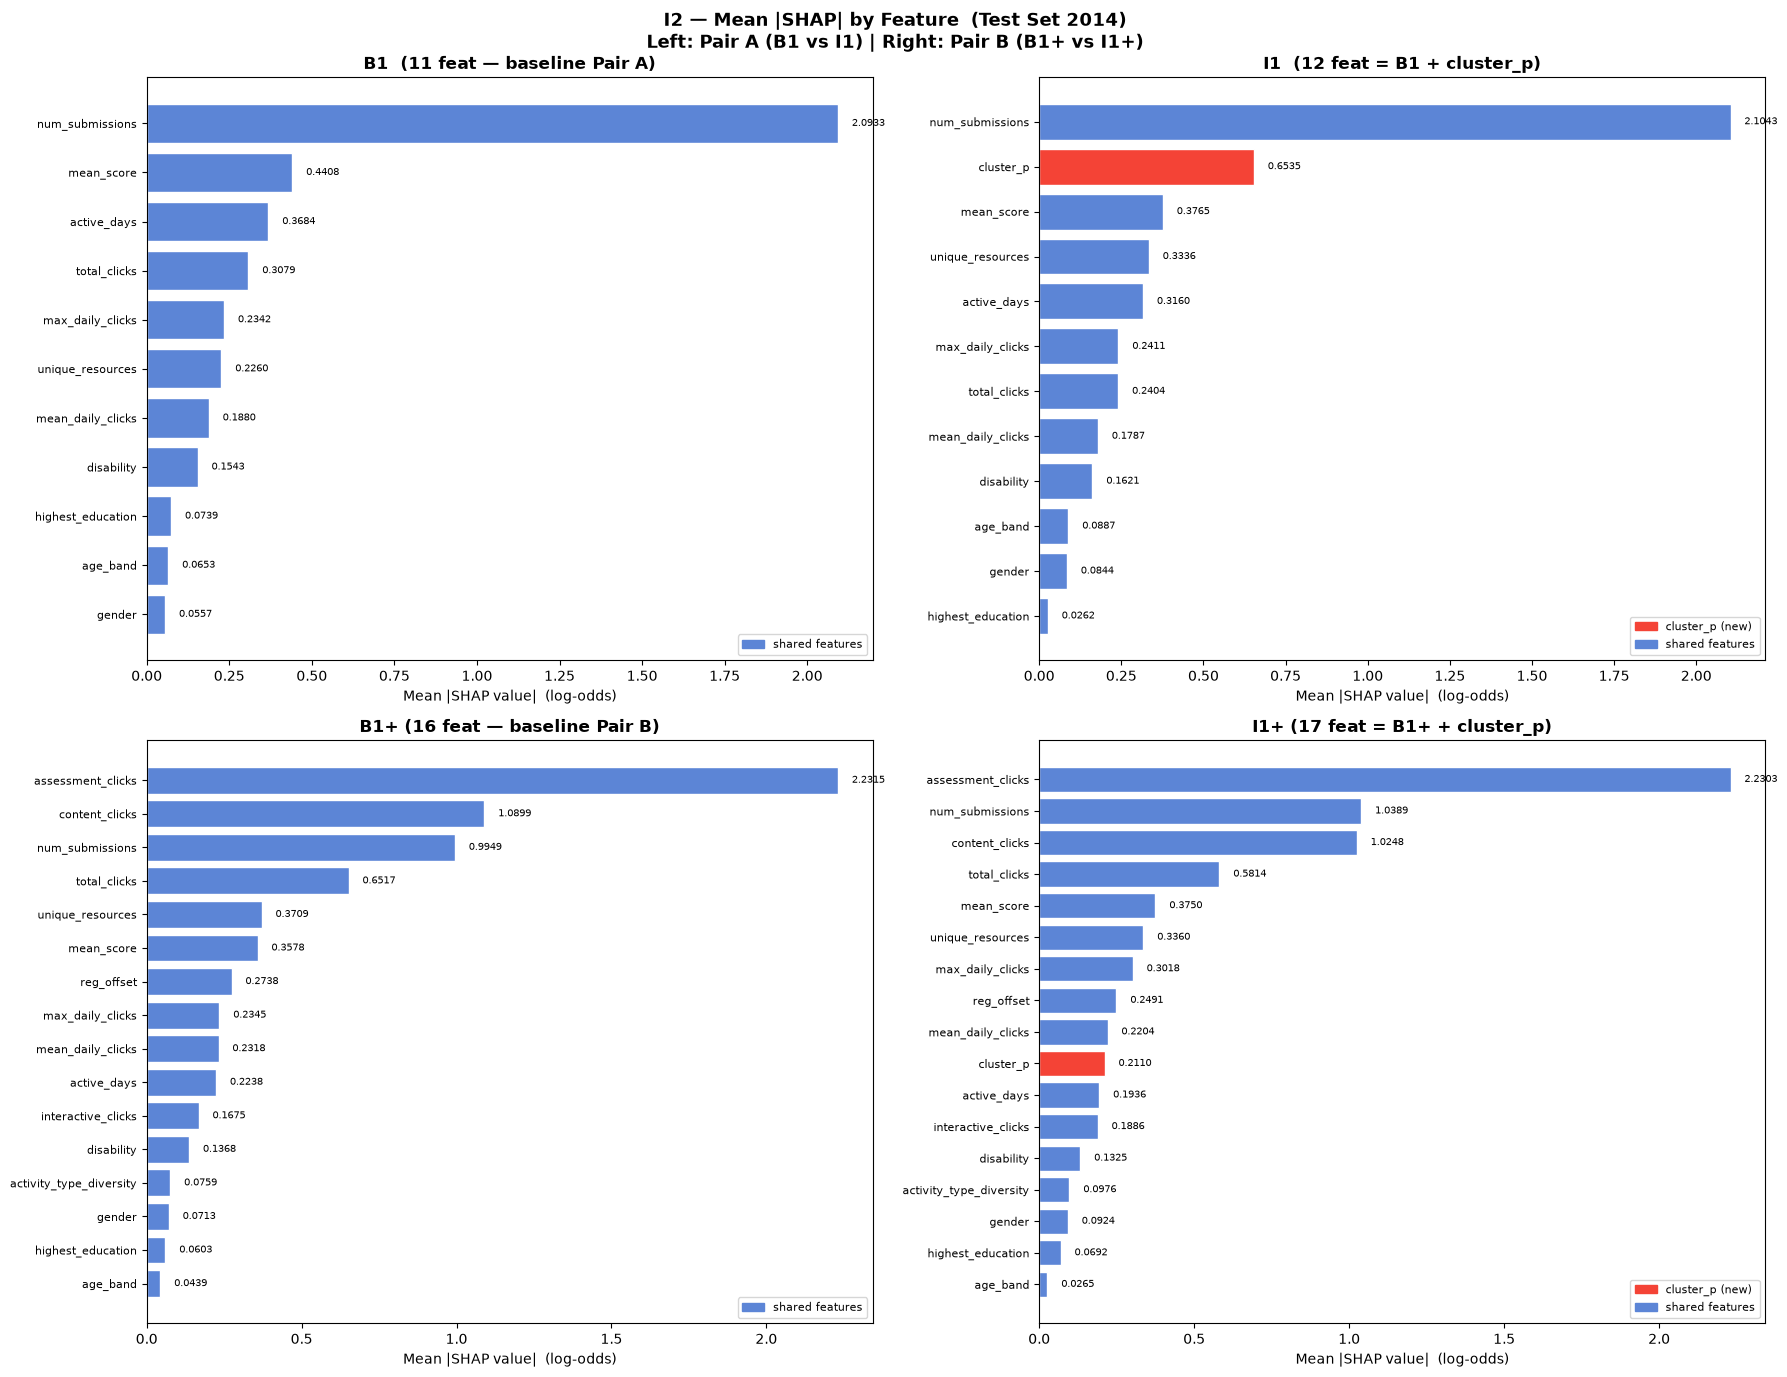

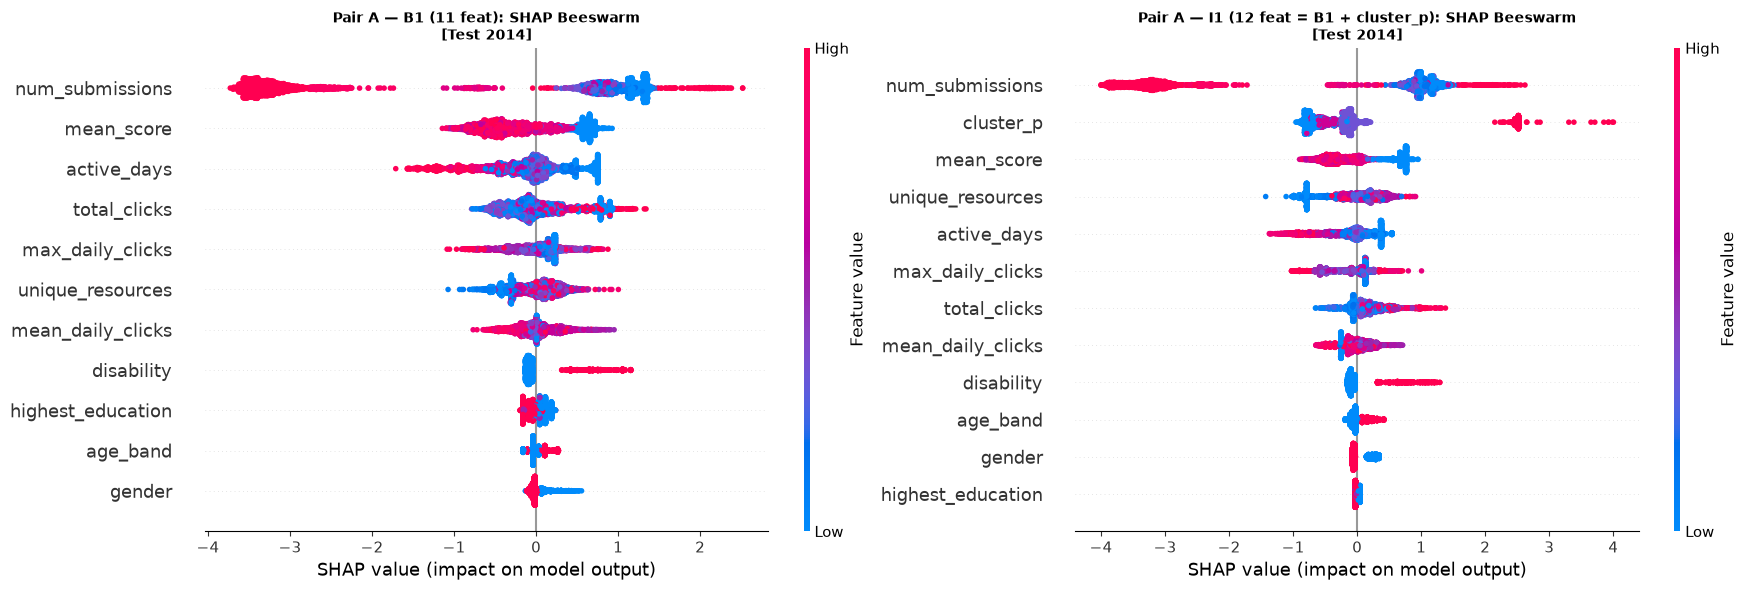

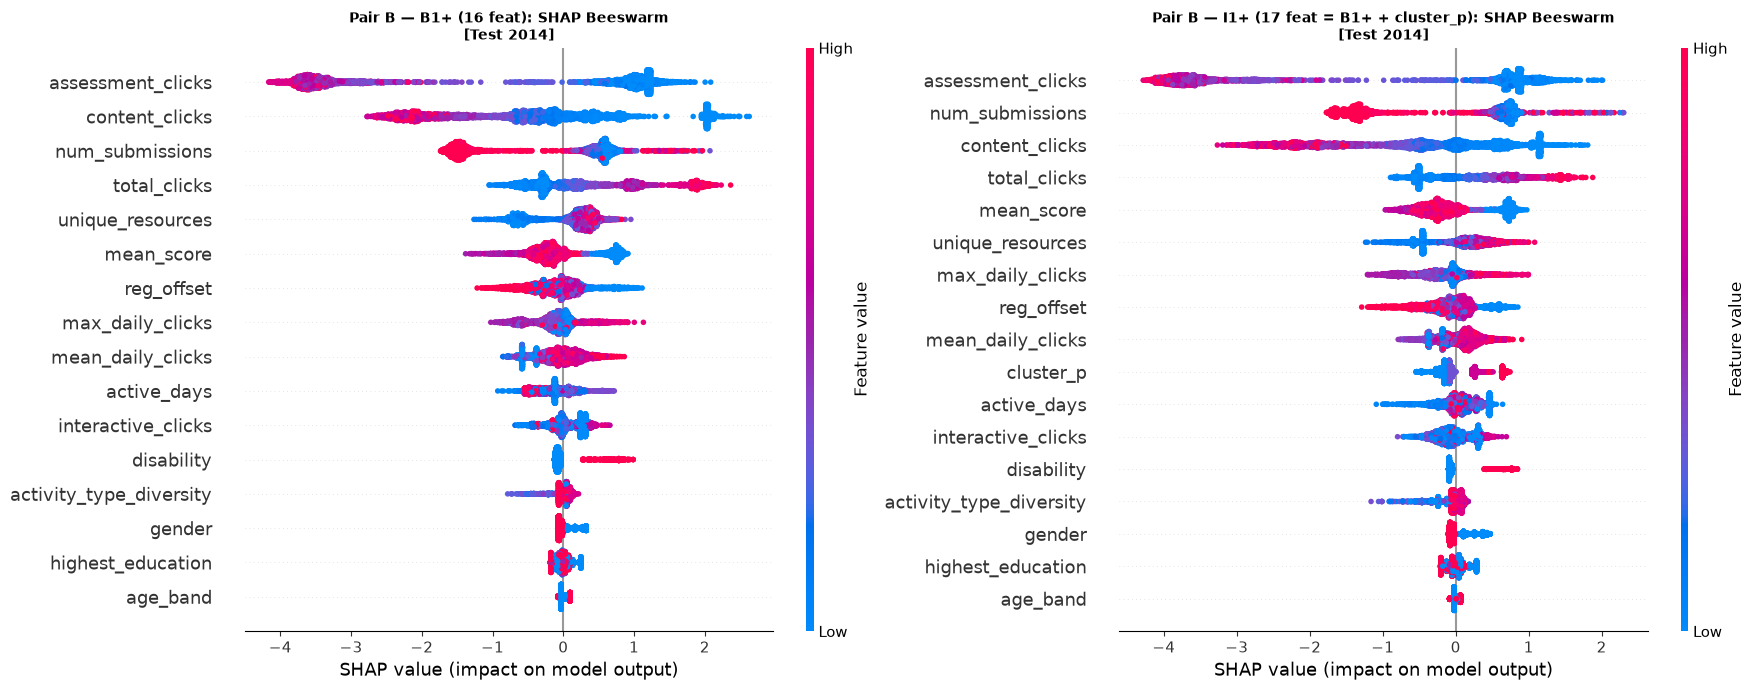

── I2-B Summary ──
  B1  (11)  macro-F1=0.8140  AUC=0.9085  top-3: [num_submissions, mean_score, active_days]  no cluster_p
  I1  (12)  macro-F1=0.8210  AUC=0.9161  top-3: [num_submissions, cluster_p, mean_score]  cluster_p rank #2/12
  B1+ (16)  macro-F1=0.8273  AUC=0.9231  top-3: [assessment_clicks, content_clicks, num_submissions]  no cluster_p
  I1+ (17)  macro-F1=0.8326  AUC=0.9234  top-3: [assessment_clicks, num_submissions, content_clicks]  cluster_p rank #10/17


In [49]:
# ── I2-B  SHAP Summary Visualisations: Pair A (B1 vs I1) + Pair B (B1+ vs I1+) ─
from matplotlib.patches import Patch

# ── 1. Mean |SHAP| bar charts: 2 rows × 2 cols ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('I2 — Mean |SHAP| by Feature  (Test Set 2014)\n'
             'Left: Pair A (B1 vs I1) | Right: Pair B (B1+ vs I1+)',
             fontsize=13, fontweight='bold')

combos = [
    (axes[0, 0], df_s_b1,  feature_cols_no_imd, 'B1  (11 feat — baseline Pair A)', False),
    (axes[0, 1], df_s_i1,  feature_cols_i1b1,   'I1  (12 feat = B1 + cluster_p)',  True),
    (axes[1, 0], df_s_b1p, feature_cols_b1p,    'B1+ (16 feat — baseline Pair B)', False),
    (axes[1, 1], df_s_i1p, feature_cols_i1p,    'I1+ (17 feat = B1+ + cluster_p)', True),
]
for ax, df_s, _, title, has_cp in combos:
    df_plot = df_s.iloc[::-1].reset_index(drop=True)
    colors  = ['#F44336' if f == 'cluster_p' else '#5C85D6' for f in df_plot['Feature']]
    ax.barh(range(len(df_plot)), df_plot['Mean |SHAP|'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot['Feature'], fontsize=8)
    ax.set_xlabel('Mean |SHAP value|  (log-odds)')
    ax.set_title(title, fontweight='bold')
    xlim_max = df_plot['Mean |SHAP|'].max()
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['Mean |SHAP|'] + xlim_max * 0.02, i,
                f'{row["Mean |SHAP|"]:.4f}', va='center', fontsize=7)
    legend_handles = [Patch(color='#5C85D6', label='shared features')]
    if has_cp:
        legend_handles.insert(0, Patch(color='#F44336', label='cluster_p (new)'))
    ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

# ── 2. Beeswarm — Pair A ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_vals_b1, X_test_no_imd,
                  feature_names=feature_cols_no_imd,
                  max_display=12, show=False, plot_size=None)
axes[0].set_title('Pair A — B1 (11 feat): SHAP Beeswarm\n[Test 2014]',
                  fontsize=10, fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_vals_i1, X_test_i1b1,
                  feature_names=feature_cols_i1b1,
                  max_display=12, show=False, plot_size=None)
axes[1].set_title('Pair A — I1 (12 feat = B1 + cluster_p): SHAP Beeswarm\n[Test 2014]',
                  fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Beeswarm — Pair B ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.sca(axes[0])
shap.summary_plot(shap_vals_b1p, X_test_b1p,
                  feature_names=feature_cols_b1p,
                  max_display=16, show=False, plot_size=None)
axes[0].set_title('Pair B — B1+ (16 feat): SHAP Beeswarm\n[Test 2014]',
                  fontsize=10, fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_vals_i1p, X_test_i1p,
                  feature_names=feature_cols_i1p,
                  max_display=17, show=False, plot_size=None)
axes[1].set_title('Pair B — I1+ (17 feat = B1+ + cluster_p): SHAP Beeswarm\n[Test 2014]',
                  fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Summary: top-3 features per model + cluster_p rank ────────────────────
print("── I2-B Summary ──")
for label, df_s, model_f1, model_auc, n_feat in [
    ('B1  (11)', df_s_b1,  f1_ni,    auc_ni,    len(feature_cols_no_imd)),
    ('I1  (12)', df_s_i1,  f1_i1b1,  auc_i1b1,  len(feature_cols_i1b1)),
    ('B1+ (16)', df_s_b1p, f1_b1p,   auc_b1p,   len(feature_cols_b1p)),
    ('I1+ (17)', df_s_i1p, f1_i1p,   auc_i1p,   len(feature_cols_i1p)),
]:
    top3 = ', '.join(df_s.head(3)['Feature'].tolist())
    cp_row = df_s[df_s['Feature'] == 'cluster_p']
    cp_str = (f"cluster_p rank #{int(cp_row['Rank'].values[0])}/{n_feat}"
              if not cp_row.empty else 'no cluster_p')
    print(f"  {label}  macro-F1={model_f1:.4f}  AUC={model_auc:.4f}  "
          f"top-3: [{top3}]  {cp_str}")

── cluster_p SHAP by Cluster  (I1 Pair A vs I1+ Pair B) ──


,Cluster,Archetype,N (test),WD Rate,Mean SHAP — I1 (Pair A),Mean SHAP — I1+ (Pair B),Median SHAP — I1,Median SHAP — I1+
0,0,Moderate,1585,7.3%,-0.6874,-0.2050,-0.7539,-0.1572
1,1,Disengaged,1305,63.7%,-0.1221,-0.0709,-0.1168,-0.0757
2,2,High Engaged,594,1.3%,-0.4982,0.2571,-0.5325,0.2614
3,3,No VLE Record,381,95.0%,2.5249,0.6440,2.5179,0.6393


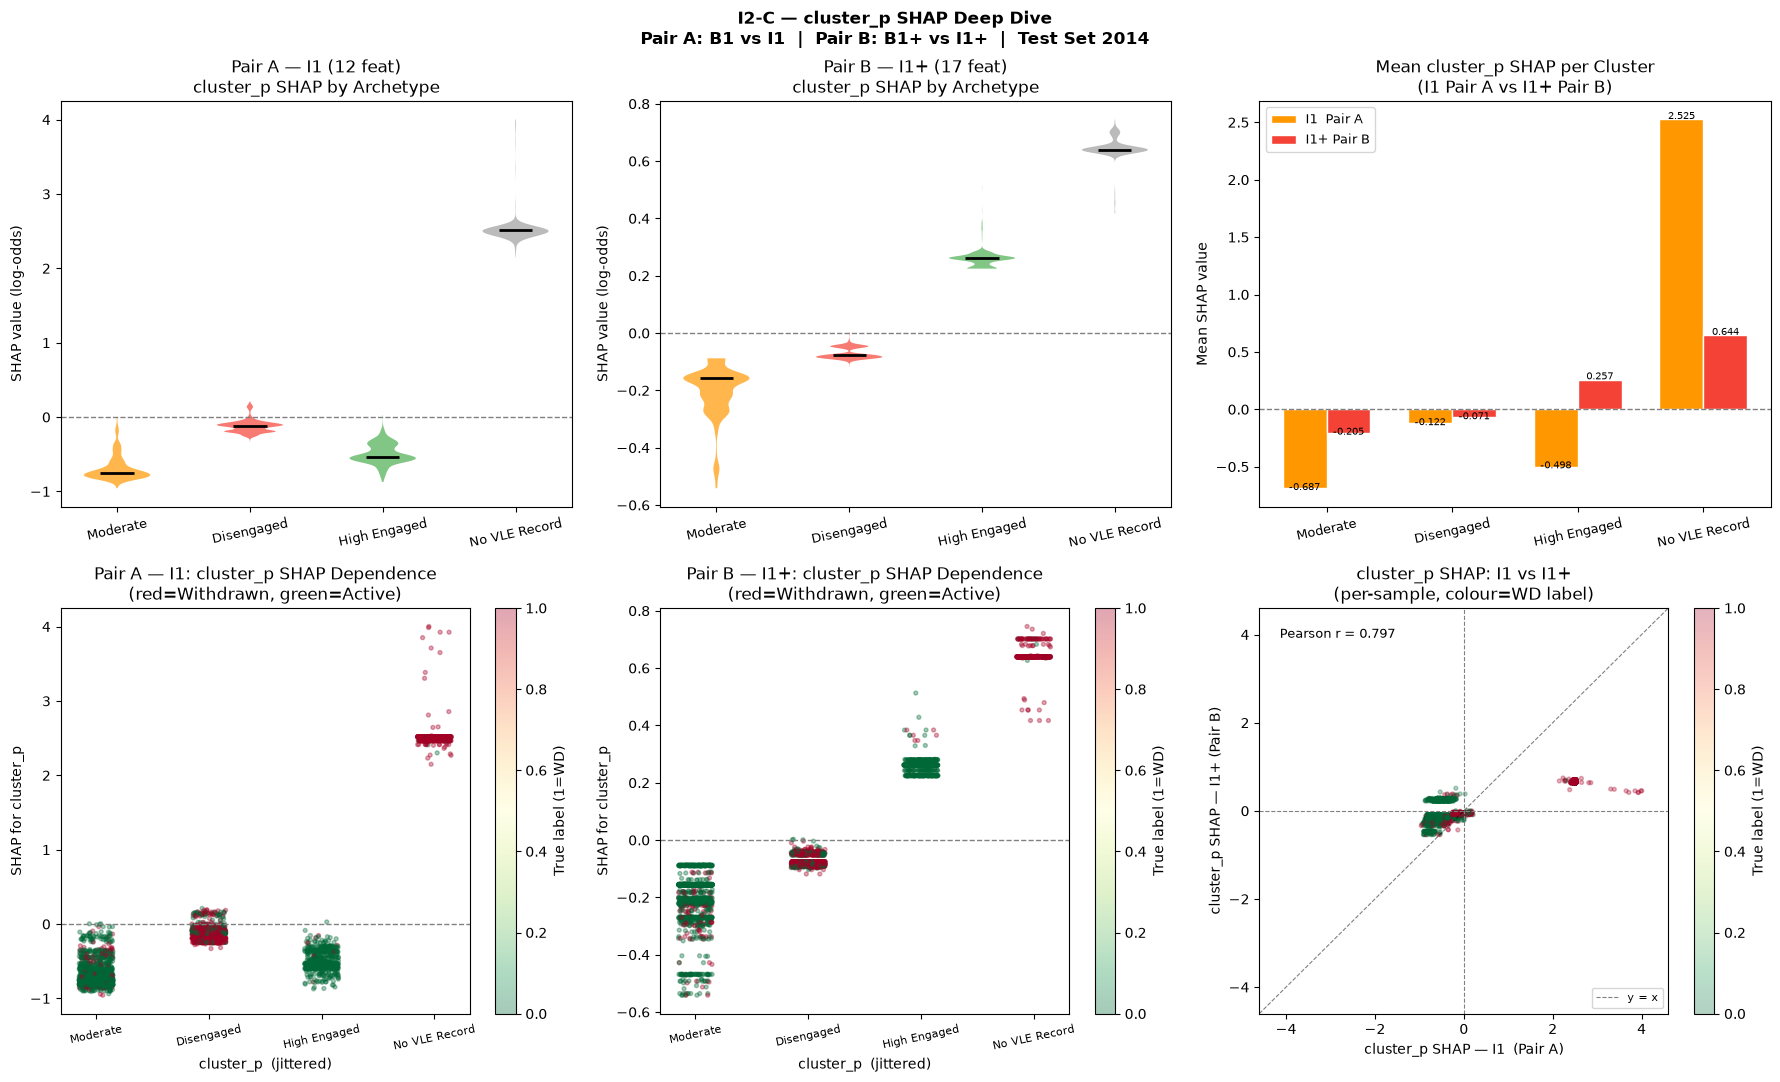


── I1 Waterfall (Pair A — primary): Highest-risk Withdrawn  (test #1933) ──
  P(WD) = 0.995  |  cluster_p = 3  (No VLE Record)


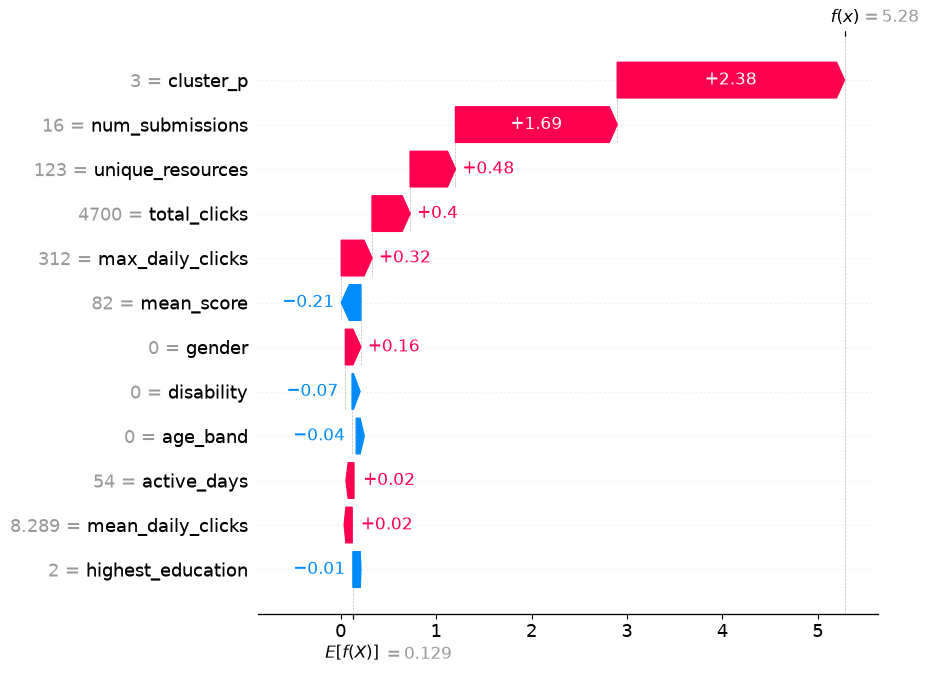


══ I2 Comparative Interpretability Summary ══

  Pair A — B1 (11) → I1 (12):  Δmacro-F1 = +0.0069  ΔAUC = +0.0076
    cluster_p rank #2/12  Mean|SHAP|=0.65348  (13.6% of total)

  Pair B — B1+ (16) → I1+ (17): Δmacro-F1 = +0.0053  ΔAUC = +0.0004
    cluster_p rank #10/17  Mean|SHAP|=0.21101  (2.9% of total)

  cluster_p SHAP consistency (I1 vs I1+): Pearson r = 0.797

  Per-cluster interpretation (I1 / Pair A — primary model):
    Moderate          (WD=7.3% )  Mean SHAP = -0.6874  → ↓ lowers WD risk
    Disengaged        (WD=63.7%)  Mean SHAP = -0.1221  → ↓ lowers WD risk
    High Engaged      (WD=1.3% )  Mean SHAP = -0.4982  → ↓ lowers WD risk
    No VLE Record     (WD=95.0%)  Mean SHAP = +2.5249  → ↑ raises WD risk


In [50]:
# ── I2-C  cluster_p SHAP Deep Dive ───────────────────────────────────────────
# Compares cluster_p's SHAP effect in I1 (Pair A) vs I1+ (Pair B)

_cp_names = {0: 'Moderate', 1: 'Disengaged', 2: 'High Engaged', 3: 'No VLE'}
try:
    _cp_names = {int(k): v for k, v in cluster_names_final.items()}
except Exception:
    pass

cp_idx_i1  = list(feature_cols_i1b1).index('cluster_p')
cp_idx_i1p = list(feature_cols_i1p).index('cluster_p')

# cluster_p test values (same assignment for both models — same test rows)
cp_test         = X_test_i1b1[:, cp_idx_i1].astype(int)
unique_clusters = sorted(np.unique(cp_test))
cluster_labels  = [_cp_names.get(k, f'C{k}') for k in unique_clusters]

shap_cp_i1_all  = shap_vals_i1[:,  cp_idx_i1]
shap_cp_i1p_all = shap_vals_i1p[:, cp_idx_i1p]

# ── 1. Per-cluster SHAP statistics ───────────────────────────────────────────
rows = []
for k, name in zip(unique_clusters, cluster_labels):
    mask = cp_test == k
    n    = int(mask.sum())
    if n == 0:
        continue
    rows.append({
        'Cluster':          k,
        'Archetype':        name,
        'N (test)':         n,
        'WD Rate':          f"{y_test_b1[mask].mean():.1%}",
        'Mean SHAP — I1  (Pair A)':  round(shap_cp_i1_all[mask].mean(),     4),
        'Mean SHAP — I1+ (Pair B)':  round(shap_cp_i1p_all[mask].mean(),    4),
        'Median SHAP — I1':          round(np.median(shap_cp_i1_all[mask]),  4),
        'Median SHAP — I1+':         round(np.median(shap_cp_i1p_all[mask]), 4),
    })
tbl_cp = pd.DataFrame(rows)
print("── cluster_p SHAP by Cluster  (I1 Pair A vs I1+ Pair B) ──")
display(tbl_cp)

# ── 2. 2×3 visualisation ─────────────────────────────────────────────────────
palette_clust = {0: '#FF9800', 1: '#F44336', 2: '#4CAF50', 3: '#9E9E9E'}
vp_colors     = [palette_clust.get(k, '#607D8B') for k in unique_clusters]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('I2-C — cluster_p SHAP Deep Dive\n'
             'Pair A: B1 vs I1  |  Pair B: B1+ vs I1+  |  Test Set 2014',
             fontsize=12, fontweight='bold')

# (0,0) Violin — I1 (Pair A)
vp1 = axes[0, 0].violinplot(
    [shap_cp_i1_all[cp_test == k] for k in unique_clusters],
    positions=range(len(unique_clusters)), showmedians=True, showextrema=False)
for body, color in zip(vp1['bodies'], vp_colors):
    body.set_facecolor(color); body.set_alpha(0.7)
vp1['cmedians'].set_color('black'); vp1['cmedians'].set_linewidth(2)
axes[0, 0].set_xticks(range(len(unique_clusters)))
axes[0, 0].set_xticklabels(cluster_labels, rotation=12, fontsize=9)
axes[0, 0].axhline(0, color='grey', linestyle='--', lw=1)
axes[0, 0].set_ylabel('SHAP value (log-odds)')
axes[0, 0].set_title('Pair A — I1 (12 feat)\ncluster_p SHAP by Archetype')

# (0,1) Violin — I1+ (Pair B)
vp2 = axes[0, 1].violinplot(
    [shap_cp_i1p_all[cp_test == k] for k in unique_clusters],
    positions=range(len(unique_clusters)), showmedians=True, showextrema=False)
for body, color in zip(vp2['bodies'], vp_colors):
    body.set_facecolor(color); body.set_alpha(0.7)
vp2['cmedians'].set_color('black'); vp2['cmedians'].set_linewidth(2)
axes[0, 1].set_xticks(range(len(unique_clusters)))
axes[0, 1].set_xticklabels(cluster_labels, rotation=12, fontsize=9)
axes[0, 1].axhline(0, color='grey', linestyle='--', lw=1)
axes[0, 1].set_ylabel('SHAP value (log-odds)')
axes[0, 1].set_title('Pair B — I1+ (17 feat)\ncluster_p SHAP by Archetype')

# (0,2) Mean SHAP per cluster — I1 vs I1+
x_c = np.arange(len(tbl_cp))
w   = 0.35
b_i1  = axes[0, 2].bar(x_c - w/2, tbl_cp['Mean SHAP — I1  (Pair A)'].values, w,
                        label='I1  Pair A', color='#FF9800', edgecolor='white')
b_i1p = axes[0, 2].bar(x_c + w/2, tbl_cp['Mean SHAP — I1+ (Pair B)'].values, w,
                        label='I1+ Pair B', color='#F44336', edgecolor='white')
axes[0, 2].axhline(0, color='grey', linestyle='--', lw=1)
axes[0, 2].set_xticks(x_c)
axes[0, 2].set_xticklabels(tbl_cp['Archetype'], rotation=12, fontsize=9)
axes[0, 2].set_title('Mean cluster_p SHAP per Cluster\n(I1 Pair A vs I1+ Pair B)')
axes[0, 2].set_ylabel('Mean SHAP value')
axes[0, 2].legend(fontsize=9)
for bar_group, col in [(b_i1, 'Mean SHAP — I1  (Pair A)'),
                       (b_i1p, 'Mean SHAP — I1+ (Pair B)')]:
    for b, v in zip(bar_group, tbl_cp[col].values):
        off = 0.004 if v >= 0 else -0.016
        axes[0, 2].text(b.get_x() + b.get_width()/2, v + off,
                        f'{v:.3f}', ha='center', fontsize=7)

# (1,0) Dependence scatter — I1
rng    = np.random.default_rng(42)
jitter = rng.uniform(-0.15, 0.15, len(cp_test))
sc1 = axes[1, 0].scatter(cp_test + jitter, shap_cp_i1_all,
                          c=y_test_b1, cmap='RdYlGn_r', alpha=0.35, s=8)
axes[1, 0].axhline(0, color='grey', linestyle='--', lw=1)
axes[1, 0].set_xticks(unique_clusters)
axes[1, 0].set_xticklabels(cluster_labels, rotation=12, fontsize=8)
axes[1, 0].set_xlabel('cluster_p  (jittered)')
axes[1, 0].set_ylabel('SHAP for cluster_p')
axes[1, 0].set_title('Pair A — I1: cluster_p SHAP Dependence\n(red=Withdrawn, green=Active)')
plt.colorbar(sc1, ax=axes[1, 0], label='True label (1=WD)')

# (1,1) Dependence scatter — I1+
sc2 = axes[1, 1].scatter(cp_test + jitter, shap_cp_i1p_all,
                          c=y_test_b1, cmap='RdYlGn_r', alpha=0.35, s=8)
axes[1, 1].axhline(0, color='grey', linestyle='--', lw=1)
axes[1, 1].set_xticks(unique_clusters)
axes[1, 1].set_xticklabels(cluster_labels, rotation=12, fontsize=8)
axes[1, 1].set_xlabel('cluster_p  (jittered)')
axes[1, 1].set_ylabel('SHAP for cluster_p')
axes[1, 1].set_title('Pair B — I1+: cluster_p SHAP Dependence\n(red=Withdrawn, green=Active)')
plt.colorbar(sc2, ax=axes[1, 1], label='True label (1=WD)')

# (1,2) Per-sample scatter: I1 cluster_p SHAP vs I1+ cluster_p SHAP
sc3 = axes[1, 2].scatter(shap_cp_i1_all, shap_cp_i1p_all,
                          c=y_test_b1, cmap='RdYlGn_r', alpha=0.3, s=8)
_lim = max(np.abs(shap_cp_i1_all).max(), np.abs(shap_cp_i1p_all).max()) * 1.15
axes[1, 2].set_xlim(-_lim, _lim); axes[1, 2].set_ylim(-_lim, _lim)
axes[1, 2].axhline(0, color='grey', linestyle='--', lw=0.8)
axes[1, 2].axvline(0, color='grey', linestyle='--', lw=0.8)
axes[1, 2].plot([-_lim, _lim], [-_lim, _lim], 'k--', lw=0.8, alpha=0.5, label='y = x')
axes[1, 2].set_xlabel('cluster_p SHAP — I1  (Pair A)')
axes[1, 2].set_ylabel('cluster_p SHAP — I1+ (Pair B)')
axes[1, 2].set_title('cluster_p SHAP: I1 vs I1+\n(per-sample, colour=WD label)')
corr_cp = np.corrcoef(shap_cp_i1_all, shap_cp_i1p_all)[0, 1]
axes[1, 2].text(0.05, 0.95, f'Pearson r = {corr_cp:.3f}',
                transform=axes[1, 2].transAxes, fontsize=9, va='top')
axes[1, 2].legend(fontsize=8)
plt.colorbar(sc3, ax=axes[1, 2], label='True label (1=WD)')

plt.tight_layout()
plt.show()

# ── 3. Waterfall — highest-risk Withdrawn student in I1 (primary model) ─────
wd_idx = np.where(y_test_b1 == 1)[0]
top_wd = wd_idx[np.argmax(y_proba_i1b1[wd_idx])]

print(f"\n── I1 Waterfall (Pair A — primary): Highest-risk Withdrawn  (test #{top_wd}) ──")
print(f"  P(WD) = {y_proba_i1b1[top_wd]:.3f}  |  "
      f"cluster_p = {int(X_test_i1b1[top_wd, cp_idx_i1])}  "
      f"({_cp_names.get(int(X_test_i1b1[top_wd, cp_idx_i1]), '?')})")
shap.plots.waterfall(shap.Explanation(
    values        = shap_vals_i1[top_wd],
    base_values   = ev_i1,
    data          = X_test_i1b1[top_wd],
    feature_names = feature_cols_i1b1,
), max_display=12, show=True)

# ── 4. Overall I2 Summary ────────────────────────────────────────────────────
print("\n══ I2 Comparative Interpretability Summary ══")
print(f"\n  Pair A — B1 (11) → I1 (12):  Δmacro-F1 = {f1_i1b1 - f1_ni:+.4f}  "
      f"ΔAUC = {auc_i1b1 - auc_ni:+.4f}")
print(f"    cluster_p rank #{r_i1}/{len(feature_cols_i1b1)}  "
      f"Mean|SHAP|={v_i1:.5f}  ({p_i1:.1f}% of total)")
print(f"\n  Pair B — B1+ (16) → I1+ (17): Δmacro-F1 = {f1_i1p - f1_b1p:+.4f}  "
      f"ΔAUC = {auc_i1p - auc_b1p:+.4f}")
print(f"    cluster_p rank #{r_i1p}/{len(feature_cols_i1p)}  "
      f"Mean|SHAP|={v_i1p:.5f}  ({p_i1p:.1f}% of total)")
print(f"\n  cluster_p SHAP consistency (I1 vs I1+): Pearson r = {corr_cp:.3f}")
print(f"\n  Per-cluster interpretation (I1 / Pair A — primary model):")
for _, row in tbl_cp.iterrows():
    v = row['Mean SHAP — I1  (Pair A)']
    direction = '↑ raises WD risk' if v > 0 else '↓ lowers WD risk'
    print(f"    {row['Archetype']:16s}  (WD={row['WD Rate']:5s})  "
          f"Mean SHAP = {v:+.4f}  → {direction}")


── Per-cluster SHAP ranking (I1 / 12 feat — primary model) ──

Cluster 0 — Moderate  (N=1585, WD=7.3%)


,Rank,Feature,Mean |SHAP|
0,1,num_submissions,2.72801
1,2,cluster_p,0.68738
2,3,max_daily_clicks,0.32314
3,4,active_days,0.27498
4,5,mean_score,0.26316
5,6,unique_resources,0.26009
6,7,total_clicks,0.23930
7,8,mean_daily_clicks,0.19449


Cluster 1 — Disengaged  (N=1305, WD=63.7%)


,Rank,Feature,Mean |SHAP|
0,1,num_submissions,1.04027
1,2,mean_score,0.43681
2,3,unique_resources,0.35628
3,4,total_clicks,0.19258
4,5,active_days,0.18369
5,6,disability,0.14016
6,7,cluster_p,0.13655
7,8,mean_daily_clicks,0.13426


Cluster 2 — High Engaged  (N=594, WD=1.3%)


,Rank,Feature,Mean |SHAP|
0,1,num_submissions,3.47285
1,2,active_days,0.69940
2,3,cluster_p,0.49831
3,4,total_clicks,0.44426
4,5,max_daily_clicks,0.33429
5,6,mean_score,0.32560
6,7,unique_resources,0.21408
7,8,disability,0.19941


Cluster 3 — No VLE Record  (N=381, WD=95.0%)


,Rank,Feature,Mean |SHAP|
0,1,cluster_p,2.52495
1,2,num_submissions,1.02078
2,3,unique_resources,0.74830
3,4,mean_score,0.72068
4,5,active_days,0.34230
5,6,mean_daily_clicks,0.23828
6,7,max_daily_clicks,0.12515
7,8,gender,0.10808


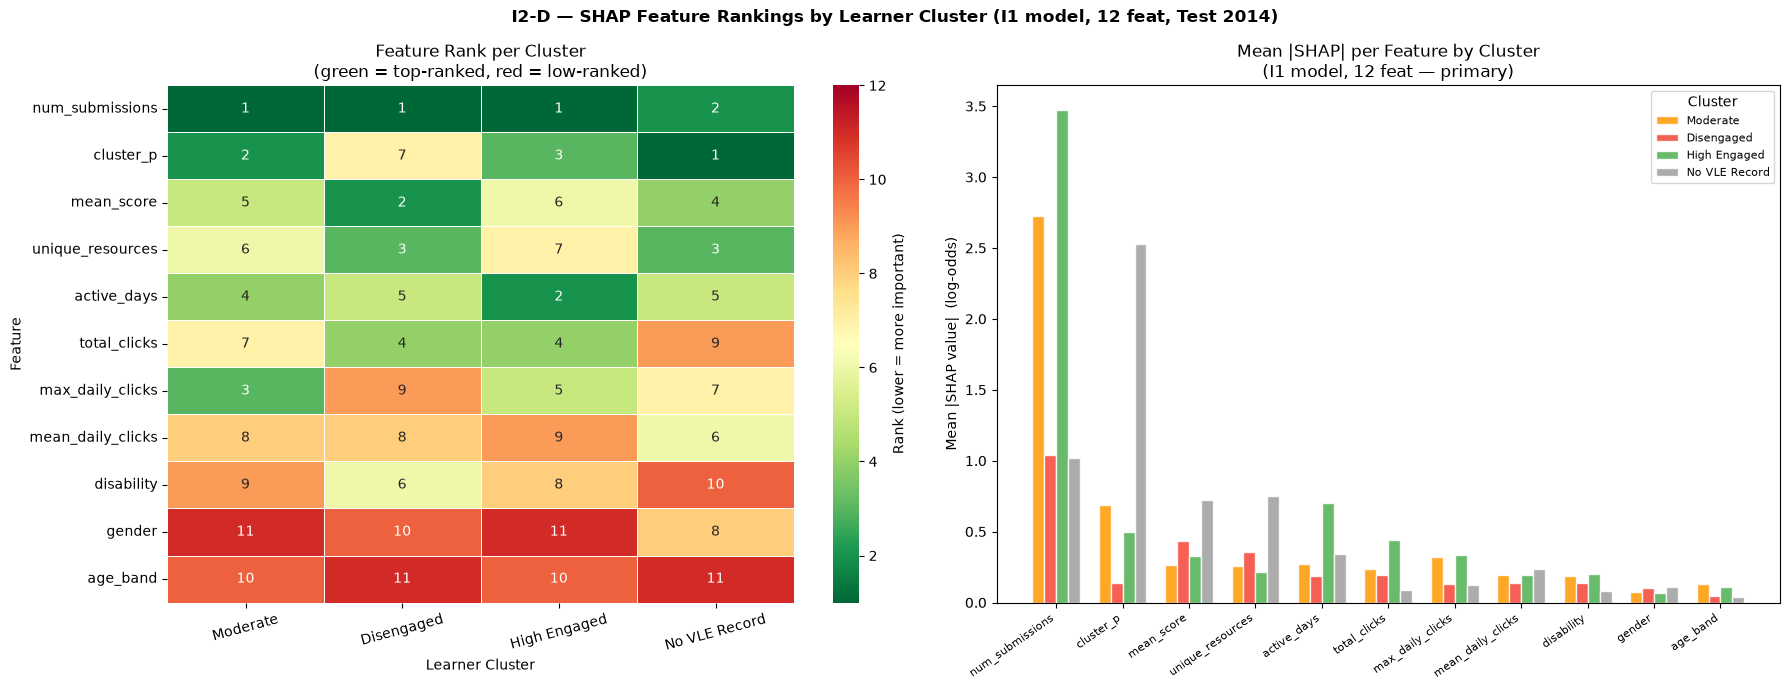


── Kendall τ rank correlation between clusters (I1 — primary) ──
(τ ≈ 1 = same ranking order, τ ≈ 0 = no agreement)



,Cluster A,Cluster B,Kendall τ,p-value,Agreement
0,Moderate,Disengaged,0.600,0.0099,Strong
1,Moderate,High Engaged,0.818,0.0001,Strong
2,Moderate,No VLE Record,0.600,0.0099,Strong
3,Disengaged,High Engaged,0.636,0.0057,Strong
4,Disengaged,No VLE Record,0.709,0.0016,Strong
5,High Engaged,No VLE Record,0.491,0.0405,Moderate



══ Q3 Answer — Systematic SHAP Differences Across Clusters ══

  [Moderate        ]  WD=7.3%  Top-3 drivers: num_submissions, cluster_p, max_daily_clicks
  [Disengaged      ]  WD=63.7%  Top-3 drivers: num_submissions, mean_score, unique_resources
  [High Engaged    ]  WD=1.3%  Top-3 drivers: num_submissions, active_days, cluster_p
  [No VLE Record   ]  WD=95.0%  Top-3 drivers: cluster_p, num_submissions, unique_resources


In [51]:
# ── I2-D  Per-Cluster SHAP Feature Ranking (I1 model — primary) ─────────────
# Answers Q3: do SHAP rankings differ systematically across learner clusters?
# Uses I1 (12 feat, Pair A) as the primary model — cluster_p has no feature
# overlap with the remaining 11 features, so SHAP attribution is clean.

TOP_N = 8   # top features to display per cluster

# ── 1. Per-cluster Mean |SHAP| tables ────────────────────────────────────────
cluster_shap_dfs = {}
print("── Per-cluster SHAP ranking (I1 / 12 feat — primary model) ──\n")
for k in unique_clusters:
    mask   = cp_test == k
    n_k    = int(mask.sum())
    name_k = _cp_names.get(k, f'C{k}')
    if n_k == 0:
        continue
    s_k = pd.Series(
        np.abs(shap_vals_i1[mask]).mean(axis=0),
        index=feature_cols_i1b1
    ).sort_values(ascending=False)
    df_k = s_k.reset_index()
    df_k.columns = ['Feature', 'Mean |SHAP|']
    df_k.insert(0, 'Rank', range(1, len(df_k) + 1))
    df_k['Mean |SHAP|'] = df_k['Mean |SHAP|'].round(5)
    cluster_shap_dfs[k] = df_k
    wd_rate = y_test_b1[mask].mean()
    print(f"Cluster {k} — {name_k}  (N={n_k}, WD={wd_rate:.1%})")
    display(df_k.head(TOP_N))

# ── 2. Cross-cluster rank heatmap ────────────────────────────────────────────
# Build a feature × cluster rank matrix (top 10 features from any cluster)
top_feats_union = set()
for df_k in cluster_shap_dfs.values():
    top_feats_union.update(df_k.head(10)['Feature'].tolist())
top_feats_union = sorted(top_feats_union)

rank_matrix = pd.DataFrame(index=top_feats_union, columns=[
    _cp_names.get(k, f'C{k}') for k in unique_clusters
])
shap_matrix = pd.DataFrame(index=top_feats_union, columns=[
    _cp_names.get(k, f'C{k}') for k in unique_clusters
])
for k in unique_clusters:
    name_k = _cp_names.get(k, f'C{k}')
    df_k = cluster_shap_dfs[k]
    for feat in top_feats_union:
        row = df_k[df_k['Feature'] == feat]
        rank_matrix.loc[feat, name_k] = int(row['Rank'].values[0]) if not row.empty else len(feature_cols_i1b1) + 1
        shap_matrix.loc[feat, name_k] = float(row['Mean |SHAP|'].values[0]) if not row.empty else 0.0

rank_matrix = rank_matrix.astype(float)
shap_matrix = shap_matrix.astype(float)

# Sort by mean SHAP across clusters (descending)
shap_matrix['_avg'] = shap_matrix.mean(axis=1)
shap_matrix = shap_matrix.sort_values('_avg', ascending=False)
shap_matrix.drop(columns='_avg', inplace=True)
rank_matrix = rank_matrix.loc[shap_matrix.index]

import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('I2-D — SHAP Feature Rankings by Learner Cluster (I1 model, 12 feat, Test 2014)',
             fontsize=12, fontweight='bold')

# (Left) Rank heatmap — lower rank = more important = darker
sns.heatmap(rank_matrix, ax=axes[0], annot=True, fmt='.0f',
            cmap='RdYlGn_r', linewidths=0.4,
            cbar_kws={'label': 'Rank (lower = more important)'},
            vmin=1, vmax=len(feature_cols_i1b1))
axes[0].set_title('Feature Rank per Cluster\n(green = top-ranked, red = low-ranked)')
axes[0].set_xlabel('Learner Cluster')
axes[0].set_ylabel('Feature')
axes[0].tick_params(axis='x', rotation=15)
axes[0].tick_params(axis='y', rotation=0)

# (Right) Mean |SHAP| grouped bar chart
n_feats  = len(shap_matrix)
n_clust  = len(unique_clusters)
x_pos    = np.arange(n_feats)
w        = 0.18
offsets  = np.linspace(-(n_clust-1)/2*w, (n_clust-1)/2*w, n_clust)
bar_palette = ['#FF9800', '#F44336', '#4CAF50', '#9E9E9E']

for idx, (k, off) in enumerate(zip(unique_clusters, offsets)):
    name_k = _cp_names.get(k, f'C{k}')
    vals   = shap_matrix[name_k].values
    axes[1].bar(x_pos + off, vals, w,
                label=name_k, color=bar_palette[idx % len(bar_palette)],
                edgecolor='white', alpha=0.85)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(shap_matrix.index, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Mean |SHAP value|  (log-odds)')
axes[1].set_title('Mean |SHAP| per Feature by Cluster\n(I1 model, 12 feat — primary)')
axes[1].legend(title='Cluster', fontsize=8)

plt.tight_layout()
plt.show()

# ── 3. Systematic difference test — Kendall rank correlation ─────────────────
from scipy.stats import kendalltau

print("\n── Kendall τ rank correlation between clusters (I1 — primary) ──")
print("(τ ≈ 1 = same ranking order, τ ≈ 0 = no agreement)\n")

cluster_rank_vecs = {}
for k in unique_clusters:
    name_k = _cp_names.get(k, f'C{k}')
    full_rank = cluster_shap_dfs[k].set_index('Feature')['Rank']
    cluster_rank_vecs[name_k] = full_rank

names_list = list(cluster_rank_vecs.keys())
tau_rows = []
for i in range(len(names_list)):
    for j in range(i+1, len(names_list)):
        a, b_vec = names_list[i], names_list[j]
        common   = [f for f in feature_cols_i1b1 if f != 'cluster_p']
        ra = cluster_rank_vecs[a][common].values
        rb = cluster_rank_vecs[b_vec][common].values
        tau_val, p_val = kendalltau(ra, rb)
        tau_rows.append({'Cluster A': a, 'Cluster B': b_vec,
                         'Kendall τ': round(tau_val, 3),
                         'p-value':   f'{p_val:.4f}',
                         'Agreement': 'Strong' if tau_val > 0.6 else
                                      'Moderate' if tau_val > 0.3 else 'Weak'})

display(pd.DataFrame(tau_rows))

# ── 4. Q3 narrative summary ───────────────────────────────────────────────────
print("\n══ Q3 Answer — Systematic SHAP Differences Across Clusters ══\n")
for k in unique_clusters:
    name_k = _cp_names.get(k, f'C{k}')
    df_k   = cluster_shap_dfs[k]
    top3   = ', '.join(df_k.head(3)['Feature'].tolist())
    wd_rate = y_test_b1[cp_test == k].mean()
    print(f"  [{name_k:16s}]  WD={wd_rate:.1%}  Top-3 drivers: {top3}")


### I2-E  Individual Student Risk Narrative (SHAP-grounded Natural Language Explanation)

**One-sentence summary:** For any given student, the I1 model's SHAP attribution is translated into a plain-English early-warning narrative that identifies which behavioural cluster the student belongs to, how dangerous that cluster historically is, and which specific features are pushing their withdrawal probability up or down.

---

**How it works in detail:**

1. **SHAP attribution** — `shap.TreeExplainer` decomposes the I1 model's prediction for one student into per-feature contributions. A positive SHAP value means that feature raises the withdrawal probability above the base rate; a negative value means it lowers it.

2. **Behavioural cluster paragraph** — `cluster_p` is singled out first because it is not a single numeric measurement but a summary label for the student's entire VLE engagement pattern. The narrative names the cluster (e.g., *No VLE Record*), describes what it means behaviourally, and states the historical withdrawal rate for that cluster in the 2013 training data — giving the reader immediate population-level context.

3. **Risk & protective factor bullets** — The remaining features are sorted by |SHAP| (largest impact first). Each bullet translates the raw value into a human-readable label (`_FEAT_LABEL`) and appends a context sentence (`_FEAT_EXPLAIN`) that explains *why* that value is concerning or reassuring (e.g., zero submissions → "Non-submission is the strongest direct signal of disengagement").

4. **Three showcase students** — Example A (highest-risk withdrawn), B (lowest-risk), and C (borderline, P ≈ 50%) are printed to illustrate the full range of model output.

In [52]:
# ── I2-E  Natural Language Student Explanation ───────────────────────────────
# Generates a single natural-language sentence for any test-set student,
# grounded in SHAP attribution from the I1 model.

# ── Cluster profile registry (name, historical WD%, behavioural description) ─
_CP_PROFILE = {
    0: ("Moderate Engagement",  7.3,
        "moderate but consistent VLE activity — regular logins with average "
        "click volume and resource breadth"),
    1: ("Disengaged",          63.7,
        "below-average VLE activity — infrequent logins, low click counts, "
        "and limited resource exploration"),
    2: ("Highly Engaged",       1.3,
        "consistently high VLE interaction — frequent logins, high click volume, "
        "and broad use of learning resources"),
    3: ("No VLE Record",       95.0,
        "virtually no recorded interaction with the online learning platform — "
        "the student appears absent from the VLE throughout the module"),
}

# ── Compact label for each feature value ─────────────────────────────────────
_FEAT_LABEL = {
    'num_submissions':   lambda v: (f"only {int(v)} submission(s)"
                                    if v < 5 else f"{int(v)} submissions"),
    'mean_score':        lambda v: f"mean score {v:.1f}%",
    'active_days':       lambda v: (f"only {int(v)} active VLE day(s)"
                                    if v < 10 else f"{int(v)} active VLE days"),
    'total_clicks':      lambda v: f"{int(v)} total VLE clicks",
    'max_daily_clicks':  lambda v: f"peak {int(v)} clicks/day",
    'mean_daily_clicks': lambda v: f"avg {v:.1f} clicks/active day",
    'unique_resources':  lambda v: f"{int(v)} distinct resource(s)",
    'disability':        lambda v: ("declared disability" if v == 1 else "no disability"),
    'gender':            lambda v: ("male" if v == 0 else "female"),
    'highest_education': lambda v: {
        0: 'no formal qualifications', 1: 'below A-level',
        2: 'A-level',    3: 'higher education',
        4: 'post-graduate'
    }.get(int(v), f'education code {int(v)}'),
    'age_band':          lambda v: ({0: '0–35', 1: '35–55', 2: '55+'}.get(int(v), '?') + ' yrs'),
}


def _narrative(test_idx):
    """Return a single natural-language sentence summarising one test-set student."""
    feat_vals  = X_test_i1b1[test_idx]
    shap_row   = shap_vals_i1[test_idx]
    prob_wd    = float(y_proba_i1b1[test_idx])
    true_label = int(y_test_b1[test_idx])

    tier    = 'HIGH' if prob_wd >= 0.70 else 'MEDIUM' if prob_wd >= 0.40 else 'LOW'
    outcome = 'Withdrawn' if true_label == 1 else 'Continued'

    # ── Cluster ───────────────────────────────────────────────────────────────
    cp_fi   = feature_cols_i1b1.index('cluster_p')
    cp_val  = int(feat_vals[cp_fi])
    cp_name, cp_wd_rate, _ = _CP_PROFILE.get(cp_val, ('Unknown', 0.0, ''))
    cp_shap = shap_row[cp_fi]
    cp_role = "the primary risk driver" if cp_shap >= 0 else "a protective anchor"

    # ── Top 2 non-cluster features by |SHAP| ─────────────────────────────────
    order = np.argsort(np.abs(shap_row))[::-1]
    top_parts = []
    for fi in order:
        if fi == cp_fi:
            continue
        sv    = shap_row[fi]
        fval  = feat_vals[fi]
        fname = feature_cols_i1b1[fi]
        label = _FEAT_LABEL.get(fname, lambda v: f"{fname}={v:.2f}")(fval)
        arrow = "\u2191" if sv > 0 else "\u2193"          # ↑ / ↓
        top_parts.append(f"{label} ({arrow}risk, SHAP {sv:+.3f})")
        if len(top_parts) == 2:
            break

    # ── Assemble single sentence ──────────────────────────────────────────────
    feat_clause = ""
    if top_parts:
        feat_clause = f", compounded by {top_parts[0]}"
        if len(top_parts) > 1:
            feat_clause += f" and {top_parts[1]}"

    return (
        f"Student #{test_idx} [{outcome}] is flagged at {tier} risk "
        f"(P = {prob_wd:.1%}): membership in the '{cp_name}' cluster "
        f"(historical WD {cp_wd_rate:.0f}%, SHAP {cp_shap:+.3f}) acts as "
        f"{cp_role}{feat_clause}."
    )


# ── Example A — Highest-risk Withdrawn student ────────────────────────────────
print("=" * 70)
print("  EXAMPLE A — Highest-risk Withdrawn student in the 2014 test set")
print("=" * 70)
print(_narrative(top_wd))
print()

# ── Example B — Lowest-risk student ──────────────────────────────────────────
low_risk_idx = np.argmin(y_proba_i1b1)
print("=" * 70)
print("  EXAMPLE B — Lowest-risk (most likely to Continue) student")
print("=" * 70)
print(_narrative(low_risk_idx))
print()

# ── Example C — Borderline student (closest to 0.5 decision boundary) ────────
mid_idx = int(np.argmin(np.abs(y_proba_i1b1 - 0.50)))
print("=" * 70)
print("  EXAMPLE C — Borderline student (P \u2248 50%, decision boundary)")
print("=" * 70)
print(_narrative(mid_idx))


  EXAMPLE A — Highest-risk Withdrawn student in the 2014 test set
Student #1933 [Withdrawn] is flagged at HIGH risk (P = 99.5%): membership in the 'No VLE Record' cluster (historical WD 95%, SHAP +2.382) acts as the primary risk driver, compounded by 16 submissions (↑risk, SHAP +1.695) and 123 distinct resource(s) (↑risk, SHAP +0.475).

  EXAMPLE B — Lowest-risk (most likely to Continue) student
Student #3520 [Continued] is flagged at LOW risk (P = 0.1%): membership in the 'Highly Engaged' cluster (historical WD 1%, SHAP -0.580) acts as a protective anchor, compounded by 12 submissions (↓risk, SHAP -3.728) and peak 187 clicks/day (↓risk, SHAP -0.900).

  EXAMPLE C — Borderline student (P ≈ 50%, decision boundary)
Student #624 [Withdrawn] is flagged at MEDIUM risk (P = 50.0%): membership in the 'Disengaged' cluster (historical WD 64%, SHAP -0.089) acts as a protective anchor, compounded by only 1 submission(s) (↑risk, SHAP +1.066) and 403 total VLE clicks (↓risk, SHAP -0.396).


## A1 Cross-Module Transferability: FFF -> BBB

This experiment evaluates zero-shot transferability by applying the model artifacts trained on module `FFF` directly to module `BBB`.

- Source domain: `FFF` (saved artifacts: `model_i1.pkl`, `scaler.pkl`, `km_final.pkl`)
- Target domain: `BBB`
- Goal: compare target performance with source-domain validation metrics in `model_meta.json`.

Data source for transfer experiment:
  studentInfo:         cleaned -> studentInfo_clean.csv
  studentVle:          cleaned -> studentVle_clean.csv
  studentAssessment:   cleaned -> studentAssessment_clean.csv
  assessments:         cleaned -> assessments_clean.csv
  vle:                 cleaned -> vle_clean.csv
  studentRegistration: cleaned -> studentRegistration_clean.csv
A1 Cross-module Transferability Result: FFF-trained artifacts -> BBB target domain
BBB sample size      : 7,909
BBB withdrawal rate  : 30.19%

BBB transfer metrics:
  Accuracy           : 0.6173
  Precision (macro)  : 0.5864
  Recall (macro)     : 0.5996
  F1 (macro)         : 0.5842
  AUC-ROC            : 0.6081
  Withdrawn Recall   : 0.5549
  Withdrawn Precision: 0.4029

Confusion Matrix [[TN, FP], [FN, TP]]:
[[3557 1964]
 [1063 1325]]

Comparison with source-domain validation:


,Domain,F1_macro,AUC_ROC,F1_delta_vs_source,AUC_delta_vs_source
0,"Source Validation (FFF, i1_metrics)",0.801900,0.915000,0.000000,0.000000
1,Cross-module Transfer (FFF -> BBB),0.584152,0.608084,-0.217748,-0.306916


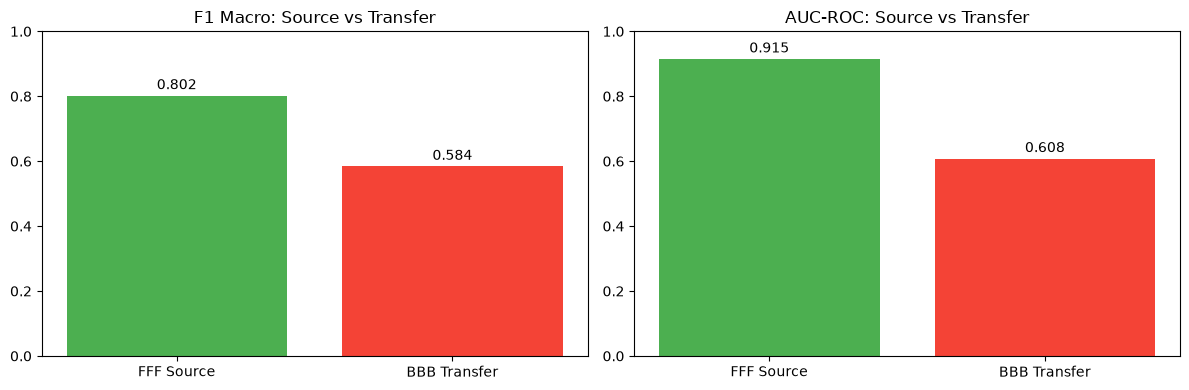


Interpretation:
A large negative delta indicates notable domain shift and limited zero-shot transferability.


In [53]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# --- paths ---
SCRIPT_DIR = os.path.abspath('.')
CODE_DIR = SCRIPT_DIR
DATA_DIR = os.path.join(SCRIPT_DIR, '..', 'dataset')
CLEAN_DIR = os.path.join(DATA_DIR, 'cleaned')

# --- load FFF-trained artifacts ---
model_i1_saved = joblib.load(os.path.join(CODE_DIR, 'model_i1.pkl'))
scaler_saved = joblib.load(os.path.join(CODE_DIR, 'scaler.pkl'))
km_saved = joblib.load(os.path.join(CODE_DIR, 'km_final.pkl'))

with open(os.path.join(CODE_DIR, 'model_meta.json'), 'r', encoding='utf-8') as f:
    meta_saved = json.load(f)


def pick_data_path(clean_name, raw_name):
    """Use cleaned dataset first; fallback to raw if cleaned file is unavailable."""
    clean_path = os.path.join(CLEAN_DIR, clean_name)
    raw_path = os.path.join(DATA_DIR, raw_name)
    if os.path.exists(clean_path):
        return clean_path, 'cleaned'
    return raw_path, 'raw'


# --- load cleaned data first (fallback to raw) ---
si_path, si_src = pick_data_path('studentInfo_clean.csv', 'studentInfo.csv')
sv_path, sv_src = pick_data_path('studentVle_clean.csv', 'studentVle.csv')
sa_path, sa_src = pick_data_path('studentAssessment_clean.csv', 'studentAssessment.csv')
ass_path, ass_src = pick_data_path('assessments_clean.csv', 'assessments.csv')
vle_path, vle_src = pick_data_path('vle_clean.csv', 'vle.csv')
sr_path, sr_src = pick_data_path('studentRegistration_clean.csv', 'studentRegistration.csv')

si_full = pd.read_csv(si_path)
sv_full = pd.read_csv(sv_path)
sa_full = pd.read_csv(sa_path)
ass_full = pd.read_csv(ass_path)
vle_full = pd.read_csv(vle_path)
sr_full = pd.read_csv(sr_path)

print('Data source for transfer experiment:')
print(f'  studentInfo:         {si_src} -> {os.path.basename(si_path)}')
print(f'  studentVle:          {sv_src} -> {os.path.basename(sv_path)}')
print(f'  studentAssessment:   {sa_src} -> {os.path.basename(sa_path)}')
print(f'  assessments:         {ass_src} -> {os.path.basename(ass_path)}')
print(f'  vle:                 {vle_src} -> {os.path.basename(vle_path)}')
print(f'  studentRegistration: {sr_src} -> {os.path.basename(sr_path)}')

TARGET_MODULE_TRANSFER = 'BBB'
ENTITY_KEYS = ['id_student', 'code_presentation']

# --- filter target domain BBB ---
si_bbb = si_full[si_full['code_module'] == TARGET_MODULE_TRANSFER].copy()
keys_bbb = si_bbb[ENTITY_KEYS].drop_duplicates()

sv_bbb = sv_full[sv_full['code_module'] == TARGET_MODULE_TRANSFER].merge(keys_bbb, on=ENTITY_KEYS, how='inner')
sr_bbb = sr_full[sr_full['code_module'] == TARGET_MODULE_TRANSFER].merge(keys_bbb, on=ENTITY_KEYS, how='inner')
vle_bbb = vle_full[vle_full['code_module'] == TARGET_MODULE_TRANSFER].copy()
ass_bbb = ass_full[ass_full['code_module'] == TARGET_MODULE_TRANSFER][['id_assessment', 'code_presentation']]
sa_bbb = sa_full.merge(ass_bbb, on='id_assessment', how='inner').merge(keys_bbb, on=ENTITY_KEYS, how='inner')

# --- metadata ---
fill_cols_t = meta_saved['fill_cols']
cat_cols_t = meta_saved['cat_cols']
feature_cols_t = meta_saved['feature_cols']
cluster_features_t = meta_saved['cluster_features']
cat_enc_t = meta_saved['cat_encodings']
i1_cols_t = meta_saved.get('i1_feature_cols', feature_cols_t + ['cluster'])

interactive_types = {'forumng', 'oucollaborate', 'ouwiki', 'ouelluminate', 'chat', 'questionnaire'}
assessment_types = {'quiz', 'externalquiz'}

# --- feature engineering on BBB ---
sv_merged_bbb = sv_bbb.merge(
    vle_bbb[['id_site', 'code_module', 'code_presentation', 'activity_type']],
    on=['id_site', 'code_module', 'code_presentation'],
    how='left'
)


def agg_vle_transfer(g):
    return pd.Series({
        'total_clicks': g['sum_click'].sum(),
        'active_days': g['date'].nunique(),
        'mean_daily_clicks': g['sum_click'].mean(),
        'max_daily_clicks': g['sum_click'].max(),
        'std_daily_clicks': g['sum_click'].std(ddof=0),
        'unique_resources': g['id_site'].nunique(),
        'interactive_clicks': g.loc[g['activity_type'].isin(interactive_types), 'sum_click'].sum(),
        'assessment_clicks': g.loc[g['activity_type'].isin(assessment_types), 'sum_click'].sum(),
        'content_clicks': g.loc[~g['activity_type'].isin(interactive_types | assessment_types), 'sum_click'].sum(),
        'activity_type_diversity': g['activity_type'].nunique(),
        'first_access_day': g['date'].min(),
        'last_access_day': g['date'].max(),
    })


vle_feats_bbb = sv_merged_bbb.groupby(ENTITY_KEYS).apply(agg_vle_transfer).reset_index()
vle_feats_bbb['active_span'] = vle_feats_bbb['last_access_day'] - vle_feats_bbb['first_access_day']
vle_feats_bbb['std_daily_clicks'] = vle_feats_bbb['std_daily_clicks'].fillna(0)

assess_feats_bbb = sa_bbb.groupby(ENTITY_KEYS).agg(
    mean_score=('score', 'mean'),
    num_submissions=('id_assessment', 'count')
).reset_index()

reg_bbb = sr_bbb.groupby(ENTITY_KEYS)['date_registration'].mean().reset_index()
reg_bbb.columns = ENTITY_KEYS + ['reg_offset']

df_bbb_transfer = (
    si_bbb[['id_student', 'code_presentation', 'gender', 'age_band', 'highest_education', 'imd_band', 'disability', 'final_result']]
    .drop_duplicates(ENTITY_KEYS, keep='first')
    .merge(vle_feats_bbb, on=ENTITY_KEYS, how='left')
    .merge(assess_feats_bbb, on=ENTITY_KEYS, how='left')
    .merge(reg_bbb, on=ENTITY_KEYS, how='left')
)

extra_cols = [
    'interactive_clicks', 'assessment_clicks', 'content_clicks', 'activity_type_diversity',
    'reg_offset', 'active_span', 'std_daily_clicks', 'first_access_day', 'last_access_day'
]

for c in fill_cols_t:
    if c in df_bbb_transfer.columns:
        df_bbb_transfer[c] = df_bbb_transfer[c].fillna(0)
for c in extra_cols:
    if c in df_bbb_transfer.columns:
        df_bbb_transfer[c] = df_bbb_transfer[c].fillna(0)

for c in cat_cols_t:
    enc_map = {v: int(k) for k, v in cat_enc_t[c].items()}
    df_bbb_transfer[c] = df_bbb_transfer[c].map(enc_map).fillna(-1).astype(int)

# --- assign clusters using FFF-trained scaler + KMeans ---
clip_caps_t = meta_saved.get('clip_caps', {})
clust_df_bbb = df_bbb_transfer.copy()
for f, cap in clip_caps_t.items():
    if f in clust_df_bbb.columns:
        clust_df_bbb[f] = clust_df_bbb[f].clip(upper=cap)
for cf in cluster_features_t:
    if cf not in clust_df_bbb.columns:
        clust_df_bbb[cf] = 0

clust_vals_bbb = clust_df_bbb[cluster_features_t].values
clust_scaled_bbb = scaler_saved.transform(clust_vals_bbb)
df_bbb_transfer['cluster'] = km_saved.predict(clust_scaled_bbb)

if 'cluster_p' in i1_cols_t:
    soft_bbb = km_saved.transform(clust_scaled_bbb)
    inv_bbb = 1.0 / (soft_bbb + 1e-9)
    df_bbb_transfer['cluster_p'] = (inv_bbb / inv_bbb.sum(axis=1, keepdims=True))[:, 0]

for c in i1_cols_t:
    if c not in df_bbb_transfer.columns:
        df_bbb_transfer[c] = 0

X_bbb_transfer = df_bbb_transfer[i1_cols_t].values.astype(float)
y_bbb_transfer = (df_bbb_transfer['final_result'].astype(str) == 'Withdrawn').astype(int).values

# --- inference ---
y_proba_bbb_transfer = model_i1_saved.predict_proba(X_bbb_transfer)[:, 1]
y_pred_bbb_transfer = (y_proba_bbb_transfer >= 0.5).astype(int)

acc_bbb_transfer = accuracy_score(y_bbb_transfer, y_pred_bbb_transfer)
prec_bbb_transfer = precision_score(y_bbb_transfer, y_pred_bbb_transfer, average='macro', zero_division=0)
rec_bbb_transfer = recall_score(y_bbb_transfer, y_pred_bbb_transfer, average='macro', zero_division=0)
f1_bbb_transfer = f1_score(y_bbb_transfer, y_pred_bbb_transfer, average='macro', zero_division=0)
auc_bbb_transfer = roc_auc_score(y_bbb_transfer, y_proba_bbb_transfer)
wd_rec_bbb_transfer = recall_score(y_bbb_transfer, y_pred_bbb_transfer, pos_label=1, zero_division=0)
wd_prec_bbb_transfer = precision_score(y_bbb_transfer, y_pred_bbb_transfer, pos_label=1, zero_division=0)
cm_bbb_transfer = confusion_matrix(y_bbb_transfer, y_pred_bbb_transfer)

# --- compare with source-domain validation ---
src_i1 = meta_saved.get('i1_metrics', {})
src_f1 = float(src_i1.get('f1_macro', np.nan))
src_auc = float(src_i1.get('auc_roc', np.nan))

transfer_compare_df = pd.DataFrame([
    {
        'Domain': 'Source Validation (FFF, i1_metrics)',
        'F1_macro': src_f1,
        'AUC_ROC': src_auc,
    },
    {
        'Domain': 'Cross-module Transfer (FFF -> BBB)',
        'F1_macro': f1_bbb_transfer,
        'AUC_ROC': auc_bbb_transfer,
    }
])
transfer_compare_df['F1_delta_vs_source'] = transfer_compare_df['F1_macro'] - src_f1
transfer_compare_df['AUC_delta_vs_source'] = transfer_compare_df['AUC_ROC'] - src_auc

print('=' * 90)
print('A1 Cross-module Transferability Result: FFF-trained artifacts -> BBB target domain')
print('=' * 90)
print(f'BBB sample size      : {len(df_bbb_transfer):,}')
print(f'BBB withdrawal rate  : {y_bbb_transfer.mean():.2%}')
print()
print('BBB transfer metrics:')
print(f'  Accuracy           : {acc_bbb_transfer:.4f}')
print(f'  Precision (macro)  : {prec_bbb_transfer:.4f}')
print(f'  Recall (macro)     : {rec_bbb_transfer:.4f}')
print(f'  F1 (macro)         : {f1_bbb_transfer:.4f}')
print(f'  AUC-ROC            : {auc_bbb_transfer:.4f}')
print(f'  Withdrawn Recall   : {wd_rec_bbb_transfer:.4f}')
print(f'  Withdrawn Precision: {wd_prec_bbb_transfer:.4f}')
print('\nConfusion Matrix [[TN, FP], [FN, TP]]:')
print(cm_bbb_transfer)

print('\nComparison with source-domain validation:')
display(transfer_compare_df)

# --- visual comparison ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(['FFF Source', 'BBB Transfer'], [src_f1, f1_bbb_transfer], color=['#4CAF50', '#F44336'])
ax[0].set_title('F1 Macro: Source vs Transfer')
ax[0].set_ylim(0, 1)
for i, v in enumerate([src_f1, f1_bbb_transfer]):
    ax[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

ax[1].bar(['FFF Source', 'BBB Transfer'], [src_auc, auc_bbb_transfer], color=['#4CAF50', '#F44336'])
ax[1].set_title('AUC-ROC: Source vs Transfer')
ax[1].set_ylim(0, 1)
for i, v in enumerate([src_auc, auc_bbb_transfer]):
    ax[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('A large negative delta indicates notable domain shift and limited zero-shot transferability.')

### 7.2 Threshold Optimization & Probability Calibration for BBB Transfer

**Problem**: FFF→BBB transfer shows significant performance degradation. This can be mitigated through threshold optimization and probability calibration without retraining the model. The key is to adjust decision rules specific to BBB data characteristics.

BBB calibration set size: 3163, positive samples: 985 (31.1%)
BBB test set size: 4746, positive samples: 1403 (29.6%)

Strategy 2: Probability Calibration (Isotonic Calibration)
Raw probability range: [0.0001, 0.9987]
Calibrated probability range: [0.0000, 0.5273]

Strategy 3: Threshold Optimization (F1/AUC Maximization)

Optimal F1 threshold: 0.30 (F1=0.6042)

Threshold Scan Results:
 Threshold       F1  Precision   Recall
      0.10 0.229007   0.397636 0.499173
      0.15 0.229007   0.397636 0.499173
      0.20 0.229007   0.397636 0.499173
      0.25 0.539997   0.566916 0.580019
      0.30 0.604207   0.604450 0.603972
      0.35 0.602534   0.626226 0.597281
      0.40 0.602534   0.626226 0.597281
      0.45 0.593971   0.621612 0.589674
      0.50 0.592471   0.628177 0.588656

BBB Transfer Performance Comparison (Results on Test Set)

                     Method  Accuracy  Precision   Recall  F1 (macro)  Withdrawn-Precision  Withdrawn-Recall
       Raw (Threshold=0.5)  0.620312   0.58

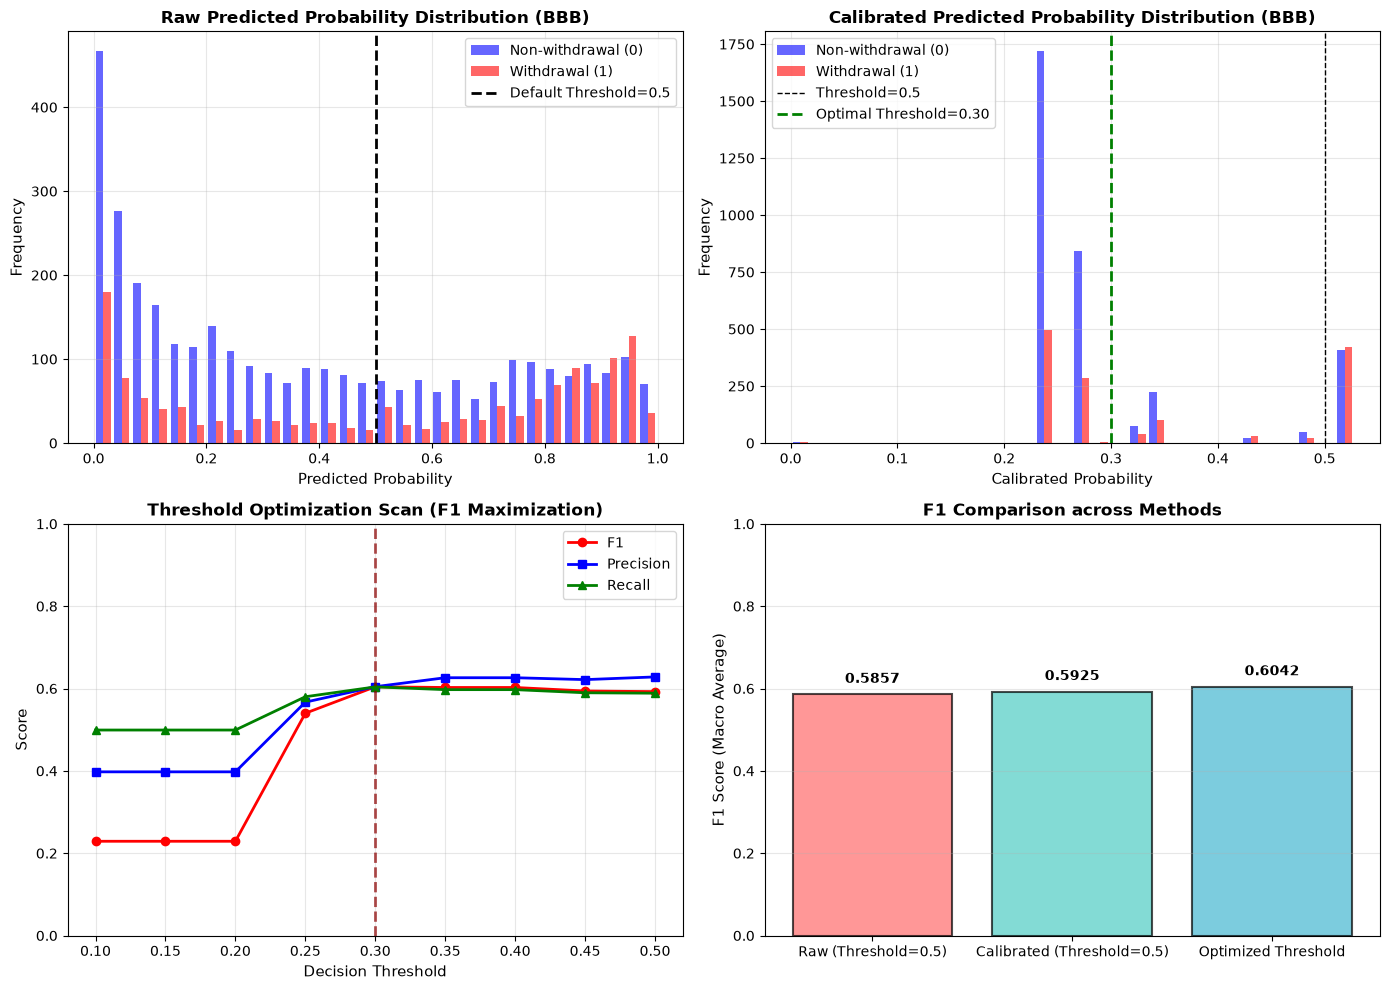


✓ Figure saved as BBB_calibration_optimization.png


In [54]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve
import numpy as np

# === Strategy 1: Split BBB data into calibration and test sets ===
# Use 40% for calibration and 60% for performance evaluation
n_bbb = len(X_bbb_transfer)
calib_size = int(0.4 * n_bbb)

calib_indices = np.random.RandomState(42).choice(n_bbb, calib_size, replace=False)
test_indices = np.array([i for i in range(n_bbb) if i not in calib_indices])

X_bbb_calib = X_bbb_transfer[calib_indices]
y_bbb_calib = y_bbb_transfer[calib_indices]

X_bbb_test_calib = X_bbb_transfer[test_indices]
y_bbb_test_calib = y_bbb_transfer[test_indices]

print(f"BBB calibration set size: {len(X_bbb_calib)}, positive samples: {y_bbb_calib.sum()} ({y_bbb_calib.mean()*100:.1f}%)")
print(f"BBB test set size: {len(X_bbb_test_calib)}, positive samples: {y_bbb_test_calib.sum()} ({y_bbb_test_calib.mean()*100:.1f}%)")

# === Strategy 2: Probability Calibration (Isotonic Regression) ===
print("\n" + "="*60)
print("Strategy 2: Probability Calibration (Isotonic Calibration)")
print("="*60)

# Perform Isotonic regression calibration on calibration set
# Use IsotonicRegression directly for calibration
from sklearn.isotonic import IsotonicRegression

# Get raw probabilities on calibration set
y_proba_calib = model_i1_saved.predict_proba(X_bbb_calib)[:, 1]

# Perform IsotonicRegression calibration
iso_reg = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
iso_reg.fit(y_proba_calib, y_bbb_calib)

# Apply calibration on test set
y_proba_test_raw = model_i1_saved.predict_proba(X_bbb_test_calib)[:, 1]
y_proba_test_calibrated = iso_reg.transform(y_proba_test_raw)

print(f"Raw probability range: [{y_proba_test_raw.min():.4f}, {y_proba_test_raw.max():.4f}]")
print(f"Calibrated probability range: [{y_proba_test_calibrated.min():.4f}, {y_proba_test_calibrated.max():.4f}]")

# === Strategy 3: Threshold Optimization ===
print("\n" + "="*60)
print("Strategy 3: Threshold Optimization (F1/AUC Maximization)")
print("="*60)

# Search for optimal threshold
thresholds = np.arange(0.1, 1.0, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_calib_thresh = (y_proba_test_calibrated >= thresh).astype(int)
    
    if y_pred_calib_thresh.sum() == 0:  # Avoid all negative predictions
        continue
    
    f1_thresh = f1_score(y_bbb_test_calib, y_pred_calib_thresh, average='macro')
    prec_thresh = precision_score(y_bbb_test_calib, y_pred_calib_thresh, average='macro', zero_division=0)
    rec_thresh = recall_score(y_bbb_test_calib, y_pred_calib_thresh, average='macro', zero_division=0)
    
    threshold_results.append({
        'Threshold': thresh,
        'F1': f1_thresh,
        'Precision': prec_thresh,
        'Recall': rec_thresh
    })

threshold_df = pd.DataFrame(threshold_results)
best_thresh_f1 = threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold']
best_f1 = threshold_df['F1'].max()

print(f"\nOptimal F1 threshold: {best_thresh_f1:.2f} (F1=0.{int(best_f1*10000):.0f})")
print("\nThreshold Scan Results:")
print(threshold_df.to_string(index=False))

# === Apply optimal threshold ===
y_pred_optimized = (y_proba_test_calibrated >= best_thresh_f1).astype(int)

acc_opt = accuracy_score(y_bbb_test_calib, y_pred_optimized)
prec_opt = precision_score(y_bbb_test_calib, y_pred_optimized, average='macro', zero_division=0)
rec_opt = recall_score(y_bbb_test_calib, y_pred_optimized, average='macro', zero_division=0)
f1_opt = f1_score(y_bbb_test_calib, y_pred_optimized, average='macro')
wd_prec_opt = precision_score(y_bbb_test_calib, y_pred_optimized, pos_label=1, zero_division=0)
wd_rec_opt = recall_score(y_bbb_test_calib, y_pred_optimized, pos_label=1, zero_division=0)

print("\n" + "="*60)
print("BBB Transfer Performance Comparison (Results on Test Set)")
print("="*60)

comparison_df = pd.DataFrame({
    'Method': ['Raw (Threshold=0.5)', 'Calibrated (Threshold=0.5)', 'Optimized Threshold'],
    'Accuracy': [
        accuracy_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int)),
        accuracy_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int)),
        acc_opt
    ],
    'Precision': [
        precision_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int), average='macro', zero_division=0),
        precision_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int), average='macro', zero_division=0),
        prec_opt
    ],
    'Recall': [
        recall_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int), average='macro', zero_division=0),
        recall_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int), average='macro', zero_division=0),
        rec_opt
    ],
    'F1 (macro)': [
        f1_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int), average='macro'),
        f1_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int), average='macro'),
        f1_opt
    ],
    'Withdrawn-Precision': [
        precision_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int), pos_label=1, zero_division=0),
        precision_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int), pos_label=1, zero_division=0),
        wd_prec_opt
    ],
    'Withdrawn-Recall': [
        recall_score(y_bbb_test_calib, (y_proba_test_raw >= 0.5).astype(int), pos_label=1, zero_division=0),
        recall_score(y_bbb_test_calib, (y_proba_test_calibrated >= 0.5).astype(int), pos_label=1, zero_division=0),
        wd_rec_opt
    ]
})

print("\n", comparison_df.to_string(index=False))

# === Visualization: Probability distributions and threshold effects ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw probability distribution
ax = axes[0, 0]
ax.hist([y_proba_test_raw[y_bbb_test_calib==0], y_proba_test_raw[y_bbb_test_calib==1]], 
        bins=30, label=['Non-withdrawal (0)', 'Withdrawal (1)'], color=['blue', 'red'], alpha=0.6)
ax.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold=0.5')
ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Raw Predicted Probability Distribution (BBB)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Calibrated probability distribution
ax = axes[0, 1]
ax.hist([y_proba_test_calibrated[y_bbb_test_calib==0], y_proba_test_calibrated[y_bbb_test_calib==1]], 
        bins=30, label=['Non-withdrawal (0)', 'Withdrawal (1)'], color=['blue', 'red'], alpha=0.6)
ax.axvline(0.5, color='k', linestyle='--', linewidth=1, label='Threshold=0.5')
ax.axvline(best_thresh_f1, color='green', linestyle='--', linewidth=2, label=f'Optimal Threshold={best_thresh_f1:.2f}')
ax.set_xlabel('Calibrated Probability', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Calibrated Predicted Probability Distribution (BBB)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Threshold vs Performance Metrics
ax = axes[1, 0]
ax.plot(threshold_df['Threshold'], threshold_df['F1'], 'o-', linewidth=2, markersize=6, label='F1', color='red')
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], 's-', linewidth=2, markersize=6, label='Precision', color='blue')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], '^-', linewidth=2, markersize=6, label='Recall', color='green')
ax.axvline(best_thresh_f1, color='darkred', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Threshold Optimization Scan (F1 Maximization)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# 4. Method Comparison Bar Chart (F1 Metric)
ax = axes[1, 1]
methods = comparison_df['Method'].tolist()
f1_scores = comparison_df['F1 (macro)'].tolist()
colors_bar = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars = ax.bar(methods, f1_scores, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('F1 Score (Macro Average)', fontsize=11)
ax.set_title('F1 Comparison across Methods', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, f1_val) in enumerate(zip(bars, f1_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{f1_val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('BBB_calibration_optimization.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved as BBB_calibration_optimization.png")

## 22. A2 — Multi-class Engagement Prediction (Distinction / Fail / Pass / Withdrawn)

**Goal (A2)**: Extend the binary withdrawal classifier to a **4-class outcome prediction** task, testing whether the profile-enriched I1+ pipeline (B1+ features + `cluster_p`) retains its advantage over the raw-feature B1+ baseline when the prediction target spans all four OULAD final outcomes.

**Design**:
- Target: 4-class `final_result` (Distinction = 0, Fail = 1, Pass = 2, Withdrawn = 3)
- Pair A: B1+ (16 feat) → multi-class XGBoost **baseline**
- Pair B: I1+ (17 feat = B1+ + `cluster_p`) → **profile-enriched** multi-class model
- Architecture: XGBoost `multi:softprob`, same B1-tuned hyperparameters as I1 (controlled comparison)
- Class imbalance: `compute_class_weight('balanced')` → `sample_weight`
- Evaluation: per-class F1/Precision/Recall, macro-F1, 4×4 confusion matrix
- Interpretability: per-class SHAP beeswarm + `cluster_p` SHAP heat-map (archetype × outcome class)

**Research connection**:
- **RQ2**: Does `cluster_p` improve multi-class prediction over the hand-crafted baseline?
- **RQ3**: How does `cluster_p`'s SHAP contribution differ across the four outcome classes?

── Multi-class Label Distribution ──

  Train 2013  (N=3897)
    0 = Distinction  :   305  (7.8%)
    1 = Fail         :   934  (24.0%)
    2 = Pass         :  1572  (40.3%)
    3 = Withdrawn    :  1086  (27.9%)

  Test  2014  (N=3865)
    0 = Distinction  :   365  (9.4%)
    1 = Fail         :   777  (20.1%)
    2 = Pass         :  1406  (36.4%)
    3 = Withdrawn    :  1317  (34.1%)

  Balanced class weights: {'Distinction': np.float64(3.194), 'Fail': np.float64(1.043), 'Pass': np.float64(0.62), 'Withdrawn': np.float64(0.897)}

── Training B1+ multi-class (16 feat) ──
  macro-F1 = 0.6911
── Training I1+ multi-class (17 feat = B1+ + cluster_p) ──
  macro-F1 = 0.6885  (Δ vs B1+: -0.0026)

── B1+ multi-class classification report ──
              precision    recall  f1-score   support

 Distinction     0.5827    0.8301    0.6847       365
        Fail     0.4763    0.5959    0.5294       777
        Pass     0.8672    0.7760    0.8191      1406
   Withdrawn     0.7973    0.6750    0.731

,Class,B1+ P,B1+ R,B1+ F1,I1+ P,I1+ R,I1+ F1,ΔF1
0,Distinction,0.5827,0.8301,0.6847,0.5806,0.8384,0.6861,0.0014
1,Fail,0.4763,0.5959,0.5294,0.4694,0.6023,0.5276,-0.0018
2,Pass,0.8672,0.776,0.8191,0.8681,0.7724,0.8175,-0.0016
3,Withdrawn,0.7973,0.675,0.7311,0.7982,0.6606,0.7229,-0.0082
4,── macro avg ──,,,0.6911,,,0.6885,-0.0026


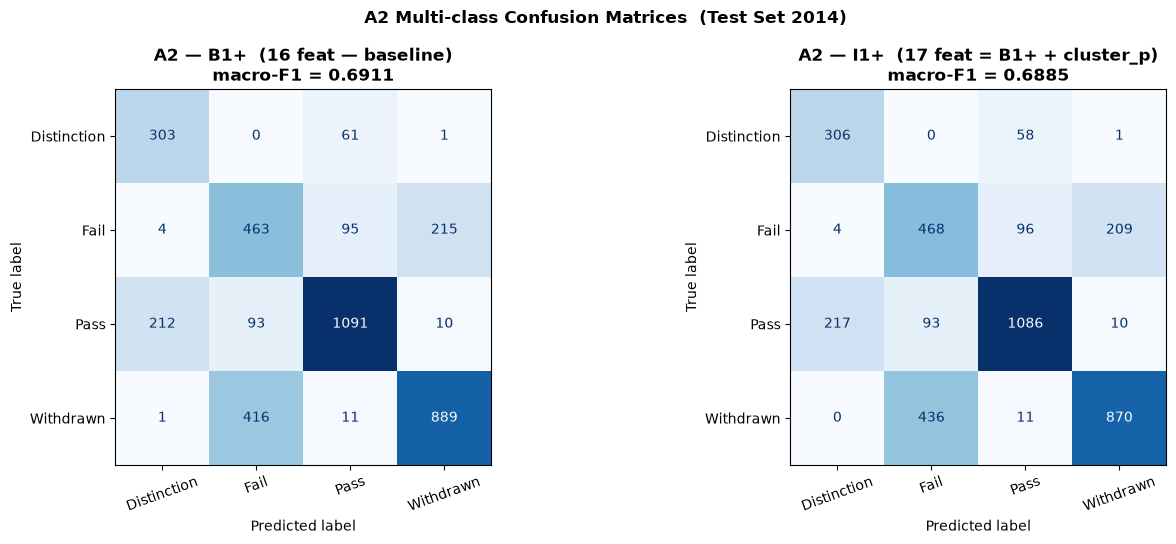


══ A2 Summary ══
  B1+ multi-class  macro-F1 = 0.6911
  I1+ multi-class  macro-F1 = 0.6885  (Δ = -0.0026)


In [55]:
# ── A2.1  Multi-class XGBoost: B1+ (16 feat) vs I1+ (17 feat) ───────────────
# Extends the binary withdrawal classifier to 4-class outcome prediction.
# Controlled comparison: identical XGBoost config as I1; only cluster_p differs.

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import warnings; warnings.filterwarnings('ignore')

CLASS_NAMES_MC = ['Distinction', 'Fail', 'Pass', 'Withdrawn']
class_enc_mc   = {c: i for i, c in enumerate(CLASS_NAMES_MC)}

# ── 1. Multi-class target ────────────────────────────────────────────────────
y_train_mc = df_b1p.loc[train_mask, 'final_result'].map(class_enc_mc).values.astype(int)
y_test_mc  = df_b1p.loc[test_mask,  'final_result'].map(class_enc_mc).values.astype(int)

print("── Multi-class Label Distribution ──")
for split_name, y_mc in [('Train 2013', y_train_mc), ('Test  2014', y_test_mc)]:
    print(f"\n  {split_name}  (N={len(y_mc)})")
    for cls, idx in class_enc_mc.items():
        n = (y_mc == idx).sum()
        print(f"    {idx} = {cls:<12} : {n:5d}  ({n/len(y_mc):.1%})")

# ── 2. Balanced sample weights ───────────────────────────────────────────────
cw_mc       = compute_class_weight('balanced', classes=np.arange(4), y=y_train_mc)
sw_train_mc = np.array([cw_mc[y] for y in y_train_mc])
print(f"\n  Balanced class weights: {dict(zip(CLASS_NAMES_MC, np.round(cw_mc, 3)))}")

# ── 3. Shared XGBoost config (B1-tuned hyperparameters, multi:softprob) ──────
# Note: use_label_encoder removed in XGBoost 3.x
_mc_params = dict(
    objective        = 'multi:softprob',
    num_class        = 4,
    n_estimators     = 290,
    max_depth        = 3,
    learning_rate    = 0.289,
    subsample        = 0.707,
    colsample_bytree = 0.771,
    gamma            = 4.833,
    reg_alpha        = 0.306,
    reg_lambda       = 0.977,
    min_child_weight = 4,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
)

# ── 4. Train B1+ multi-class (16 feat) ───────────────────────────────────────
print("\n── Training B1+ multi-class (16 feat) ──", flush=True)
model_b1p_mc = XGBClassifier(**_mc_params)
model_b1p_mc.fit(X_train_b1p, y_train_mc, sample_weight=sw_train_mc)

y_pred_b1p_mc  = model_b1p_mc.predict(X_test_b1p)
y_proba_b1p_mc = model_b1p_mc.predict_proba(X_test_b1p)
f1_b1p_mc      = f1_score(y_test_mc, y_pred_b1p_mc, average='macro')
print(f"  macro-F1 = {f1_b1p_mc:.4f}")

# ── 5. Train I1+ multi-class (17 feat = B1+ + cluster_p) ─────────────────────
print("── Training I1+ multi-class (17 feat = B1+ + cluster_p) ──", flush=True)
model_i1p_mc = XGBClassifier(**_mc_params)
model_i1p_mc.fit(X_train_i1p, y_train_mc, sample_weight=sw_train_mc)

y_pred_i1p_mc  = model_i1p_mc.predict(X_test_i1p)
y_proba_i1p_mc = model_i1p_mc.predict_proba(X_test_i1p)
f1_i1p_mc      = f1_score(y_test_mc, y_pred_i1p_mc, average='macro')
print(f"  macro-F1 = {f1_i1p_mc:.4f}  (Δ vs B1+: {f1_i1p_mc - f1_b1p_mc:+.4f})")

# ── 6. Detailed classification reports ───────────────────────────────────────
print("\n── B1+ multi-class classification report ──")
print(classification_report(y_test_mc, y_pred_b1p_mc,
                             target_names=CLASS_NAMES_MC, digits=4))
print("── I1+ multi-class classification report ──")
print(classification_report(y_test_mc, y_pred_i1p_mc,
                             target_names=CLASS_NAMES_MC, digits=4))

# ── 7. Per-class comparison table ────────────────────────────────────────────
mc_compare = []
for idx, cls_name in enumerate(CLASS_NAMES_MC):
    b_p = precision_score(y_test_mc == idx, y_pred_b1p_mc == idx, zero_division=0)
    b_r = recall_score   (y_test_mc == idx, y_pred_b1p_mc == idx, zero_division=0)
    b_f = f1_score       (y_test_mc == idx, y_pred_b1p_mc == idx, zero_division=0)
    i_p = precision_score(y_test_mc == idx, y_pred_i1p_mc == idx, zero_division=0)
    i_r = recall_score   (y_test_mc == idx, y_pred_i1p_mc == idx, zero_division=0)
    i_f = f1_score       (y_test_mc == idx, y_pred_i1p_mc == idx, zero_division=0)
    mc_compare.append({'Class': cls_name,
                       'B1+ P': round(b_p, 4), 'B1+ R': round(b_r, 4), 'B1+ F1': round(b_f, 4),
                       'I1+ P': round(i_p, 4), 'I1+ R': round(i_r, 4), 'I1+ F1': round(i_f, 4),
                       'ΔF1':   round(i_f - b_f, 4)})

mc_compare.append({'Class': '── macro avg ──',
                   'B1+ P': '', 'B1+ R': '', 'B1+ F1': round(f1_b1p_mc, 4),
                   'I1+ P': '', 'I1+ R': '', 'I1+ F1': round(f1_i1p_mc, 4),
                   'ΔF1':   round(f1_i1p_mc - f1_b1p_mc, 4)})
print("── Per-class comparison (B1+ vs I1+) ──")
display(pd.DataFrame(mc_compare))

# ── 8. Confusion matrices side by side ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, y_pred, label, f1_val in [
    (axes[0], y_pred_b1p_mc, 'B1+  (16 feat — baseline)', f1_b1p_mc),
    (axes[1], y_pred_i1p_mc, 'I1+  (17 feat = B1+ + cluster_p)', f1_i1p_mc),
]:
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test_mc, y_pred),
                                  display_labels=CLASS_NAMES_MC)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'A2 — {label}\nmacro-F1 = {f1_val:.4f}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('A2 Multi-class Confusion Matrices  (Test Set 2014)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 9. Summary ───────────────────────────────────────────────────────────────
print("\n══ A2 Summary ══")
print(f"  B1+ multi-class  macro-F1 = {f1_b1p_mc:.4f}")
print(f"  I1+ multi-class  macro-F1 = {f1_i1p_mc:.4f}  (Δ = {f1_i1p_mc - f1_b1p_mc:+.4f})")

Computing SHAP — B1+ multi-class (16 feat) ... done  shape=(3865, 16, 4)
Computing SHAP — I1+ multi-class (17 feat) ... done  shape=(3865, 17, 4)

── B1+ multi-class  Mean |SHAP| (top-10) ──


,Feature,Distinction,Fail,Pass,Withdrawn,Mean (avg classes)
0,mean_score,1.98711,0.47078,0.39367,0.15040,0.75049
1,num_submissions,0.67348,0.40941,1.33429,0.53414,0.73783
2,assessment_clicks,0.31896,0.04014,0.75116,1.04020,0.53761
3,unique_resources,0.44489,0.08539,0.00336,0.05945,0.14827
4,active_days,0.35312,0.12732,0.02006,0.03469,0.13380
5,activity_type_diversity,0.24843,0.12038,0.00000,0.04301,0.10295
6,content_clicks,0.03105,0.10323,0.03267,0.23043,0.09935
7,reg_offset,0.14499,0.05067,0.00000,0.05866,0.06358
8,total_clicks,0.10499,0.00000,0.08055,0.06630,0.06296
9,interactive_clicks,0.16062,0.01756,0.00000,0.01642,0.04865



── I1+ multi-class  Mean |SHAP| (top-10) ──


,Feature,Distinction,Fail,Pass,Withdrawn,Mean (avg classes)
0,mean_score,2.11091,0.47994,0.41212,0.10885,0.77796
1,num_submissions,0.63328,0.43620,1.31384,0.54698,0.73258
2,assessment_clicks,0.30870,0.05660,0.73556,1.14776,0.56215
3,unique_resources,0.46709,0.07161,0.03272,0.03910,0.15263
4,active_days,0.30163,0.13439,0.01013,0.04625,0.12310
5,activity_type_diversity,0.29136,0.08474,0.01138,0.00000,0.09687
6,content_clicks,0.03821,0.07351,0.03224,0.22234,0.09158
7,total_clicks,0.10699,0.02336,0.05436,0.06803,0.06319
8,interactive_clicks,0.14402,0.01760,0.01254,0.03250,0.05166
9,reg_offset,0.03140,0.03379,0.04040,0.07827,0.04596



  cluster_p global rank in I1+ multi-class: #12/17
  cluster_p mean |SHAP| (avg over 4 classes): 0.02520
    → Distinction : mean |SHAP| = 0.00000
    → Fail        : mean |SHAP| = 0.03779
    → Pass        : mean |SHAP| = 0.00000
    → Withdrawn   : mean |SHAP| = 0.06301


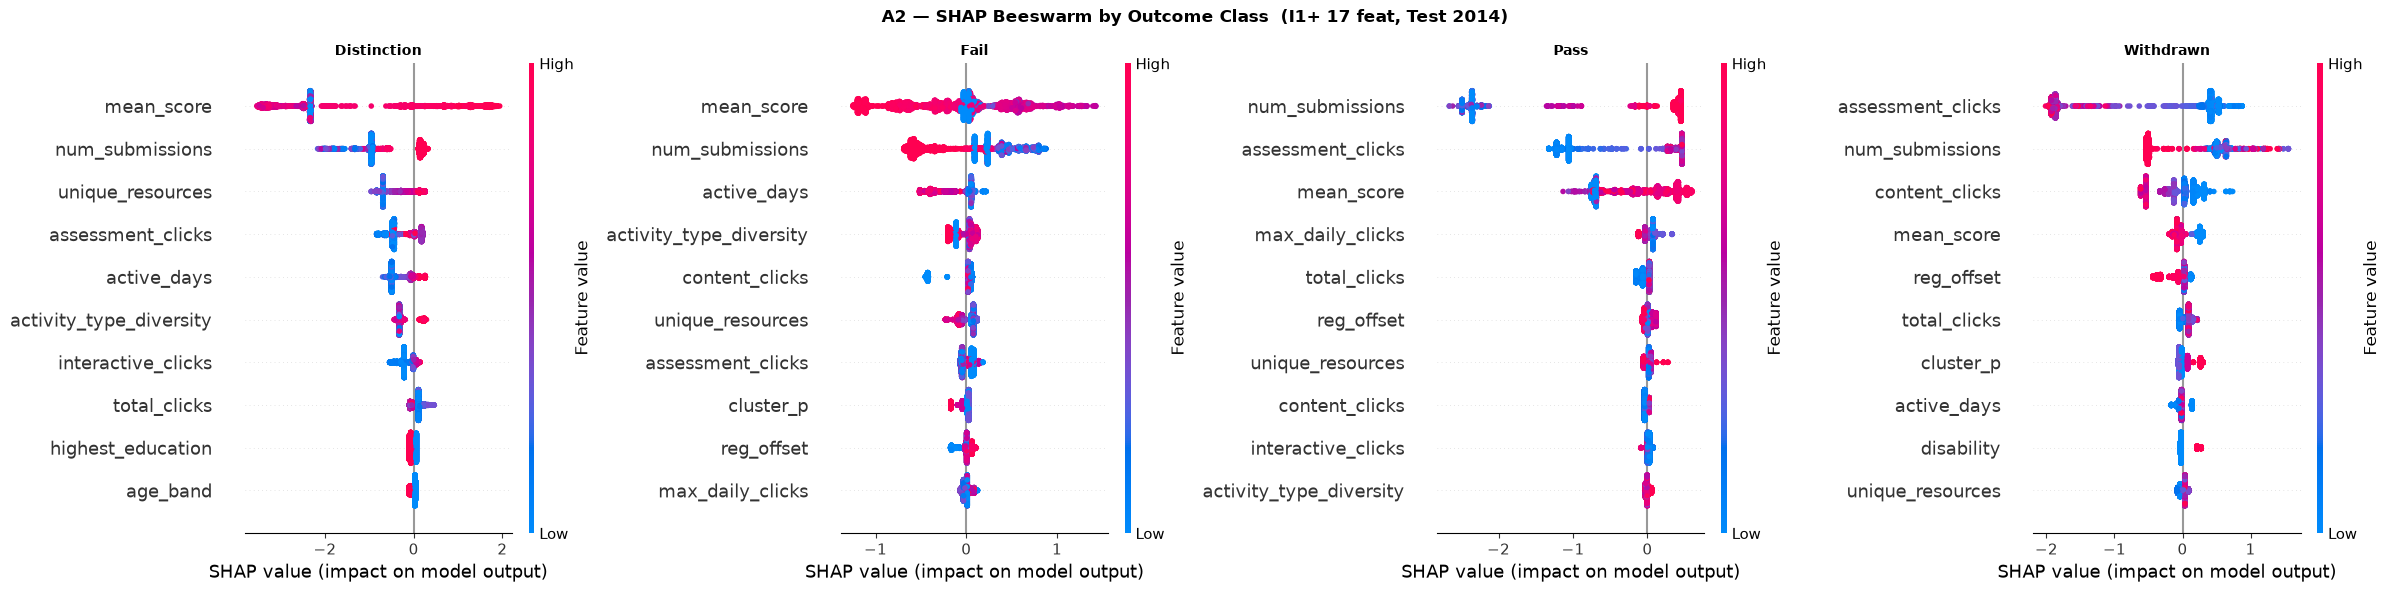


── cluster_p Mean SHAP by Archetype × Outcome Class  (I1+ multi-class) ──


,Archetype,N (test),WD Rate,SHAP→Distinction,SHAP→Fail,SHAP→Pass,SHAP→Withdrawn
0,Moderate,1585,7.3%,0.0,0.0121,0.0,-0.0186
1,Disengaged,1305,63.7%,0.0,0.0257,0.0,-0.0527
2,High Engaged,594,1.3%,0.0,-0.0500,0.0,0.0746
3,No VLE Record,381,95.0%,0.0,-0.1669,0.0,0.2651


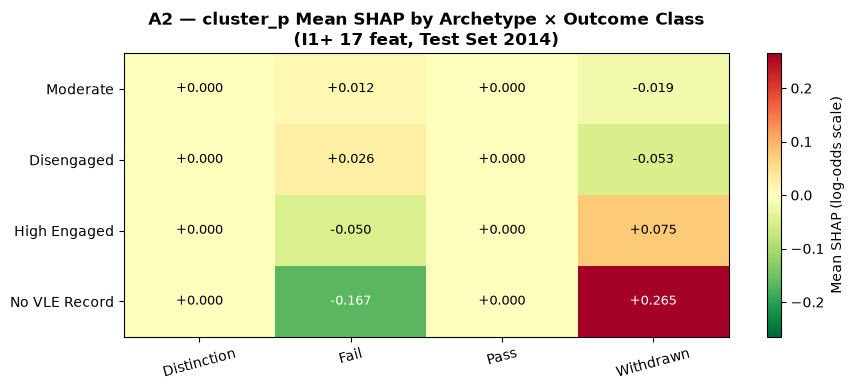

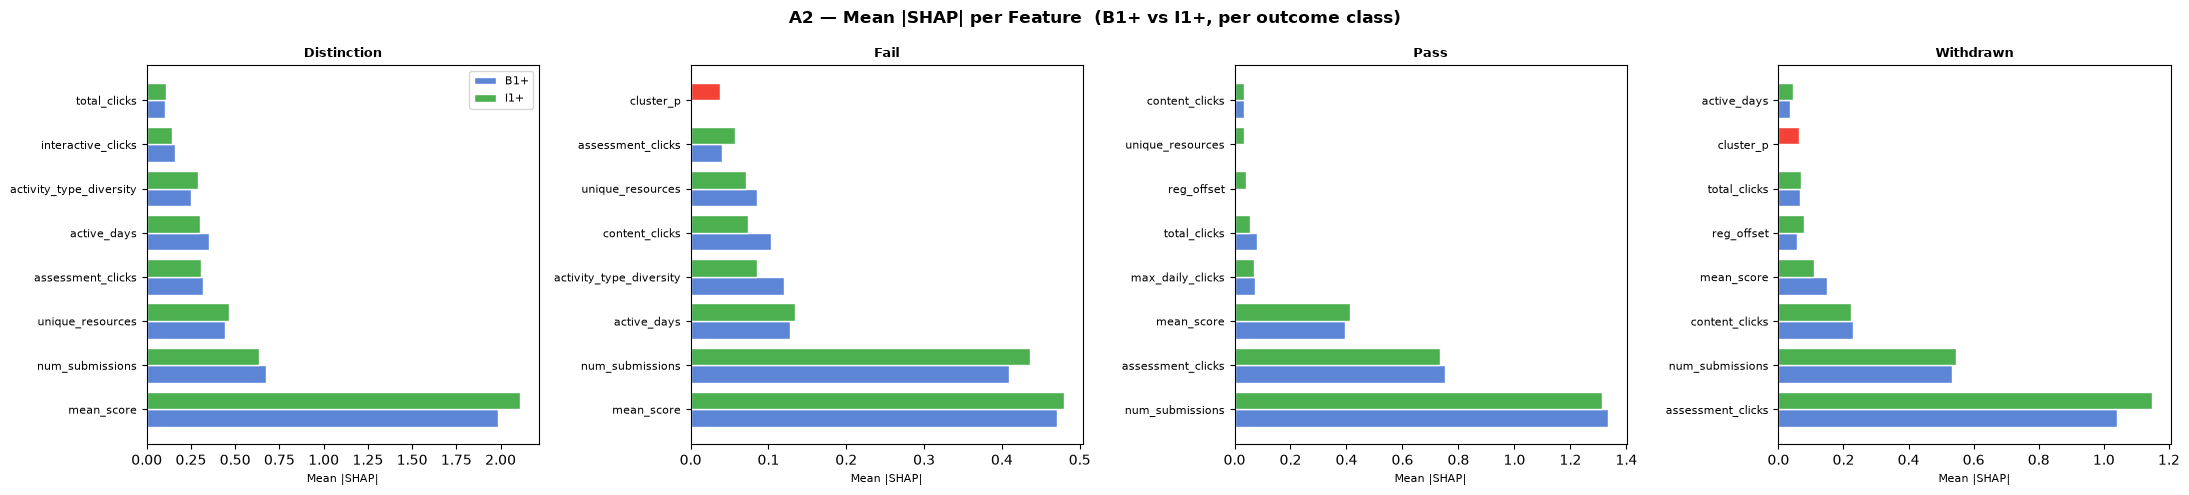


══ A2 SHAP Summary ══
  B1+ multi-class macro-F1 = 0.6911
  I1+ multi-class macro-F1 = 0.6885  (Δ = -0.0026)
  cluster_p SHAP rank #12/17  |  avg |SHAP| = 0.02520
  Directional check (positive SHAP → class elevated):
    Moderate         → SHAP for Withdrawn = -0.0186
    Disengaged       → SHAP for Withdrawn = -0.0527
    High Engaged     → SHAP for Withdrawn = +0.0746
    No VLE Record    → SHAP for Withdrawn = +0.2651


: 

In [ ]:
# ── A2.2  SHAP for Multi-class Models ────────────────────────────────────────
# shap 0.46+ TreeExplainer returns shap_values for multi:softprob XGBoost as
# a 3D numpy array of shape (n_samples, n_features, n_classes).
# Class-k slice:  shap_arr[:, :, k]  →  shape (n_samples, n_features)

import shap
import warnings; warnings.filterwarnings('ignore')

print("Computing SHAP — B1+ multi-class (16 feat) ...", end=" ", flush=True)
explainer_b1p_mc = shap.TreeExplainer(model_b1p_mc)
shap_vals_b1p_mc = explainer_b1p_mc.shap_values(X_test_b1p)
# Normalise: old shap returned list → convert to 3D array if needed
if isinstance(shap_vals_b1p_mc, list):
    shap_vals_b1p_mc = np.stack(shap_vals_b1p_mc, axis=-1)  # (n, f, K)
print(f"done  shape={shap_vals_b1p_mc.shape}")

print("Computing SHAP — I1+ multi-class (17 feat) ...", end=" ", flush=True)
explainer_i1p_mc = shap.TreeExplainer(model_i1p_mc)
shap_vals_i1p_mc = explainer_i1p_mc.shap_values(X_test_i1p)
if isinstance(shap_vals_i1p_mc, list):
    shap_vals_i1p_mc = np.stack(shap_vals_i1p_mc, axis=-1)
print(f"done  shape={shap_vals_i1p_mc.shape}")

# ── 1. Mean |SHAP| per feature per class ─────────────────────────────────────
# shap_arr shape: (n_samples, n_features, n_classes)
def _shap_mc_table(shap_arr, feat_cols):
    rows = []
    for fi, fname in enumerate(feat_cols):
        row = {'Feature': fname}
        for k, cname in enumerate(CLASS_NAMES_MC):
            row[cname] = round(float(np.abs(shap_arr[:, fi, k]).mean()), 5)
        row['Mean (avg classes)'] = round(float(np.mean(
            [np.abs(shap_arr[:, fi, k]).mean() for k in range(4)])), 5)
        rows.append(row)
    return pd.DataFrame(rows).sort_values('Mean (avg classes)', ascending=False).reset_index(drop=True)

df_shap_b1p_mc = _shap_mc_table(shap_vals_b1p_mc, feature_cols_b1p)
df_shap_i1p_mc = _shap_mc_table(shap_vals_i1p_mc, feature_cols_i1p)

print("\n── B1+ multi-class  Mean |SHAP| (top-10) ──")
display(df_shap_b1p_mc.head(10))
print("\n── I1+ multi-class  Mean |SHAP| (top-10) ──")
display(df_shap_i1p_mc.head(10))

# cluster_p rank and per-class importance
cp_row = df_shap_i1p_mc[df_shap_i1p_mc['Feature'] == 'cluster_p']
if not cp_row.empty:
    cp_rank = int(cp_row.index[0]) + 1
    cp_mean = float(cp_row['Mean (avg classes)'].values[0])
    print(f"\n  cluster_p global rank in I1+ multi-class: #{cp_rank}/{len(feature_cols_i1p)}")
    print(f"  cluster_p mean |SHAP| (avg over 4 classes): {cp_mean:.5f}")
    for cname in CLASS_NAMES_MC:
        print(f"    → {cname:<12}: mean |SHAP| = {float(cp_row[cname].values[0]):.5f}")

# ── 2. Beeswarm per class — I1+ ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('A2 — SHAP Beeswarm by Outcome Class  (I1+ 17 feat, Test 2014)',
             fontsize=12, fontweight='bold')
for k, (cname, ax) in enumerate(zip(CLASS_NAMES_MC, axes)):
    plt.sca(ax)
    # shap_vals_i1p_mc[:, :, k] → (n_samples, n_features) for class k
    shap.summary_plot(shap_vals_i1p_mc[:, :, k], X_test_i1p,
                      feature_names=feature_cols_i1p,
                      max_display=10, show=False, plot_size=None)
    ax.set_title(f'{cname}', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. cluster_p SHAP heat-map: archetype × outcome class ────────────────────
cp_idx_mc  = list(feature_cols_i1p).index('cluster_p')
cp_test_mc = X_test_i1p[:, cp_idx_mc].astype(int)

try:
    cp_names_mc = {int(k): v for k, v in cluster_names_final.items()}
except Exception:
    cp_names_mc = {0: 'Disengaged', 1: 'Moderate', 2: 'High Engaged', 3: 'No VLE'}

unique_cp = sorted(np.unique(cp_test_mc))
rows_heat = []
for cp_val in unique_cp:
    mask_cp = cp_test_mc == cp_val
    row = {'Archetype': cp_names_mc.get(cp_val, f'C{cp_val}'),
           'N (test)':  int(mask_cp.sum()),
           'WD Rate':   f"{(y_test_mc[mask_cp] == class_enc_mc['Withdrawn']).mean():.1%}"}
    for k, cname in enumerate(CLASS_NAMES_MC):
        # 3D indexing: [sample_mask, feature_idx, class_k]
        row[f'SHAP→{cname}'] = round(float(shap_vals_i1p_mc[mask_cp, cp_idx_mc, k].mean()), 4)
    rows_heat.append(row)

df_heat = pd.DataFrame(rows_heat)
print("\n── cluster_p Mean SHAP by Archetype × Outcome Class  (I1+ multi-class) ──")
display(df_heat)

# Heat-map visualisation
shap_cols  = [f'SHAP→{c}' for c in CLASS_NAMES_MC]
heat_data  = df_heat[shap_cols].values.astype(float)
vmax       = np.abs(heat_data).max()

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(heat_data, cmap='RdYlGn_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES_MC, rotation=15, fontsize=10)
ax.set_yticks(range(len(df_heat)))
ax.set_yticklabels(df_heat['Archetype'], fontsize=10)
for i in range(len(df_heat)):
    for j in range(4):
        ax.text(j, i, f'{heat_data[i, j]:+.3f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(heat_data[i, j]) > vmax * 0.55 else 'black')
plt.colorbar(im, ax=ax, label='Mean SHAP (log-odds scale)')
ax.set_title('A2 — cluster_p Mean SHAP by Archetype × Outcome Class\n'
             '(I1+ 17 feat, Test Set 2014)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Mean |SHAP| bar chart comparison (B1+ vs I1+, top 8 features avg) ─────
top_n = 8
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('A2 — Mean |SHAP| per Feature  (B1+ vs I1+, per outcome class)',
             fontsize=12, fontweight='bold')
for k, (cname, ax) in enumerate(zip(CLASS_NAMES_MC, axes)):
    # shap_vals_b1p_mc[:, :, k] → (n_samples, n_features); mean over samples
    s_b = pd.Series(np.abs(shap_vals_b1p_mc[:, :, k]).mean(axis=0), index=feature_cols_b1p)
    s_i = pd.Series(np.abs(shap_vals_i1p_mc[:, :, k]).mean(axis=0), index=feature_cols_i1p)
    top_feats = s_i.nlargest(top_n).index.tolist()
    x = np.arange(len(top_feats))
    w = 0.4
    ax.barh(x - w/2, [s_b.get(f, 0) for f in top_feats], w,
            label='B1+', color='#5C85D6', edgecolor='white')
    ax.barh(x + w/2, [s_i.get(f, 0) for f in top_feats], w,
            label='I1+', color=['#F44336' if f == 'cluster_p' else '#4CAF50' for f in top_feats],
            edgecolor='white')
    ax.set_yticks(x); ax.set_yticklabels(top_feats, fontsize=8)
    ax.set_title(f'{cname}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    if k == 0:
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\n══ A2 SHAP Summary ══")
print(f"  B1+ multi-class macro-F1 = {f1_b1p_mc:.4f}")
print(f"  I1+ multi-class macro-F1 = {f1_i1p_mc:.4f}  (Δ = {f1_i1p_mc - f1_b1p_mc:+.4f})")
if not cp_row.empty:
    print(f"  cluster_p SHAP rank #{cp_rank}/{len(feature_cols_i1p)}  |  "
          f"avg |SHAP| = {cp_mean:.5f}")
    print("  Directional check (positive SHAP → class elevated):")
    for cp_val in unique_cp:
        name = cp_names_mc.get(cp_val, f'C{cp_val}')
        wd_k = class_enc_mc['Withdrawn']
        shap_wd = float(shap_vals_i1p_mc[cp_test_mc == cp_val, cp_idx_mc, wd_k].mean())
        print(f"    {name:<16} → SHAP for Withdrawn = {shap_wd:+.4f}")